<a href="https://colab.research.google.com/github/lvdh133/-BM41050_Applied_Experimental_Methods_group1/blob/main/Bio_Inspired_Design_5060176.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bio-Inspired Design: Evolutionary Adaptive Cruise Control
----
This notebook is developed for the **Bio-Inspired Algorithms** course. It uses the Google Colab environment to utilize high-performance computing resources, which makes it possible to train faster. Due the notebook lay-out, I tried to show my iterative design process. Before every step, I explain what the code will do and why I chose this logic. The aim of this project is to construct human acceleration behavior on high ways using an evolutionary approach. The pipeline is as follows:

1. **Introduction**
2. **Environment Setup**
3. **Data Acquisition & Inspection**
4. **Data Cleaning & Sanity Filtering**
5. **Kinematic Feature Engineering**
6. **Advanced Feature Engineering & Selection**
7. **Model Baselines**
8. **NeuroEvolution of Augmenting Topologies (NEAT)**
9. **Model Visualization**
10. **Custom-made Evolutionairy Algorithm**
11. **Conclusion and Final Head-to-Head Comparison**

Running the entire notebook, takes approximatly 1 hour.




---

## 1 Introduction

For this project, I am utilizing **empirical highway data** from the **NGSIM (Next Generation Simulation) dataset**. This dataset is an open-source resource, providing comprehensive vehicle trajectory data, supporting documentation, and both raw and processed video files.

My primary goal is to develop an **evolutionary algorithm** designed to adapt to the behavior of the lead vehicle. Therefore, mostly focussing on accelerationg and deceleration. This approach replicates the functionality of an Adaptive Cruise Control (ACC) system, but is operating **without the use of external sensors**.

Human behavior is complex and depends on a interplay of factors. Driver demographics, vehicle type and individual personal traits all influence how we drive and what for decisions we make (Ali et al, 2021; Hang et al, 2022).

However, research by **Ali et al. (2021)** indicates that **vehicle speed** remains the most influential factor in determining both longitudinal and lateral acceleration behavior. Therefore, I will first start with trying to predict acceleration behavior with only vehicle speed and later add more complex factors.

The main research question of this notebook will be:

*"To what extent can an evolutionary algorithm reconstruct and simulate human acceleration behavior on highways?"*


> G. Ali, S. McLaughlin, M. Ahmadian,
Quantifying the effect of roadway, driver, vehicle, and location characteristics on the frequency of longitudinal and lateral accelerations,
Accident Analysis & Prevention, Volume 161, 2021, 106356, ISSN 0001-4575,
https://doi.org/10.1016/j.aap.2021.106356.

>  Z. Huang, J. Wu and C. Lv, "Driving Behavior Modeling Using Naturalistic Human Driving Data With Inverse Reinforcement Learning," in IEEE Transactions on Intelligent Transportation Systems, vol. 23, no. 8, pp. 10239-10251, Aug. 2022, doi: 10.1109/TITS.2021.3088935.

---



## 2 Environment Setup

In [1]:
!pip install neat-python pandas numpy requests scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 kB 2.7 MB/s eta 0:00:00


### How to enable the T4 GPU
While the NEAT library primarily utilizes the CPU for population evolution, providing a GPU can accelerate data processing and any deep learning comparisons. To enable the T4 accelerator:
1.  Navigate to the top menu and select **Runtime** > **Change runtime type**.
2.  Under **Hardware accelerator**, select **T4 GPU**.
3.  Click **Save**.

---
## 3 Data Acquisition & Inspection

To train my evolutionary algorithm, I first need real-world driving data. I will retrieve this from the [NGSIM](https://data.transportation.gov/stories/s/Next-Generation-Simulation-NGSIM-Open-Data/i5zb-xe34/) dataset via its open API. Because the complete dataset is massive, the code below handles paginated downloading and caches the raw data to a local CSV file (`synthetic_car_following_raw.csv`) to save time during future iterations.

The code below will:
* Download a specific subset of the data, focusing on well-known highway segments (for simplicity I only will use I-80).
* Output the overall shape of the dataset to verify the download size.
* Preview the first few rows to examine the raw columns (like `vehicle_id`, `frame_id`, `v_vel`, and `space_headway`).



In [2]:
'''
First download the dataset and look at column structure; this takes approx.
5 minutes to run; but only has to be done once.
'''
import os
import requests
import pandas as pd

RAW_CSV_FILE = 'synthetic_car_following_raw.csv' # Changed to raw file

def download_full_paginated(api_url_base, page_size=50000, max_pages=None):
    """Download data with proper pagination, sorted by location/vehicle/frame."""
    all_data = []
    skip = 0
    page = 0
    while True:
        url = f"{api_url_base}&$top={page_size}&$skip={skip}&$orderby=location,vehicle_id,frame_id"
        resp = requests.get(url)
        resp.raise_for_status()
        batch = resp.json().get('value', [])
        if not batch:
            break
        all_data.extend(batch)
        skip += page_size
        page += 1
        print(f"Page {page}: {len(all_data)} rows downloaded so far...")
        if max_pages is not None and page >= max_pages:
            break
    return pd.DataFrame(all_data)


def inspect_dataset(locations=('i-80',), n_per_location=50000, max_pages=20):
    """Download data, select by location, and take a fixed number of rows per location."""

    if os.path.exists(RAW_CSV_FILE):
        try:
            print(f"Attempting to load existing raw data from {RAW_CSV_FILE} to avoid re-download...")
            df = pd.read_csv(RAW_CSV_FILE)
            print(f"Successfully loaded {len(df)} rows from {RAW_CSV_FILE}. Skipping download.")
            return df
        except Exception as e:
            print(f"Error loading {RAW_CSV_FILE}: {e}. File might be corrupted. Re-downloading data.")

    print(f"File {RAW_CSV_FILE} not found. Downloading raw data from API (paginated)...")
    api_url = "https://data.transportation.gov/api/odata/v4/8ect-6jqj?$format=json"

    try:
        df_all = download_full_paginated(api_url, page_size=50000, max_pages=max_pages)

        print("\n--- RAW INSPECTION REPORT ---")
        print(f"Dataset shape (before selecting locations): {df_all.shape}")
        print("Locations found:", df_all['location'].unique())

        # 1. Select for the desired locations
        df_selected_locations = df_all[df_all['location'].isin(locations)].copy()
        print(f"\nAfter selecting data for locations {locations}: {df_selected_locations.shape}")

        # 2. Sort by time within each location, then take the first n_per_location rows per location
        df_selected_locations = df_selected_locations.sort_values(['location', 'global_time', 'vehicle_id', 'frame_id'])
        df_final = (
            df_selected_locations
            .groupby('location', group_keys=False)
            .apply(lambda g: g.head(n_per_location))
        )

        print(f"\nAfter taking the top {n_per_location} rows per selected location: {df_final.shape}")
        print(df_final.groupby('location').size())

        print("\nFirst 2 rows (preview):")
        print(df_final.head(2))

        # Save the raw data for future runs
        df_final.to_csv(RAW_CSV_FILE, index=False)
        print(f"Raw data saved to {RAW_CSV_FILE}.")

        return df_final.reset_index(drop=True)

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Run the inspection
df_raw = inspect_dataset(locations=('i-80',), n_per_location=50000, max_pages=20)

File synthetic_car_following_raw.csv not found. Downloading raw data from API (paginated)...
Page 1: 50000 rows downloaded so far...
Page 2: 100000 rows downloaded so far...
Page 3: 150000 rows downloaded so far...
Page 4: 200000 rows downloaded so far...
Page 5: 250000 rows downloaded so far...
Page 6: 300000 rows downloaded so far...
Page 7: 350000 rows downloaded so far...
Page 8: 400000 rows downloaded so far...
Page 9: 450000 rows downloaded so far...
Page 10: 500000 rows downloaded so far...
Page 11: 550000 rows downloaded so far...
Page 12: 600000 rows downloaded so far...
Page 13: 650000 rows downloaded so far...
Page 14: 700000 rows downloaded so far...
Page 15: 750000 rows downloaded so far...
Page 16: 800000 rows downloaded so far...
Page 17: 850000 rows downloaded so far...
Page 18: 900000 rows downloaded so far...
Page 19: 950000 rows downloaded so far...
Page 20: 1000000 rows downloaded so far...

--- RAW INSPECTION REPORT ---
Dataset shape (before selecting locations): (

/tmp/ipykernel_2592/1388356967.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.head(n_per_location))



After taking the top 50000 rows per selected location: (50000, 26)
location
i-80    50000
dtype: int64

First 2 rows (preview):
                     __id  vehicle_id  frame_id  total_frames    global_time  \
33238  row-q64i-wfnw.7fen          36         4          1005  1113433135300   
33239  row-qbqm~5xew~55e2          36         5          1005  1113433135400   

       local_x  local_y     global_x     global_y  v_length  ...  d_zone  \
33238   27.126   75.567  6042848.877  2133146.021      24.8  ...      NA   
33239   27.126   76.568  6042848.754  2133147.014      24.8  ...      NA   

       int_id  section_id  direction  movement preceding following  \
33238      NA          NA         NA        NA         0         0   
33239      NA          NA         NA        NA         0         0   

      space_headway time_headway location  
33238           0.0          0.0     i-80  
33239           0.0          0.0     i-80  

[2 rows x 26 columns]
Raw data saved to synthetic_car_fol

## 4 Data Cleaning & Sanity Checks

Before engineering new features, I need to clean the raw data. This step involves checking for constant time intervals and removing impossible outliers (like sensor artifacts) to ensure the evolutionary algorithm trains on valid physical behavior.



### 4.1 Checking time distribution
In my first trial runs, I notice that the time distribution was not equally divided. The reason for this is that some time steps were reused and some rows were duplicated. The cell below makes sure to sort and clean the data from duplicates. To check, I plot the average timestep, which should be `0.1s`, like the camera frequency.

--- Refined Time Step Analysis ---
Mean dt: 0.1000 seconds
Median dt: 0.1000 seconds
Standard deviation: 0.0000 seconds


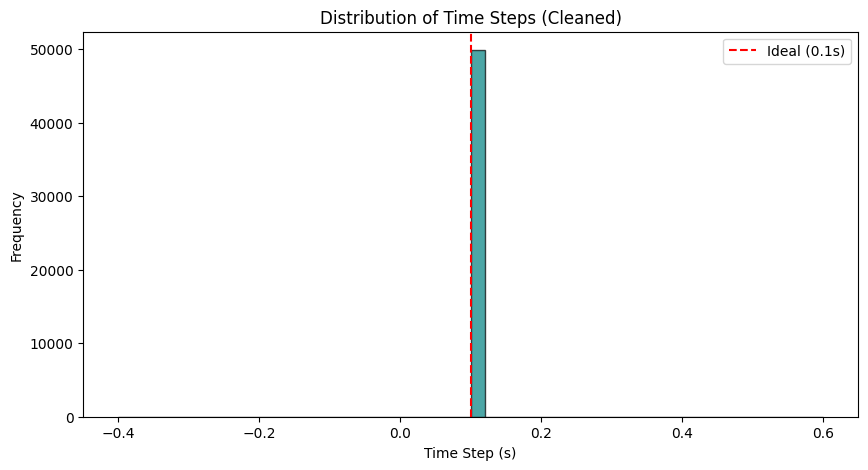

In [3]:
import matplotlib.pyplot as plt

def analyze_time_steps_robust(df):
    """
    Cleans the data and calculates time steps safely.
    """
    # 1. Clean data: Remove identical rows (duplicates)
    df_clean = df.drop_duplicates().copy()

    # 2. Force sort: Essential to calculate differences in time
    df_clean = df_clean.sort_values(['vehicle_id', 'frame_id'])

    # 3. Calculate difference in time (global_time is in ms, so divide by 1000)
    df_clean['dt_sec'] = df_clean.groupby('vehicle_id')['global_time'].diff() / 1000.0

    # 4. Filter for valid physical time steps: ignore the first frame of every car (NaN) and impossible jumps
    valid_dt = df_clean['dt_sec'].dropna()

    # filter out non-sensical values (e.g., negative jumps or massive gaps)
    plot_data = valid_dt[(valid_dt > 0) & (valid_dt < 100.0)]

    print(f"--- Refined Time Step Analysis ---")
    print(f"Mean dt: {plot_data.mean():.4f} seconds")
    print(f"Median dt: {plot_data.median():.4f} seconds")
    print(f"Standard deviation: {plot_data.std():.4f} seconds")

    # Histogram to show result
    plt.figure(figsize=(10, 5))
    plt.hist(plot_data, bins=50, color='teal', edgecolor='black', alpha=0.7)
    plt.axvline(0.1, color='red', linestyle='dashed', label='Ideal (0.1s)')
    plt.title('Distribution of Time Steps (Cleaned)')
    plt.xlabel('Time Step (s)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

analyze_time_steps_robust(df_raw)

### 4.2 Variable Distributions & Filtering

After ensuring that the timesteps are constant, it is necessary to examine the velocity, acceleration, and position data. The main goal is to determine if further filtering is required. I first plot the raw data to spot any anomalies.

This plot will constain the following variables:

- `v_vel`: The vehicle speed. It indicates the speed at which the vehicle is traveling at that specific moment.
- `v_acc`: This stands for vehicle acceleration. It indicates how the vehicle’s speed is changing (acceleration/ deceleration).
- `local_x`: This is the vehicle’s local x-coordinate. In the context of highway data, this primarily refers to which lane the car is traveling in.
- `local_y`: This is the vehicle’s local y-coordinate. This refers to the vehicle’s longitudinal position along the road, in the direction of travel.


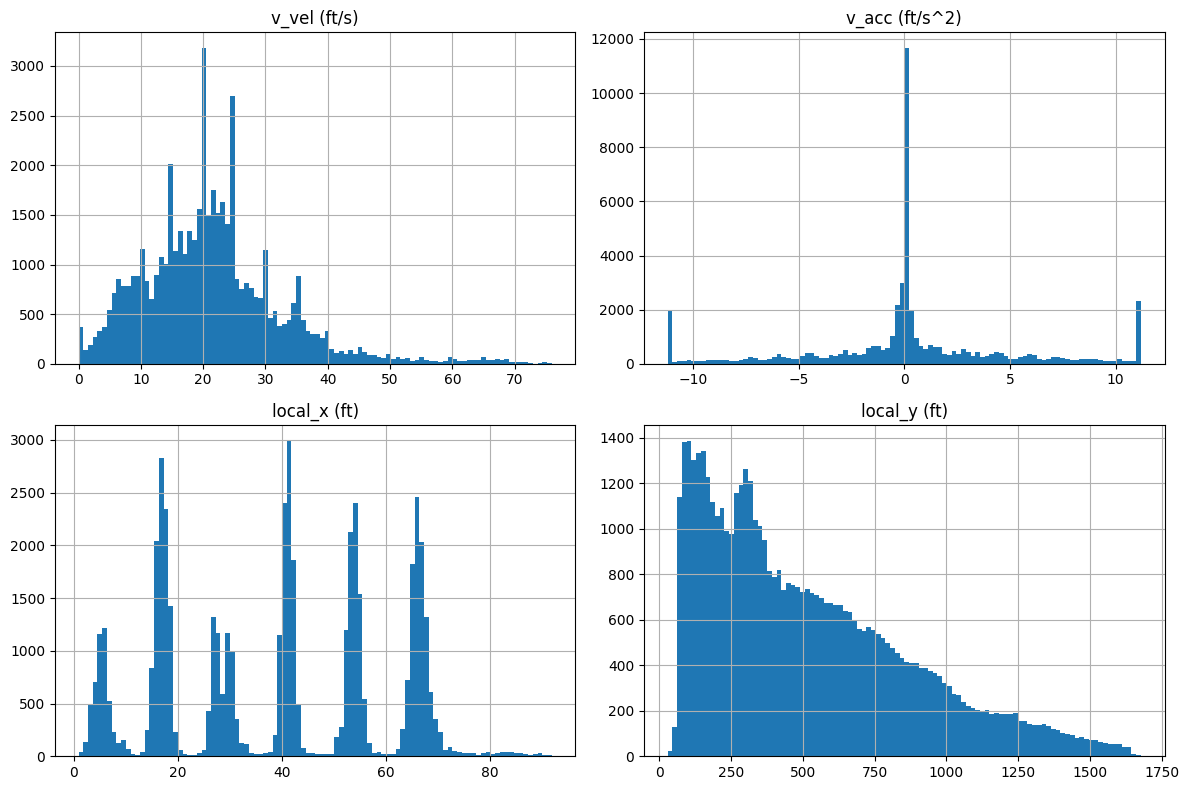

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df_raw['v_vel'].hist(bins=100, ax=axes[0,0]); axes[0,0].set_title('v_vel (ft/s)')
df_raw['v_acc'].hist(bins=100, ax=axes[0,1]); axes[0,1].set_title('v_acc (ft/s^2)')
df_raw['local_x'].hist(bins=100, ax=axes[1,0]); axes[1,0].set_title('local_x (ft)')
df_raw['local_y'].hist(bins=100, ax=axes[1,1]); axes[1,1].set_title('local_y (ft)')
plt.tight_layout()
plt.show()

The graphs show mostly normal results, expect for the spikes at the end in the *v_acc* plot around `-11` and `11 ft/s^2`. Also, the x- and y- position should be filtered to the actual mentioned measured lane accurancy (x: `max ~80ft`, y: `max ~1650`). The spikes at `v_acc` are a result from clipping or saturation artifact as a result of NGSIM's own acceleration computation. Therefore. I exclude the extreme tail entirely rather than keep the spikes.

In [5]:
# Sanity filtering based on observed distributions
df = df_raw.copy() # Initialize df with raw data
n_before = len(df)

# 1. Acceleration: filtering out the spikes arround 11.
df = df[(df['v_acc'] > -10.5) & (df['v_acc'] < 10.5)]

# 2. local_x: multimodal clusters are lane positions (NGSIM has multiple
#    lanes ~12 ft apart)
df = df[(df['local_x'] >= 0) & (df['local_x'] <= 80)]

# 3. local_y: smooth decaying distribution up to ~1600 ft, consistent with
#    a single road segment length.
df = df[(df['local_y'] >= 0) & (df['local_y'] <= 1650)]

n_after = len(df)
print(f"Sanity filtering: {n_before} -> {n_after} rows "
      f"({100*(n_before-n_after)/n_before:.2f}% removed)")

Sanity filtering: 50000 -> 45083 rows (9.83% removed)


To verify that the anomalies have been successfully removed, I plot the distributions of the cleaned dataset.

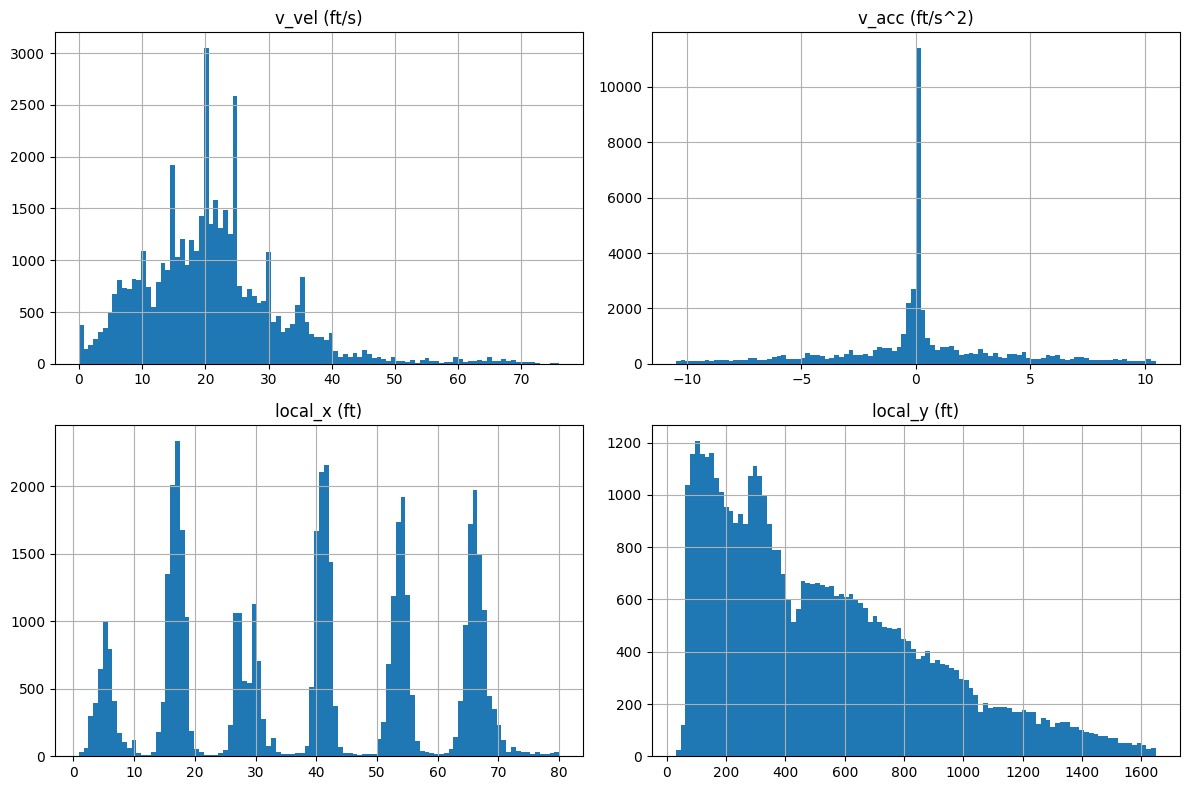

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df['v_vel'].hist(bins=100, ax=axes[0,0]); axes[0,0].set_title('v_vel (ft/s)')
df['v_acc'].hist(bins=100, ax=axes[0,1]); axes[0,1].set_title('v_acc (ft/s^2)')
df['local_x'].hist(bins=100, ax=axes[1,0]); axes[1,0].set_title('local_x (ft)')
df['local_y'].hist(bins=100, ax=axes[1,1]); axes[1,1].set_title('local_y (ft)')
plt.tight_layout()
plt.show()

Even though, the plots show normal behavior, it can not be used for training. First, some features needs to be calculated from the data.

---

## 5 Kinematic Feature Engineering

To help the model learn human-like behavior, I need to derive dynamic variables from the raw data, such as the lead vehicle's velocity (`v_lead`). Because the raw sensor data is noisy, I will implement a 2D Kalman filter to estimate these values accurately and prevent extreme spikes.

### 5.1 Deriving Relative Velocity & Preprocessing

In car-following scenarios, the ego vehicle's (`v_ego`) policy depends on how fast it is driving itselves and how fast the vehicle is driving in front; in summary it is a response to the **relative velocity** ($\Delta v = v_{lead} - v_{ego}$). For this relative velocity, I first need to derive `v_lead`. While the raw dataset provides the distance headway (`dhw`), is is not the same as `v_lead`. `v_lead` captures the *dynamics* of the lead vehicle, whereas `dhw` only captures the *state*. This feature makes sure that the model can predict future gaps and anticipate, rather than just reacting to the current state.

`v_lead` can be obtained by using the kinematic relationship of the headway:

$$\dot{dhw} = v_{lead} - v_{ego} \implies v_{lead} = v_{ego} + \dot{dhw}$$

Next to `v_lead`, my hypothesis is that for a model to learn human-like behavior, it requires **temporal context**. Therefore, I added a **Temporal Window**, which shows the model *10 seconds of interaction* (100 frames). The reason why this is implemented is the fact that 1 second (10 frames) is merely a snapshot of motion. It captures no intent. 10 seconds gives a window to observe more behavioral events, such as a car braking for traffic, merging, or reacting to a speed change. The specific value can be tuned if the temporal context proves to be valuable, it does not have to be 100 specific, but I expected within that range.

Differentiation of noisy data can lead to amplifying errors. To minimize this, I introduce some extra steps:

* **Track Identification & Data Formatting (Scalability)**: Even though this notebook currently focuses solely on the I-80 highway, the complete NGSIM dataset reuses vehicle IDs across its different locations (like US-101) and recording sessions. By combining the location and vehicle ID into a new track_key right from the start, the pipeline is future-proofed and fully scalable if I ever decide to include more data. Additionally, I force all relevant columns to numeric formats, coercing any corrupt entries to NaN to prevent unexpected crashes during mathematical operations.

* **Apply Global Deduplication (Safeguard)**: The main raw dataset has not been globally deduplicated yet. Even if the current 50,000-row sample happens to yield zero duplicates, the NGSIM API is known to return overlapping records when paginating through larger requests. Keeping this deduplication step acts as a necessary safeguard for future upscaling. It guarantees that never a  mathematically impossible situations is encountered during differentiation (such as dividing by a time step of $dt=0$).

* **Apply Sanity Filtering:** Implement Sanity & Physical Filtering: Building on the data inspection from Section 4, I formally enforce the observed bounds on the raw sensor data (`v_vel`, `v_acc`, and `local coordinates: x, y`). Additionally, I apply strict physical bounds to the derived quantities (e.g., bounding `v_lead` between `0` and `30 m/s`). This two-step approach ensures we discard both raw sensor glitches and mathematically derived anomalies (like a lead vehicle appearing to drive backwards) that would otherwise confuse a learning agent.
* **Apply Smoothing (Low-pass Filter):** The raw sensor data is noisy (it looks spiky in general). vehicles have mass and inertia, which makes their physical behavior smooth and low-frequency. Therefore I apply a **Low-Pass Filter** (moving average on `dhw`) before differentiation. This prevents the high-frequency sensor noise from being amplified by the derivative calculation. To do this, I apply a *moving average* to `dwh`, which acts as a simple low-pass filter, by averaging out jitter.

* **Transition Handling:** A major challenge is the "teleportation" effect; when the `preceding` vehicle ID changes, the gap distance (`dhw`) jumps instantly. Calculating a derivative across this boundary creates a massive, fake velocity spike. The below code tries to detect these changes (`preceding.diff() > 0`) and "zeros out" the derivative to prevent these massive fake spikes.

The complete data preprocessing and kinematic feature engineering pipeline can be seen below. The pre-processed dataset is saved as `synthetic_car_following_cleaned.csv`.
The complete data preprocessing and kinematic feature engineering pipeline can be seen here below. This means that also the filtering steps from the [cel above](https://colab.research.google.com/drive/1QnLmR_hA1pvQI55JGUm-mAirwjbft-BZ#scrollTo=3_FhtnEkrmTz&line=5&uniqifier=1) are added. The pre-processed dataset is saved as `synthetic_car_following_cleaned.csv`

In [7]:
import os
import pandas as pd
import numpy as np

# Configuration
CLEANED_CSV_FILE = 'synthetic_car_following_cleaned.csv' # Changed to cleaned file
N_CARS = 100
MIN_TRACK_LENGTH = 100  # Minimum frames a vehicle must have to be included
MAX_INTERP_GAP = 5      # frames (= 0.5s); larger gaps are a genuine discontinuity, not noise
FORCE_REBUILD = True # Set True to ignore the cache and rebuild from df_raw

# Sanity filter bounds, derived from the observed distributions
V_VEL_MIN, V_VEL_MAX = 0, 80          # ft/s, smooth real range
V_ACC_BOUND = 10.5                     # ft/s^2, excludes the saturation spikes at ~±11
LOCAL_X_MIN, LOCAL_X_MAX = 0, 80       # ft, covers the visible lane clusters
LOCAL_Y_MIN, LOCAL_Y_MAX = 0, 1650     # ft, matches the observed segment length

# Physical bounds for derived quantities
MAX_PHYSICAL_VELOCITY = 30.0 # m/s (~100 km/h)
MIN_PHYSICAL_VELOCITY = 0.0  # m/s (vehicle cannot move backwards as a lead car)

if os.path.exists(CLEANED_CSV_FILE) and not FORCE_REBUILD:
    print(f"Loading existing cleaned dataset from {CLEANED_CSV_FILE}...")
    df_model = pd.read_csv(CLEANED_CSV_FILE)
    print(f"Loaded {len(df_model)} frames from {df_model['source_vehicle_id'].nunique()} tracks.")
else:
    print("Building cleaned dataset from df_raw...")

    if 'df_raw' not in globals() or df_raw is None:
        raise RuntimeError("df_raw is not available. Run the download cell above first.")

    df = df_raw.copy()
    df.columns = df.columns.str.lower()

    # Unique track key: NGSIM reuses vehicle_id across locations/sessions,
    # so vehicle_id alone is NOT a valid trajectory identifier.
    df['track_key'] = df['location'].astype(str) + '_' + df['vehicle_id'].astype(str)

    numeric_cols = ['preceding', 'vehicle_id', 'frame_id', 'v_vel', 'v_acc',
                     'space_headway', 'local_x', 'local_y']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    n_raw = len(df)

    # Drop duplicate measurements (same track, same frame, same timestamp)
    # the API returns rows with distinct __id values even when the underlying
    # record is identical.
    df = df.drop_duplicates(subset=['track_key', 'frame_id', 'global_time'])
    n_after_dedup = len(df)
    print(f"Deduplication: {n_raw} -> {n_after_dedup} rows "
          f"({100*(n_raw-n_after_dedup)/n_raw:.2f}% removed)")

    # Sanity filtering, applied BEFORE track-length counting so that dirty
    # frames don't artificially inflate a track's apparent length.
    n_before_sanity = len(df)
    df = df[(df['v_vel'] >= V_VEL_MIN) & (df['v_vel'] <= V_VEL_MAX)]
    df = df[(df['v_acc'] > -V_ACC_BOUND) & (df['v_acc'] < V_ACC_BOUND)]
    df = df[(df['local_x'] >= LOCAL_X_MIN) & (df['local_x'] <= LOCAL_X_MAX)]
    df = df[(df['local_y'] >= LOCAL_Y_MIN) & (df['local_y'] <= LOCAL_Y_MAX)]
    df = df[df['space_headway'] > 0]

    n_after_sanity = len(df)
    print(f"Sanity filtering: {n_before_sanity} -> {n_after_sanity} rows "
          f"({100*(n_before_sanity-n_after_sanity)/n_before_sanity:.2f}% removed)")

    # Filter for valid cars that follow others and have sufficient track length,
    # counted PER TRACK KEY, not per raw vehicle_id
    track_counts = df[df['preceding'] != 0]['track_key'].value_counts()
    valid_tracks = track_counts[track_counts >= MIN_TRACK_LENGTH]
    print(f"Tracks with >= {MIN_TRACK_LENGTH} valid frames: {len(valid_tracks)}")

    FT_TO_M = 0.3048 # conversion so I can check more easily if numbers are realistic
    dt = 0.1
    all_car_dfs = []
    total_interpolated, total_segments_created = 0, 0

    top_n_tracks = valid_tracks.index[:N_CARS]

    for track_id in top_n_tracks:
        # Ensure 'preceding' is available in car_df for the check below
        car_df = df[df['track_key'] == track_id].sort_values('frame_id').copy()

        car_df['v_ego'] = car_df['v_vel'] * FT_TO_M
        car_df['a_ego'] = car_df['v_acc'] * FT_TO_M
        car_df['dhw'] = car_df['space_headway'] * FT_TO_M

        # Apply a small moving average to smooth the noise before calculating the derivative to remove noise
        car_df['dhw_smoothed'] = car_df['dhw'].rolling(window=3, center=False).mean()
        car_df['dhw_diff'] = car_df['dhw_smoothed'].diff()

        # Invalidate dhw_diff and v_lead when preceding vehicle changes or is absent
        preceding_change = car_df['preceding'].diff().abs() > 0
        no_preceding = car_df['preceding'] == 0
        car_df.loc[preceding_change | no_preceding, 'dhw_diff'] = np.nan

        # Then calculate v_lead
        car_df['v_lead'] = car_df['v_ego'] + (car_df['dhw_diff'] / dt)

        # Drop physically impossible values instead of clipping them
        car_df.loc[(car_df['v_lead'] < MIN_PHYSICAL_VELOCITY) | (car_df['v_lead'] > MAX_PHYSICAL_VELOCITY), 'v_lead'] = np.nan

        # Fill any NaN values in v_lead, which might occur at the beginning of a track due to diff() or rolling() or the division.
        car_df['v_lead'] = car_df['v_lead'].ffill()

        car_df['source_vehicle_id'] = track_id

        # Only include relevant columns and drop any remaining NaNs
        car_df_final = car_df[['frame_id', 'v_ego', 'v_lead', 'dhw', 'a_ego', 'source_vehicle_id']].dropna().copy()

        if car_df_final.empty:
            continue

        # ---------------------------------------------------------------
        # GAP HANDLING: dropping NaN rows above can leave holes in frame_id
        # (e.g. frame 562 followed by frame 566). Every downstream cell
        # (Kalman filter, a_lead derivative, etc.) assumes a fixed dt=0.1s
        # between consecutive rows, so those holes must be resolved HERE,
        # not silently carried forward.
        # ---------------------------------------------------------------

        # 1. Reindex onto a complete, evenly-spaced frame_id grid so every
        #    row that's missing becomes an explicit NaN row instead of a gap.
        full_range = pd.RangeIndex(int(car_df_final['frame_id'].min()),
                                    int(car_df_final['frame_id'].max()) + 1)
        car_df_final = car_df_final.set_index('frame_id').reindex(full_range)
        car_df_final.index.name = 'frame_id'
        car_df_final['was_interpolated'] = car_df_final['v_ego'].isna()

        # 2. Linearly interpolate SHORT gaps only (<= MAX_INTERP_GAP frames).
        #    Longer gaps are left as NaN on purpose: interpolating over more
        #    than ~0.5s would fabricate driving behavior we didn't measure.
        value_cols = ['v_ego', 'v_lead', 'dhw', 'a_ego']
        car_df_final[value_cols] = car_df_final[value_cols].interpolate(
            method='linear', limit=MAX_INTERP_GAP, limit_area='inside'
        )
        car_df_final['source_vehicle_id'] = car_df_final['source_vehicle_id'].ffill().bfill()

        car_df_final = car_df_final.reset_index().dropna(subset=value_cols)

        n_interp = int(car_df_final['was_interpolated'].sum())
        total_interpolated += n_interp

        # 3. Any gap that was too large to interpolate still leaves a jump in
        #    frame_id. Split the track into separate segments at those points,
        #    so within each segment frame_id always increases by exactly 1
        #    (i.e. dt=0.1s is guaranteed valid everywhere downstream).
        frame_diff = car_df_final['frame_id'].diff()
        segment_id = (frame_diff != 1).cumsum().fillna(0).astype(int)
        n_segments = segment_id.nunique()
        if n_segments > 1:
            car_df_final['source_vehicle_id'] = (
                car_df_final['source_vehicle_id'].astype(str) + '_seg' + segment_id.astype(str)
            )
            total_segments_created += n_segments - 1

        if n_interp > 0 or n_segments > 1:
            print(f"Track {track_id}: interpolated {n_interp} short gaps, "
                  f"split into {n_segments} segment(s) due to larger gaps")

        # Drop segments that became too short to be useful after splitting
        seg_counts = car_df_final['source_vehicle_id'].value_counts()
        keep_segments = seg_counts[seg_counts >= MIN_TRACK_LENGTH].index
        car_df_final = car_df_final[car_df_final['source_vehicle_id'].isin(keep_segments)]

        if not car_df_final.empty:
            all_car_dfs.append(car_df_final.drop(columns=['was_interpolated']))

    df_model = pd.concat(all_car_dfs, ignore_index=True)

    # Final guarantee check: within every source_vehicle_id, frame_id must
    # increase by exactly 1 on every row after the first. If this ever fails,
    # something upstream reintroduced a gap.
    gap_check = df_model.groupby('source_vehicle_id')['frame_id'].diff().dropna()
    assert (gap_check == 1).all(), "Frame gaps still present after reindexing/segmenting - check the gap-handling logic above."

    df_model.to_csv(CLEANED_CSV_FILE, index=False)
    print(f"\nDataset created with {df_model['source_vehicle_id'].nunique()} tracks/segments, "
          f"total {len(df_model)} frames.")
    print(f"Total interpolated frames (short gaps): {total_interpolated}")
    print(f"Total additional segments created (long gaps): {total_segments_created}")
    print(f"Saved to {CLEANED_CSV_FILE}.")

# Always show a quick summary
print("\nFrames per track:")
print(df_model.groupby('source_vehicle_id').size())
print(f"\nTotal tracks: {df_model['source_vehicle_id'].nunique()}, total frames: {len(df_model)}")
print("\n=== Feature sanity check ===")
print(df_model[['v_ego', 'v_lead', 'dhw']].describe())
print(f"Max absolute change of v_lead between frames: {df_model['v_lead'].diff().abs().max():.4f}")

Building cleaned dataset from df_raw...
Deduplication: 50000 -> 50000 rows (0.00% removed)
Sanity filtering: 50000 -> 40934 rows (18.13% removed)
Tracks with >= 100 valid frames: 105
Track i-80_50: interpolated 44 short gaps, split into 1 segment(s) due to larger gaps
Track i-80_11: interpolated 47 short gaps, split into 1 segment(s) due to larger gaps
Track i-80_54: interpolated 39 short gaps, split into 1 segment(s) due to larger gaps
Track i-80_51: interpolated 54 short gaps, split into 2 segment(s) due to larger gaps
Track i-80_13: interpolated 51 short gaps, split into 3 segment(s) due to larger gaps
Track i-80_74: interpolated 35 short gaps, split into 1 segment(s) due to larger gaps
Track i-80_66: interpolated 41 short gaps, split into 1 segment(s) due to larger gaps
Track i-80_24: interpolated 67 short gaps, split into 1 segment(s) due to larger gaps
Track i-80_32: interpolated 48 short gaps, split into 1 segment(s) due to larger gaps
Track i-80_41: interpolated 63 short gaps, 

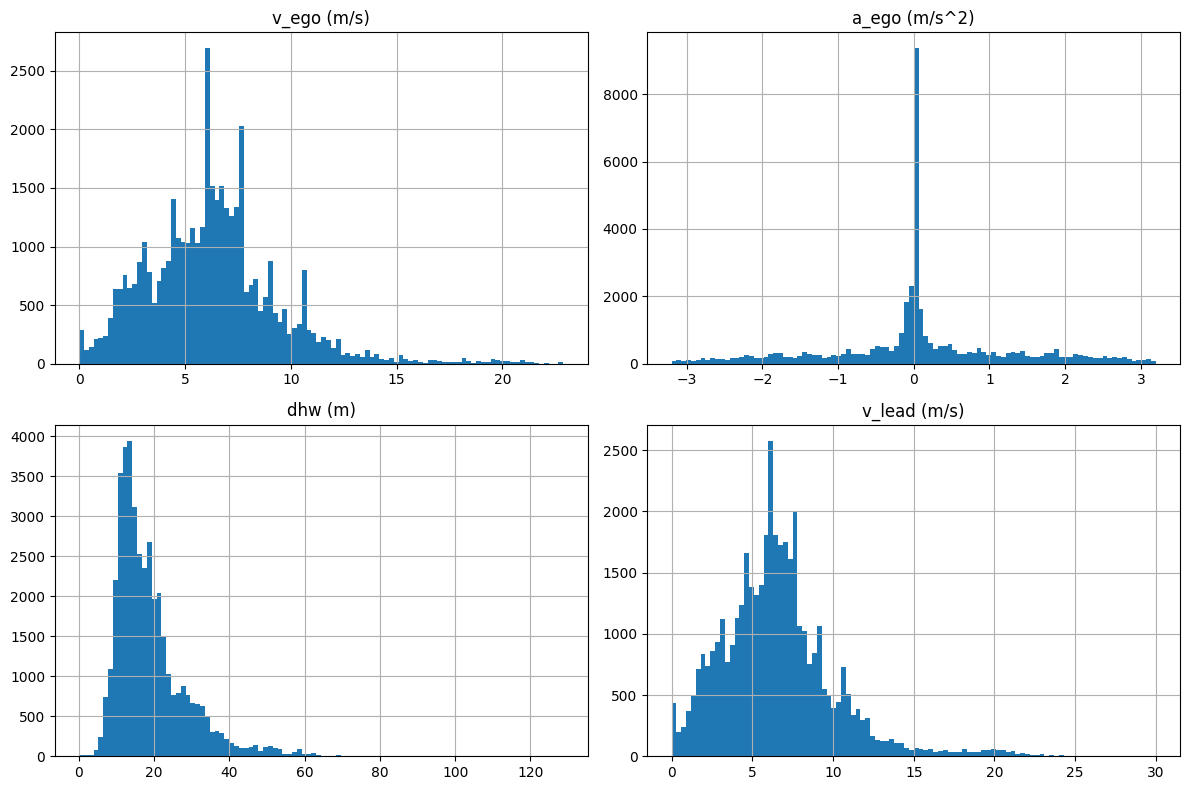

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df_model['v_ego'].hist(bins=100, ax=axes[0,0]); axes[0,0].set_title('v_ego (m/s)')
df_model['a_ego'].hist(bins=100, ax=axes[0,1]); axes[0,1].set_title('a_ego (m/s^2)')
df_model['dhw'].hist(bins=100, ax=axes[1,0]); axes[1,0].set_title('dhw (m)')
df_model['v_lead'].hist(bins=100, ax=axes[1,1]); axes[1,1].set_title('v_lead (m/s)')

plt.tight_layout()
plt.show()

### 5.2 Noise Reduction & Kalman Filtering

Although the sanity checks show decent min/max `v_lead` values, the absolute change between consecutive frames remains quite large (`~ 21 m/s`). This is likely because the current method of calculating `v_lead` (lead vehicle velocity) relies on differentiating the smoothed distance headway (`dhw_smoothed`). While initial smoothing helps, differentiation can still significantly amplify noise, leading to unrealistic `v_lead` values and large instantaneous changes.

To address this, I implement a 2D Kalman filter. A Kalman filter is an optimal estimation algorithm that uses a series of measurements observed over time to produce estimates of unknown variables (such as `v_lead` and its acceleration). It effectively combines a dynamic model of the system with noisy sensor data to produce a more accurate estimate of the system's true state.

Here, the `kalman_filter_2d` function uses a 2D state (velocity and acceleration) and assumes a constant acceleration model. Furthermore, this approach is extended to the ego vehicle's velocity (`v_ego`) and acceleration, as NGSIM trajectory data is known to contain substantial noise (Thiemann et al., 2008).

The cell below implements this and saves the smoothed dataset as `synthetic_car_following_kalman_smoothed.csv`.

The two parameters that matter most for tuning the filter are `process_noise_std` and `measurement_noise_std`.

**`process_noise_std`** quantifies how much the filter trusts its own dynamic model, meaning how much the vehicle is allowed to deviate from the constant-acceleration prediction. A higher value lets the filter adapt to sudden changes more quickly, while a lower value makes the output smoother but slower to react. The values below were chosen empirically:

*   **`v_lead` (0.5):** The behavior of a lead vehicle is externally observed and inherently less predictable than the ego vehicle. Giving the filter a higher process noise grants it more "freedom" to adapt to sudden, erratic movements rather than strictly adhering to the constant-acceleration model.
*   **`v_ego` (0.1):** `v_ego` comes from direct telemetry and behaves more predictably. Since we understand the ego vehicle's dynamics better, the filter is allowed to lean heavily on its own model and smooth out noise more aggressively.

**`measurement_noise_std`** quantifies how much noise is expected in the observations themselves. A higher value tells the filter to distrust the incoming measurements and rely relatively more on the model's predictions.

*   **`v_lead` (2.0):** Because `v_lead` is a derived (differentiated) quantity, the measurements themselves are heavily amplified by noise. Therefore, they are "downweighted" more significantly.
*   **`v_ego` (1.0):** `v_ego` measurements are assumed to be cleaner and more direct, so less downweighting is needed.

Together, these settings mean the filter is more conservative (model-trusting) for `v_ego` and more measurement-driven for `v_lead`. This reflects the reality that `v_lead` is an externally observed, noisier signal, while `v_ego` is internally measured and more reliable.


> Thiemann, Christian & Treiber, Martin & Kesting, Arne. (2008). Estimating Acceleration and Lane-Changing Dynamics from Next Generation Simulation Trajectory Data. Transportation Research Record: Journal of the Transportation Research Board. 2088. 90-101. doi: 10.3141/2088-10.

In [9]:
import numpy as np
import pandas as pd
import os

def kalman_filter_2d_full(measurements, dt=0.1, process_noise_std=0.5, measurement_noise_std=1.0):
    """
    Applies a 2D (Velocity-Acceleration) Kalman filter and returns BOTH
    the smoothed velocity and the internally estimated acceleration.
    """
    n_measurements = len(measurements)
    smoothed_v = np.zeros(n_measurements)
    smoothed_a = np.zeros(n_measurements)

    # Initial State: [Velocity = first measurement, Acceleration = 0]
    x = np.array([measurements[0], 0.0])
    P = np.eye(2) * 10.0

    # State Transition Matrix (F): Constant Acceleration Kinematics
    F = np.array([[1.0, dt],
                  [0.0, 1.0]])

    # Observation Matrix (H): We only measure velocity
    H = np.array([[1.0, 0.0]])

    # Process Noise Covariance (Q)
    q = process_noise_std**2
    Q = np.array([[(dt**4)/4, (dt**3)/2],
                  [(dt**3)/2, dt**2]]) * q

    # Measurement Noise Covariance (R)
    R = np.array([[measurement_noise_std**2]])

    for i in range(n_measurements):
        z = np.array([measurements[i]])

        # Prediction Step
        x_minus = F @ x
        P_minus = F @ P @ F.T + Q

        # Update Step
        y = z - (H @ x_minus)
        S = H @ P_minus @ H.T + R
        K = P_minus @ H.T @ np.linalg.inv(S)

        x = x_minus + K @ y
        P = (np.eye(2) - K @ H) @ P_minus

        # Store BOTH the smoothed velocity and the estimated acceleration
        smoothed_v[i] = x[0]
        smoothed_a[i] = x[1]

    return smoothed_v, smoothed_a

# =============================================================================
# KALMAN EXECUTION & CACHE MANAGEMENT
# =============================================================================
KALMAN_SMOOTHED_CSV_FILE = 'synthetic_car_following_kalman_smoothed.csv'
CLEANED_CSV_FILE = 'synthetic_car_following_cleaned.csv'
MIN_PHYSICAL_VELOCITY = 0.0
KALMAN_WARMUP_FRAMES = 10  # frames where the filter is still converging after a (re)start

FORCE_KALMAN_REBUILD = True

if os.path.exists(KALMAN_SMOOTHED_CSV_FILE) and not FORCE_KALMAN_REBUILD:
    print(f"Loading existing Kalman-smoothed data from {KALMAN_SMOOTHED_CSV_FILE}...")
    df_model = pd.read_csv(KALMAN_SMOOTHED_CSV_FILE)
else:
    print("Forcing recalculation of Kalman filter on cleaned data...")

    if 'df_model' not in globals() or df_model is None or df_model.empty:
        if os.path.exists(CLEANED_CSV_FILE):
            print(f"Loading cleaned data from {CLEANED_CSV_FILE} for Kalman filtering...")
            df_model = pd.read_csv(CLEANED_CSV_FILE)
        else:
            raise FileNotFoundError(f"Cleaned data file {CLEANED_CSV_FILE} not found.")

    # Guarantee that dt=0.1 is a valid assumption before filtering: every row
    # within a track/segment must be exactly 1 frame after the previous one.
    # If this fails, the gap-handling in the cleaning cell above needs to be re-run.
    gap_check = df_model.groupby('source_vehicle_id')['frame_id'].diff().dropna()
    assert (gap_check == 1).all(), (
        "Frame gaps detected in df_model - the fixed dt=0.1 assumption used by "
        "the Kalman filter below would be invalid. Re-run the cleaning cell (5.1)."
    )

    print("Applying 2D Kinematic Kalman filter to v_lead AND v_ego for each track...")
    kalman_smoothed_tracks = []
    total_clipped_lead, total_clipped_ego = 0, 0

    for track_id in df_model['source_vehicle_id'].unique():
        track_df = df_model[df_model['source_vehicle_id'] == track_id].copy()
        track_df = track_df.sort_values('frame_id')

        # 1. Filter v_lead (Higher process noise as it's an external target)
        v_lead_k, a_lead_k = kalman_filter_2d_full(
            track_df['v_lead'].values, dt=0.1, process_noise_std=0.5, measurement_noise_std=2.0
        )

        # 2. Filter v_ego (Lower process noise assuming cleaner internal telemetry)
        v_ego_k, a_ego_k = kalman_filter_2d_full(
            track_df['v_ego'].values, dt=0.1, process_noise_std=0.1, measurement_noise_std=1.0
        )

        # The warm-up period is applied due to the fact that
        # the filter starts with high uncertainty
        # (P=10) and an assumed acceleration of 0, so the first few estimates
        # can swing sharply while it converges. Velocity converges much faster
        # than acceleration, so only the acceleration estimates are masked.
        n = len(track_df)
        warmup = min(KALMAN_WARMUP_FRAMES, n)
        a_lead_k[:warmup] = np.nan
        a_ego_k[:warmup] = np.nan

        # Count how many raw estimates fell below the physical bound, before clipping
        total_clipped_lead += int(np.sum(v_lead_k < MIN_PHYSICAL_VELOCITY))
        total_clipped_ego += int(np.sum(v_ego_k < MIN_PHYSICAL_VELOCITY))

        # Keep the raw (unclipped) estimates too, for diagnostics/plots
        track_df['v_lead_kalman_raw'] = v_lead_k
        track_df['v_ego_kalman_raw'] = v_ego_k

        # Update DataFrame with smoothed velocities, enforcing physical boundaries
        track_df['v_lead_kalman'] = np.maximum(v_lead_k, MIN_PHYSICAL_VELOCITY)
        track_df['v_ego_kalman'] = np.maximum(v_ego_k, MIN_PHYSICAL_VELOCITY)

        # Update accelerations directly from the Kalman hidden state
        track_df['a_lead_kalman'] = a_lead_k
        track_df['a_ego_kalman'] = a_ego_k

        kalman_smoothed_tracks.append(track_df)

    df_model_kalman = pd.concat(kalman_smoothed_tracks, ignore_index=True)

    # Overwrite the original columns with the highly refined Kalman versions
    df_model_kalman['v_lead'] = df_model_kalman['v_lead_kalman']
    df_model_kalman['v_ego'] = df_model_kalman['v_ego_kalman']
    df_model_kalman['a_lead'] = df_model_kalman['a_lead_kalman']
    df_model_kalman['a_ego'] = df_model_kalman['a_ego_kalman'] # The new target variable!

    print(f"\nTotal v_lead frames clipped at lower bound (v < 0): {total_clipped_lead}")
    print(f"Total v_ego frames clipped at lower bound (v < 0): {total_clipped_ego}")

    print("\nKalman filtering complete. Displaying updated v_ego and a_ego statistics:")
    print(df_model_kalman[['v_ego', 'a_ego']].describe())

    df_model = df_model_kalman
    df_model.to_csv(KALMAN_SMOOTHED_CSV_FILE, index=False)
    print(f"\nUpdated df_model saved to '{KALMAN_SMOOTHED_CSV_FILE}'.")

Forcing recalculation of Kalman filter on cleaned data...
Applying 2D Kinematic Kalman filter to v_lead AND v_ego for each track...

Total v_lead frames clipped at lower bound (v < 0): 388
Total v_ego frames clipped at lower bound (v < 0): 460

Kalman filtering complete. Displaying updated v_ego and a_ego statistics:
              v_ego         a_ego
count  41395.000000  40215.000000
mean       6.292001      0.070351
std        3.272962      0.397196
min        0.000000     -4.002798
25%        4.095212     -0.148127
50%        6.216263      0.075360
75%        7.832065      0.294541
max       22.782107      3.408438

Updated df_model saved to 'synthetic_car_following_kalman_smoothed.csv'.


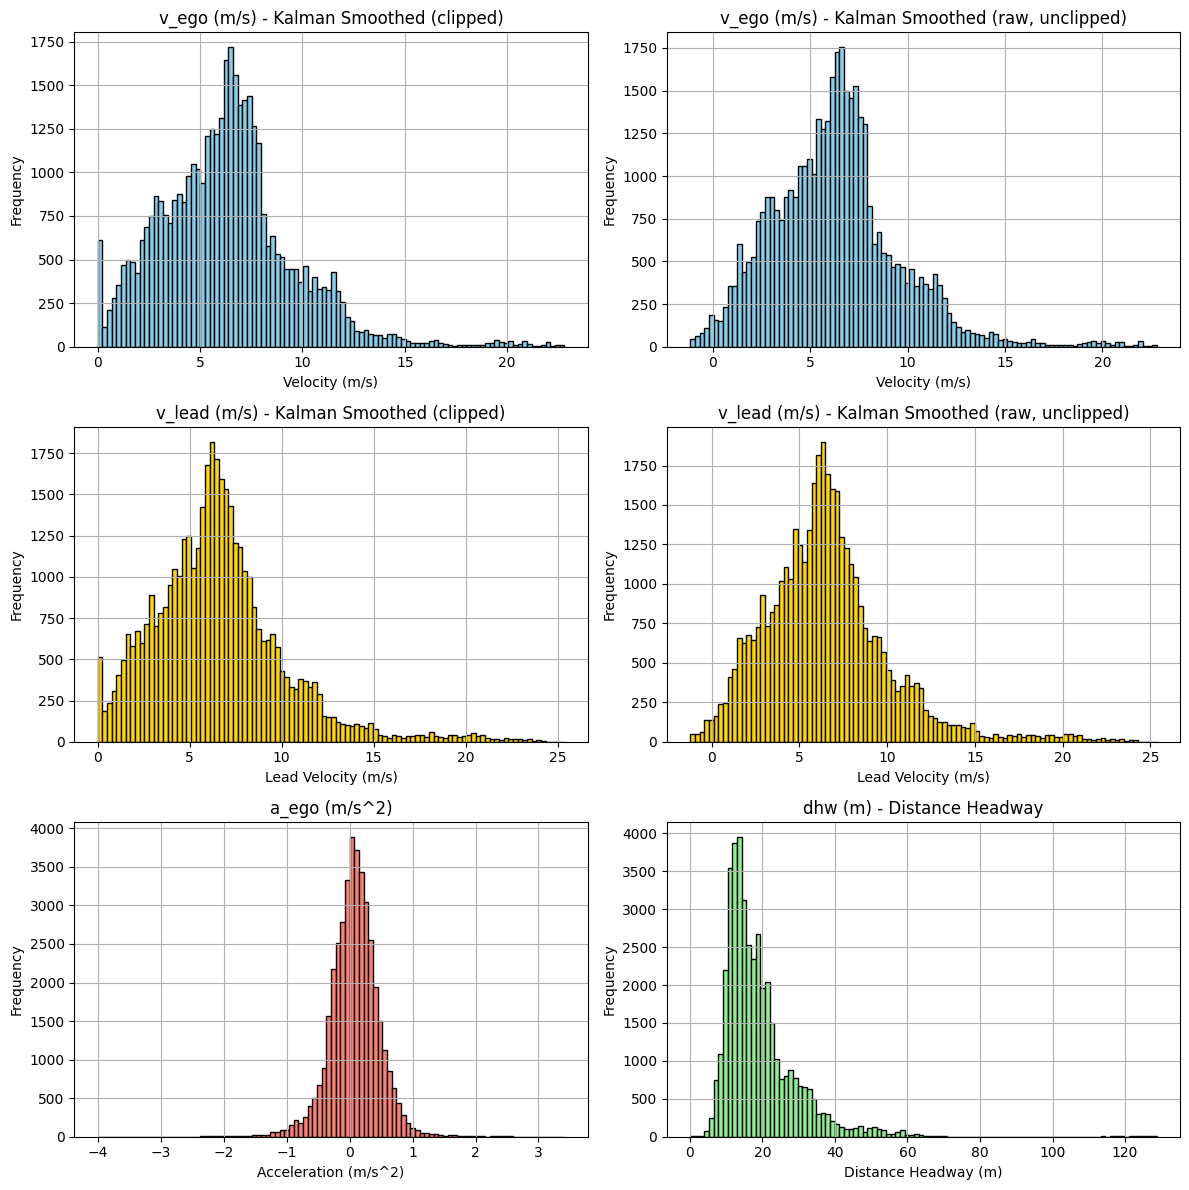

Minimum v_ego_kalman_raw value: -1.1524 m/s
Minimum v_lead_kalman_raw value: -1.2207 m/s
Maximum v_lead value being plotted: 25.36 m/s

Max absolute change of v_lead between frames: 3.3603


In [10]:
import matplotlib.pyplot as plt

'''
Plot the results of the Kalman filter, comparing the clipped (final) output
against the raw (unclipped) output for v_ego and v_lead, to visually confirm
that the spike at 0 is a clipping artifact and not a modeling issue.
'''

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Row 1: v_ego - clipped vs raw
df_model['v_ego'].hist(bins=100, ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('v_ego (m/s) - Kalman Smoothed (clipped)')
axes[0,0].set_xlabel('Velocity (m/s)')
axes[0,0].set_ylabel('Frequency')

df_model['v_ego_kalman_raw'].hist(bins=100, ax=axes[0,1], color='skyblue', edgecolor='black')
axes[0,1].set_title('v_ego (m/s) - Kalman Smoothed (raw, unclipped)')
axes[0,1].set_xlabel('Velocity (m/s)')
axes[0,1].set_ylabel('Frequency')

# Row 2: v_lead - clipped vs raw
df_model['v_lead'].hist(bins=100, ax=axes[1,0], color='gold', edgecolor='black')
axes[1,0].set_title('v_lead (m/s) - Kalman Smoothed (clipped)')
axes[1,0].set_xlabel('Lead Velocity (m/s)')
axes[1,0].set_ylabel('Frequency')

df_model['v_lead_kalman_raw'].hist(bins=100, ax=axes[1,1], color='gold', edgecolor='black')
axes[1,1].set_title('v_lead (m/s) - Kalman Smoothed (raw, unclipped)')
axes[1,1].set_xlabel('Lead Velocity (m/s)')
axes[1,1].set_ylabel('Frequency')

# Row 3: a_ego and dhw, unaffected by clipping, shown once each
df_model['a_ego'].hist(bins=100, ax=axes[2,0], color='salmon', edgecolor='black')
axes[2,0].set_title('a_ego (m/s^2)')
axes[2,0].set_xlabel('Acceleration (m/s^2)')
axes[2,0].set_ylabel('Frequency')

df_model['dhw'].hist(bins=100, ax=axes[2,1], color='lightgreen', edgecolor='black')
axes[2,1].set_title('dhw (m) - Distance Headway')
axes[2,1].set_xlabel('Distance Headway (m)')
axes[2,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Minimum v_ego_kalman_raw value: {df_model['v_ego_kalman_raw'].min():.4f} m/s")
print(f"Minimum v_lead_kalman_raw value: {df_model['v_lead_kalman_raw'].min():.4f} m/s")
print(f"Maximum v_lead value being plotted: {df_model['v_lead'].max():.2f} m/s")

max_abs_change_v_lead = df_model.groupby('source_vehicle_id')['v_lead'].diff().abs().max()
print(f"\nMax absolute change of v_lead between frames: {max_abs_change_v_lead:.4f}")

The left column (`v_ego`, `v_lead`) shows the final, clipped values used in `df_model`, while the right column shows the raw, unclipped Kalman output for the same variables. Comparing the two confirms that the spike at exactly 0 in the clipped histograms is a clipping artifact, not a modeling or data-quality issue.

The raw output tapers off smoothly near 0, including a small tail of slightly negative values (see the `Minimum ... value` prints above). These negative estimates arise from ordinary measurement noise when the true velocity is close to 0 (e.g. a vehicle stopped in traffic): the filter's estimate fluctuates around the true value and occasionally dips just below it. This is expected Kalman filter behavior, not an error.

However, I do clip these negative values to 0 in the final `v_ego`/`v_lead` columns, since negative velocity is not physically meaningful for downstream use (e.g. model training, simulation). This clipping necessarily produces a pileup of values at exactly 0, because every value that was already at or below 0 in the raw output gets mapped to the same single value. I accept this spike rather than removing those rows entirely, because dropping rows would break the fixed 0.1s frame spacing of the time series and corrupt frame-to-frame calculations (e.g. `.diff()`) as well as discard otherwise valid values in other columns for that same frame.

One consequence worth noting: since `v_lead` and `v_ego` are used directly as physically-bounded input features, they keep the clipped (0-floored) values. However, derived quantities like `a_lead` are computed from the raw, unclipped Kalman estimates instead. A derivative is not itself a physically bounded quantity, so there is no need to floor it at 0, and computing it from the clipped signal would introduce a small artificial bias: any two consecutive frames that both got clipped to exactly 0.0 would yield `a_lead = 0.0`, even if the true underlying signal had a small nonzero slope. Using the raw signal for derivatives avoids propagating the clipping artifact into downstream features.

In short: the spike at 0 in `v_ego`/`v_lead` is a known, explained side effect of enforcing a physical lower bound on a noisy estimate. It is left in place for the bounded velocity features themselves, but derived features such as `a_lead` are computed from the unclipped signal to avoid inheriting this artifact.

## 6 Advanced Feature Engineering & Selection

With the raw data cleaned and smoothed, I can now engineer more complex, proactive features. This section introduces temporal context (lags), human perception-reaction delays, and behavioral metrics (SVO), followed by a feature importance analysis to isolate the most critical variables for the evolutionary algorithm.

### 6.1 The Complexity of Human Factors & Kinematic Selection
To make the model as "bio-inspired" as possible while working within the constraints of trajectory data, I first define features based on how humans (and classical car-following models) physically approach a car-following task:

*   **`v_ego`, `v_lead`, `dhw`:** The three basic quantities a driver directly perceives: own speed, speed of the car ahead, and the distance between them.
*   **`a_lead`:** The acceleration of the leading car. Drivers do not only react to the current distance, but anticipate what the car in front of them will do.
*   **`v_ego_lag`, `v_lead_lag`, `dhw_lag`:** The values from one time step back. This history gives the (otherwise stateless, feedforward) network a form of short-term memory.
*   **`rel_velocity`:** The difference `v_ego - v_lead`. This directly determines whether the distance is increasing or decreasing.
*   **`inv_ttc` (inverse time-to-collision):** A commonly used proxy in literature (Morton et. al, 2016) for "how urgent is the situation." 1/TTC is bounded and goes to 0 instead of infinity, making it numerically stable for a neural network. Typically, humans do not have this exact information, but we tend to estimate this. I am wondering if giving this exact piece of information, will give the model a clear advantage.

The code below calculates these proactive features based on the Kalman-smoothed data and plots their distributions.

> J. Morton, T. A. Wheeler and M. J. Kochenderfer, "Analysis of Recurrent Neural Networks for Probabilistic Modeling of Driver Behavior," in IEEE Transactions on Intelligent Transportation Systems, vol. 18, no. 5, pp. 1289-1298, May 2017, doi: 10.1109/TITS.2016.2603007.

> Stanley, K. O., & Miikkulainen, R. (2002). Efficient evolution of neural network topologies. In Proceedings of the 2002 Congress on Evolutionary Computation (CEC '02) (Vol. 2, pp. 1750-1755). IEEE.




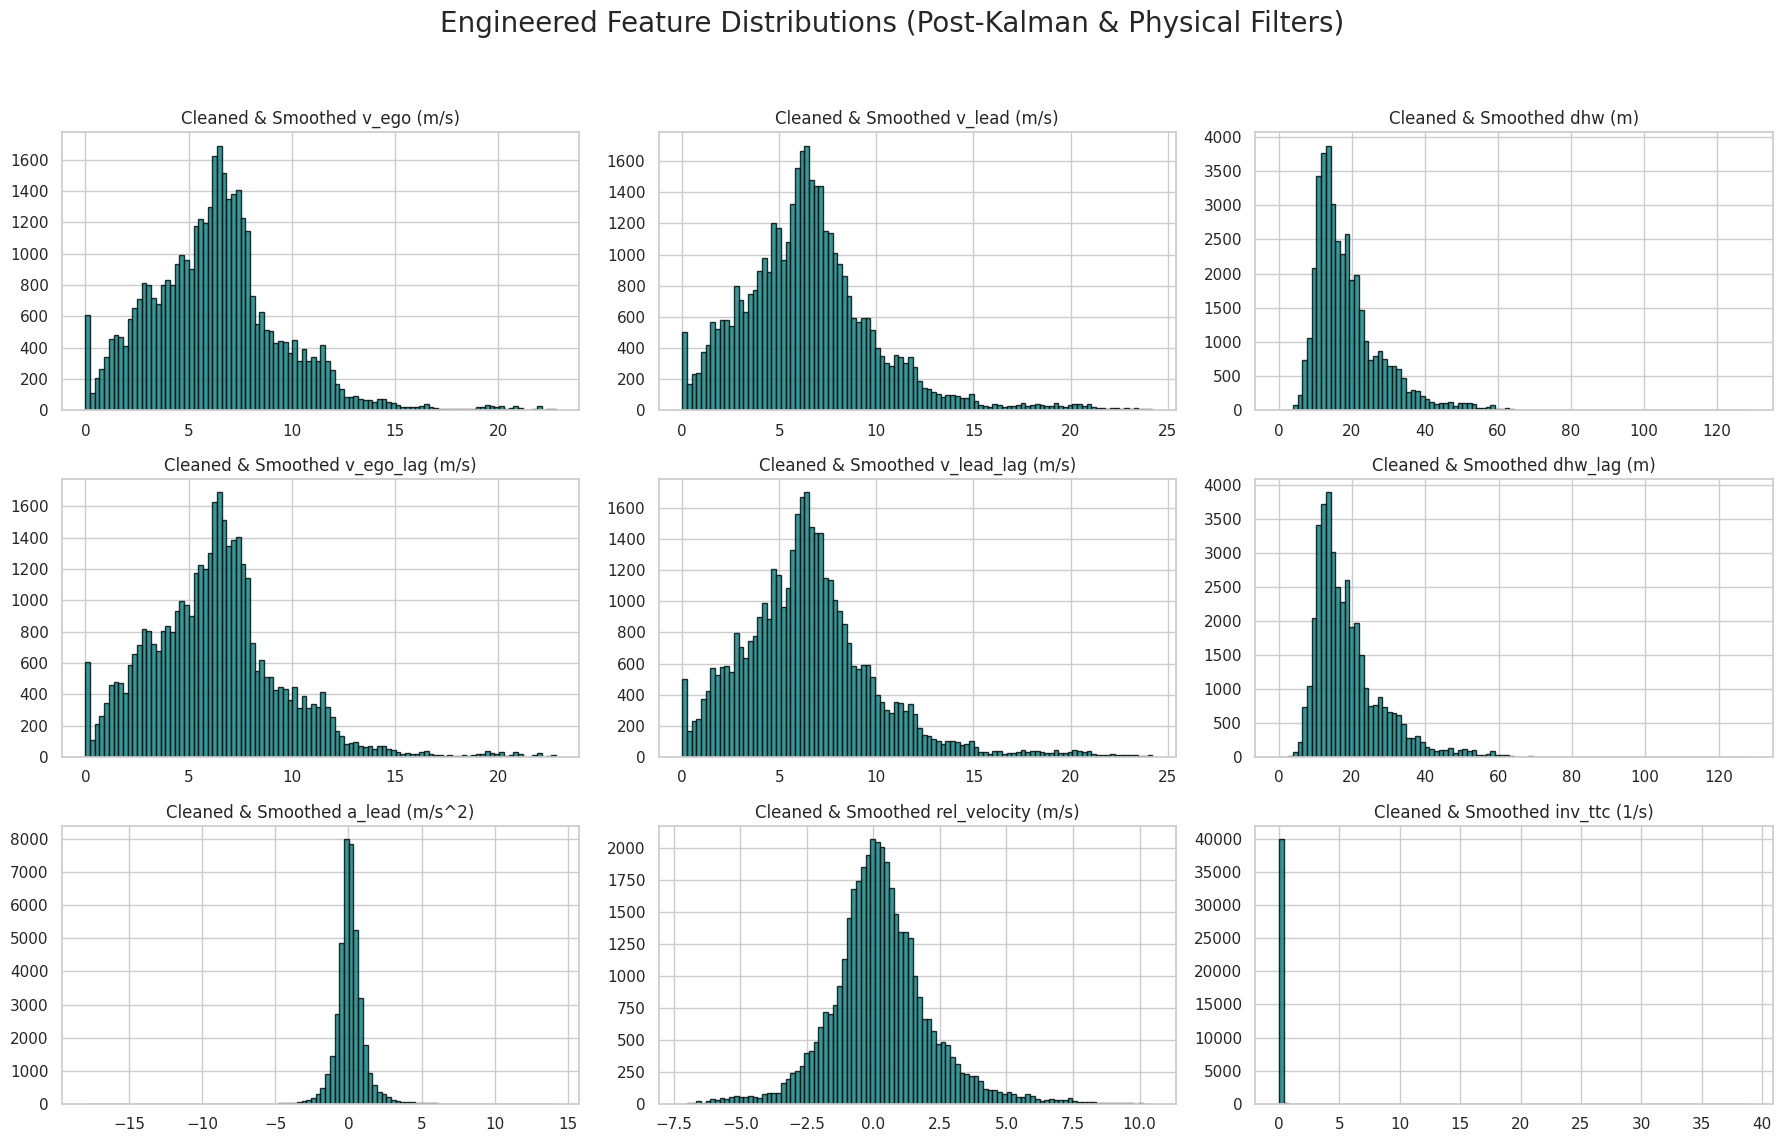

Final dataset ready for the EA algorithm with 40215 clean frames.
count    40215.000000
mean         0.092148
std          1.031375
min        -17.979058
25%         -0.371541
50%          0.050341
75%          0.507996
max         14.160547
Name: a_lead, dtype: float64
      source_vehicle_id  frame_id  v_lead_kalman_raw     a_lead
9498            i-80_60       713           5.367804  14.160547
9499            i-80_60       714           6.767689  13.998850
3579       i-80_13_seg3       444           7.161518  12.646999
38523          i-80_149       895           8.173350  11.889216
36077          i-80_168       649          11.159446  11.766030
      source_vehicle_id  frame_id  v_lead_kalman_raw     a_lead
34373      i-80_70_seg2       600           9.641208 -17.979058
34374      i-80_70_seg2       601           7.887515 -17.536931
34375      i-80_70_seg2       602           6.192891 -16.946248
34376      i-80_70_seg2       603           4.799835 -13.930556
35695     i-80_174_seg2  

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

KALMAN_SMOOTHED_CSV_FILE = 'synthetic_car_following_kalman_smoothed.csv'

# Check if df_model is defined, if not, load it
if 'df_model' not in globals() or df_model is None or df_model.empty:
    if os.path.exists(KALMAN_SMOOTHED_CSV_FILE):
        print(f"Loading df_model from {KALMAN_SMOOTHED_CSV_FILE}...")
        df_model = pd.read_csv(KALMAN_SMOOTHED_CSV_FILE)
    else:
        # Fallback if file doesn't exist either, though it should have been created by d14722f7
        raise FileNotFoundError(f"df_model is not defined and {KALMAN_SMOOTHED_CSV_FILE} not found. Please ensure previous cells (5.2) are executed.")

# Guarantee dt=0.1 is valid before computing any derivative below.
gap_check = df_model.groupby('source_vehicle_id')['frame_id'].diff().dropna()
assert (gap_check == 1).all(), (
    "Frame gaps detected in df_model - the fixed dt=0.1 used for a_lead below "
    "would be invalid. Re-run the cleaning cell (5.1) and the Kalman cell (5.2)."
)

# =============================================================================
# 1. RECALCULATE DEPENDENT FEATURES
# Since v_lead was smoothed, its derivatives and lags must be updated.
# =============================================================================
dt = 0.1

# Ensure data is sorted properly before shifting
df_model = df_model.sort_values(by=['source_vehicle_id', 'frame_id'])

# Recalculate Lags
df_model['v_ego_lag'] = df_model.groupby('source_vehicle_id')['v_ego'].shift(1)
df_model['v_lead_lag'] = df_model.groupby('source_vehicle_id')['v_lead'].shift(1)
df_model['dhw_lag'] = df_model.groupby('source_vehicle_id')['dhw'].shift(1)

# Recalculate rel_velocity using the clipped v_lead/v_ego, since this is a
# physically bounded quantity used directly as a model input feature.
df_model['rel_velocity'] = df_model['v_lead'] - df_model['v_ego']

# Recalculate a_lead from the RAW (unclipped) Kalman v_lead estimate rather than
# the clipped v_lead. a_lead is a derivative, not a bounded physical quantity,
# so it can legitimately be slightly negative near v=0 without being unphysical.
# Using the clipped v_lead here would introduce a small bias: any two consecutive
# frames that both got clipped to exactly 0.0 would produce a_lead = 0.0, even if
# the true (smoothed) underlying signal had a small nonzero slope.
if 'v_lead_kalman_raw' in df_model.columns:
    df_model['v_lead_raw_lag'] = df_model.groupby('source_vehicle_id')['v_lead_kalman_raw'].shift(1)
    df_model['a_lead'] = (df_model['v_lead_kalman_raw'] - df_model['v_lead_raw_lag']) / dt
else:
    # Fallback for older cached CSVs that don't have the raw column yet
    print("Warning: 'v_lead_kalman_raw' not found, falling back to clipped v_lead for a_lead.")
    df_model['a_lead'] = (df_model['v_lead'] - df_model['v_lead_lag']) / dt

# Recalculate Inverse TTC (Time-To-Collision)
# Only calculate when rel_velocity < 0, otherwise 0.
# Handle division by zero for dhw to avoid np.inf.
df_model['inv_ttc'] = np.where(
    df_model['dhw'] != 0, # Condition 1: dhw is not zero
    np.where(
        df_model['rel_velocity'] < 0, # Condition 2: rel_velocity is negative
        -df_model['rel_velocity'] / df_model['dhw'],
        0.0
    ),
    np.nan # If dhw is zero, set inv_ttc to NaN
)

# Replace any remaining inf values with NaN to ensure compatibility with plotting functions
# This is a safeguard, but the inv_ttc calculation should now prevent most infs.
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop the NaNs created by the shift(1) operation AND by the inf replacement
df_final = df_model.dropna().copy()

# =============================================================================
# 2. PLOT THE DISTRIBUTIONS (LOG SCALE)
# =============================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

features_to_plot = {
    'v_ego': 'v_ego (m/s)',
    'v_lead': 'v_lead (m/s)',
    'dhw': 'dhw (m)',
    'v_ego_lag': 'v_ego_lag (m/s)',
    'v_lead_lag': 'v_lead_lag (m/s)',
    'dhw_lag': 'dhw_lag (m)',
    'a_lead': 'a_lead (m/s^2)',
    'rel_velocity': 'rel_velocity (m/s)',
    'inv_ttc': 'inv_ttc (1/s)'
}

for i, col in enumerate(features_to_plot.keys()):
    df_final[col].hist(bins=100, ax=axes[i], color='teal', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Cleaned & Smoothed {features_to_plot[col]}', fontsize=12)

plt.suptitle('Engineered Feature Distributions (Post-Kalman & Physical Filters)', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Final dataset ready for the EA algorithm with {len(df_final)} clean frames.")
print(df_final['a_lead'].describe())
print(df_final.nlargest(5, 'a_lead')[['source_vehicle_id', 'frame_id', 'v_lead_kalman_raw', 'a_lead']])
print(df_final.nsmallest(5, 'a_lead')[['source_vehicle_id', 'frame_id', 'v_lead_kalman_raw', 'a_lead']])

### 6.2 The Complexity of Human Factors: Simulating Reaction Delay

To truly capture human driving, more non-dynamic factors most be added. Research demonstrates that driver demographics, such as age and gender, significantly affect crash risks and the frequency of harsh accelerations and decelerations (Ali et all., 2021). Furthermore, driving styles dictate how individuals handle vehicle control and lane deviations (Faqani et al., 2025).

Another factor is cognitive and sensory loads. Distractions like hands-free phone conversations, texting, or listening to musici significantly increase a driver's Acceleration Reaction Time (ART) (Chouhan et al., 2025; Faqani et al., 2025).


Moreover, humands are not as fast as machines. They simply do not respond immediately to changes in their environment. In traffic, drivers experience a Perception-Reaction Time (PRT), which includes perceiving a hazard, deciding on an action, and physically moving the foot to the pedals. The American Association of State Highway and Transportation Officials (AASHTO) considers `2.5` seconds as an adequate brake-reaction time for complex conditions, as it covers the 90th percentile of drivers (Mofolasayo, 2024).

Therefore, I argue to truly understand human behaviour, the input features should therefore be delayed by a realistic margin, to make sure the model "sees" what real humans experience. This typically ranges from `0.5` to `2.5` seconds. I will implement this and add a delayed feature set and later test if incorporating this explicit human delay actually improves the model's performance and generalization.

The other factors are simply not available for us in the dataset. However, factors like age or gender are normally also not visible for a "normal" driver. For now, I therefore will not investigate these factors. Cognitive load/sensory load can be implemented as a higher/lower reaction time. For now, I will stick to `1.5 s`, but this can be changed in futher research. It could be for example modeled as a functions, that increase and decreases depending on the how much traffic there is on the highway and weather/light conditions.

> Ali, G., McLaughlin, S., & Ahmadian, M. (2021). Quantifying the effect of roadway, driver, vehicle, and location characteristics on the frequency of longitudinal and lateral accelerations. Accident Analysis & Prevention, 161, 106356.

> Chouhan, R., Chavan, Y. B., Dhamaniya, A., & Antoniou, C. (2025). Impact of sensory distractions on reaction time: a comprehensive modeling approach. Accident Analysis & Prevention, 220, 108154.

> Faqani, M., Nassiri, H., Rezaei, M., & Ramezani, M. (2025). Analysis of the distraction impact on driving performance across driving styles: A driving simulator study in various speed conditions. PLoS One, 20(12), e0336480.

> Mofolasayo, A. (2024). Towards ‘Vision-Zero’ in Road Traffic Fatalities: The Need for Reasonable Degrees of Automation to Complement Human Efforts in Driving Operation. Systems, 12(2), 40. https://doi.org/10.3390/systems12020040




In [12]:
import pandas as pd
import numpy as np

# Initialize FEATURE_SETS if it doesn't exist yet
if 'FEATURE_SETS' not in globals():
    FEATURE_SETS = {}

# Dataset sampling frequency
FPS_HZ = 10

# AASHTO PRT ranges from 0.5 to 2.5 seconds.
# I select 1.5 seconds as a realistic baseline for complex highway driving,
# accommodating for standard cognitive load and minor distractions (Mofolasayo, 2024; Chouhan et al., 2025).
DELAY_SECONDS = 1.5
DELAY_FRAMES = int(DELAY_SECONDS * FPS_HZ)

def add_reaction_delay(df, delay_frames):
    """
    Shifts perception features back in time to simulate human Perception-Reaction Time (PRT).
    Based on AASHTO guidelines, PRT typically ranges from 0.5s to 2.5s.
    """
    delayed_groups = []

    for track_id, group in df.groupby('source_vehicle_id'):
        group = group.copy().sort_values('frame_id')

        # Shift all the variables the human driver perceives back in time
        group['v_lead_delayed'] = group['v_lead'].shift(delay_frames)
        group['dhw_delayed'] = group['dhw'].shift(delay_frames)

        # Shift the existing relative velocity; do not mix current and past speeds
        group['rel_vel_delayed'] = group['rel_velocity'].shift(delay_frames)

        delayed_groups.append(group)

    return pd.concat(delayed_groups).dropna().reset_index(drop=True)

# Apply the empirically backed delay to the Kalman-smoothed data
df_model_delayed = add_reaction_delay(df_final, delay_frames=DELAY_FRAMES)

# Add the new set to FEATURE_SETS
FEATURE_SETS["human_delayed"] = ["v_ego", "v_lead_delayed", "dhw_delayed", "rel_vel_delayed"]

print(f"Applied Human PRT Delay: {DELAY_SECONDS} seconds ({DELAY_FRAMES} frames)")
print(f"New feature set 'human_delayed' added. Total rows: {len(df_model_delayed)}")
display(df_model_delayed[['v_ego', 'v_lead_delayed', 'dhw_delayed', 'rel_vel_delayed']].head())

Applied Human PRT Delay: 1.5 seconds (15 frames)
New feature set 'human_delayed' added. Total rows: 38445


,v_ego,v_lead_delayed,dhw_delayed,rel_vel_delayed
0,2.415540,2.360941,13.676376,-0.558271
1,2.442508,2.412497,13.673328,-0.369567
2,2.492944,2.455934,13.658088,-0.226697
3,2.563335,2.486314,13.645896,-0.122904
4,2.643069,2.520683,13.655040,-0.033581


### 6.3 Quantifying Behavior: Social Value Orientation (SVO)

As already discussed, while raw kinematic data provides the physical boundaries of a car-following task, human driving is heavily influenced by latent behavioral states (Huang et. al., 2022). But in anonymized, trajectory-based datasets like NGSIM, critical demographic data (age, gender) and psychological states are unavailable. The network, just like a normal driver must implicitly infer a driver's behavioral tendencies purely from observable kinematic history or its current state. There are some different methods that can quantify this 'behavior' state.

For instance, Faqani et al. (2025) propose a Degree of Conservativeness (DC) based on clustering physical limits, while Schwarting et al. (2019) propose Social Value Orientation (SVO), which is a game-theoretic metric from social psychology that quantifies the degree of a driver's selfishness versus altruism as a single continuous angle ($\phi$). Both have there own pros and cons, but for this NEAT-based architecture, SVO is prefered as the optimal behavioral feature. The reasosn for this are:
1. **Proven Efficacy on the NGSIM Dataset:** The SVO framework was explicitly validated on the exact same trajectory dataset used in this study (altough on the NGSIM US-101 highway data), with Schwarting et al. (2019) demonstrating that incorporating SVO reduced trajectory prediction errors by up to 25%.
2. **Modeling Proactive Interaction:** Car-following and lane-changing resemble social dilemmas (Schwarting et al., 2019). SVO explicitly models how a driver weighs rewards, providing the network with an abstracted sense of human intent to fulfill the requirement of "proactive" information in Evolutionary Robotics (De Croon & van Kampen, 2026).
3. **Aligning with NEAT's Dimensionality Principles:** Evolutionary Robotics theory emphasizes that small ANNs cannot easily process high-dimensional raw inputs, necessitating heavy pre-processing (De Croon & van Kampen, 2026). SVO compresses multi-agent interactions into a single scalar value. This reduces the search space for NEAT significantly (Stanley & Miikkulainen, 2002).

The code here below calculates this SVO angle on the "normal" and "delayed" dataset based on the method used by Stanley & Miikkulainen (2002).

> De Croon, G., & van Kampen, E.-J. (2026). AE4350: Bio-inspired Intelligence and Learning for Aerospace Applications [Lecture slides]. Delft University of Technology.

> Huang, Z., Wu, J., & Lv, C. (2022). Driving behavior modeling using naturalistic human driving data with inverse reinforcement learning. IEEE Transactions on Intelligent Transportation Systems, 23(8), 10239-10251.

> Schwarting, W., Pierson, A., Alonso-Mora, J., Karaman, S., & Rus, D. (2019). Social behavior for autonomous vehicles. Proceedings of the National Academy of Sciences, 116(50), 24972-24978.

> Stanley, K. O., & Miikkulainen, R. (2002). Efficient evolution of neural network topologies. In Proceedings of the 2002 Congress on Evolutionary Computation (CEC '02) (Vol. 2, pp. 1750-1755). IEEE.

In [13]:
import numpy as np
import pandas as pd

# Initialize FEATURE_SETS if it doesn't exist yet
if 'FEATURE_SETS' not in globals():
    FEATURE_SETS = {}

# Window size for estimating the latent behavioral state (e.g., 5 seconds at 10Hz)
# set by trial and error
SVO_WINDOW_FRAMES = 50

def estimate_svo_proxy(df, window=50):
    """
    Estimates a kinematic proxy for the Social Value Orientation (SVO) angle.
    Based on Schwarting et al. (2019):
    - Egoistic (Selfish, phi -> 0): Maximizes own speed, minimizes headway.
    - Prosocial (Altruistic, phi -> pi/4): Maintains large safe headway, moderates speed.
    """
    print("Calculating latent Social Value Orientation (SVO) angles...")

    # Calculate dataset-wide 95th percentiles for robust normalization
    # We use the 95th percentile to prevent extreme outliers from skewing the scale
    max_v = df['v_ego'].quantile(0.95)
    max_dhw = df['dhw'].quantile(0.95)

    svo_dfs = []

    for track_id, group in df.groupby('source_vehicle_id'):
        group = group.copy().sort_values('frame_id')

        # 1. Extract the latent state using a rolling window
        rolling_v = group['v_ego'].rolling(window=window, min_periods=1).mean()
        rolling_dhw = group['dhw'].rolling(window=window, min_periods=1).mean()

        # 2. Normalize features to roughly a [0, 1] range
        # clip the lower bound to 0.01 to strictly avoid division by zero
        norm_v = np.clip(rolling_v / max_v, 0.01, 1.0)
        norm_dhw = np.clip(rolling_dhw / max_dhw, 0.01, 1.0)

        # 3. Calculate the SVO Angle (phi)
        # phi = arctan( Reward_others / Reward_self )
        group['svo_angle'] = np.arctan(norm_dhw / norm_v)

        svo_dfs.append(group)

    return pd.concat(svo_dfs).sort_index()

# =============================================================================
# 1. Apply to Delayed Data
# =============================================================================
df_model_delayed = estimate_svo_proxy(df_model_delayed, window=SVO_WINDOW_FRAMES)

FEATURE_SETS["human_delayed_svo"] = [
    "v_ego",
    "v_lead_delayed",
    "dhw_delayed",
    "rel_vel_delayed",
    "svo_angle"
]
print(f"New feature set 'human_delayed_svo' added. Total rows: {len(df_model_delayed)}")


# =============================================================================
# 2. Apply to Non-Delayed (Standard) Data
# =============================================================================
df_final = estimate_svo_proxy(df_final, window=SVO_WINDOW_FRAMES)

FEATURE_SETS["standard_svo"] = [
    "v_ego",
    "v_lead",
    "dhw",
    "rel_velocity",
    "svo_angle"
]
print(f"New feature set 'standard_svo' added. Total rows: {len(df_final)}")


# =============================================================================
# Display Samples
# =============================================================================
display_cols = ['v_ego', 'dhw', 'svo_angle']
print("\nSample SVO calculations (Standard Non-Delayed):")
display(df_final[display_cols].sample(5, random_state=42))

Calculating latent Social Value Orientation (SVO) angles...
New feature set 'human_delayed_svo' added. Total rows: 38445
Calculating latent Social Value Orientation (SVO) angles...
New feature set 'standard_svo' added. Total rows: 40215

Sample SVO calculations (Standard Non-Delayed):


,v_ego,dhw,svo_angle
3521,3.047227,12.240768,0.923914
19250,4.610556,10.837164,0.604891
23782,1.227054,11.618976,1.308001
8491,1.548338,12.996672,0.864207
2905,5.726033,22.210776,0.919465


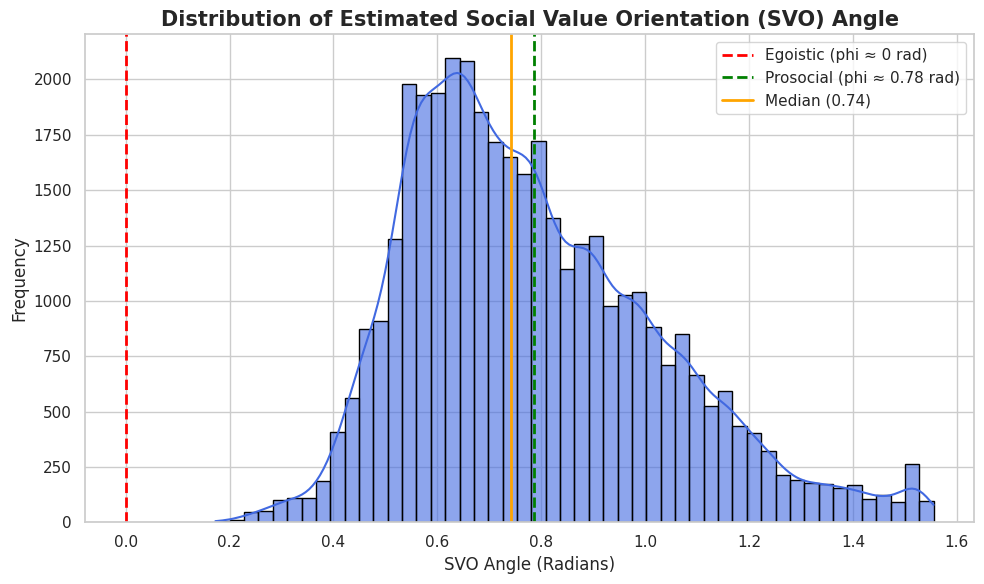

Statistical Summary of SVO Angle:
count    38445.000000
mean         0.784333
std          0.243117
min          0.172725
25%          0.601471
50%          0.741692
75%          0.933771
max          1.555338
Name: svo_angle, dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set theme for the plot
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Plot the histogram and Kernel Density Estimate (KDE)
sns.histplot(
    df_model_delayed['svo_angle'].dropna(),
    bins=50,
    kde=True,
    color='royalblue',
    edgecolor='black',
    alpha=0.6
)

# Add reference lines based on the Schwarting et al. (2019) model
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Egoistic (phi ≈ 0 rad)')
plt.axvline(np.pi/4, color='green', linestyle='--', linewidth=2, label='Prosocial (phi ≈ 0.78 rad)')
plt.axvline(df_model_delayed['svo_angle'].median(), color='orange', linestyle='-', linewidth=2, label=f"Median ({df_model_delayed['svo_angle'].median():.2f})")


plt.title("Distribution of Estimated Social Value Orientation (SVO) Angle", fontsize=15, fontweight='bold')
plt.xlabel("SVO Angle (Radians)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Print statistical summary directly below the plot
print("Statistical Summary of SVO Angle:")
print(df_model_delayed['svo_angle'].describe())

### 6.4 Feature Selection for NEAT using Random Forest

Now that some features are engineered, instead of guessing which combination works best, I define multiple feature sets and let the algorithms test them all against each other. To make a first "best" selection I utilized a Random Forest regressor to analyze the Gini importance (mean decrease in impurity) to determine which features are most predictive of the ego vehicle's acceleration (`a_ego`). This is not the same as a NEAT algorithm, but it shows me which features are the most distinctive. The code here does this for the normal and delayed featureset.

The more features availble, does not nescessary lead to better results. The main reasons for this are:

1. **Managing the Limitations of Small Networks:** Small ANNs are computationally efficient but inherently represent less complex mathematical functions than deep networks. Filtering out low-impact variables prevents the small evolved networks from using their limited capacity to process irrelevant noise (De Croon & van Kampen, 2026).
2. **Minimizing Dimensionality in the Search Space:** NEAT begins with a uniform population of minimal networks containing no hidden nodes (Stanley & Miikkulainen, 2002). The initial size of the search space depends entirely on the number of input features. Reducing the input vector drastically reduces dimensionality. This allows NEAT to discover optimal topologies much faster.

> De Croon, G., & van Kampen, E.-J. (2026). *AE4350: Bio-inspired Intelligence and Learning for Aerospace Applications* [Lecture slides]. Delft University of Technology.

> Stanley, K. O., & Miikkulainen, R. (2002). Efficient evolution of neural network topologies. In *Proceedings of the 2002 Congress on Evolutionary Computation (CEC '02)* (Vol. 2, pp. 1750-1755). IEEE.

 Analyzing Feature Importance: Standard vs. Delayed (both incl. SVO) ---


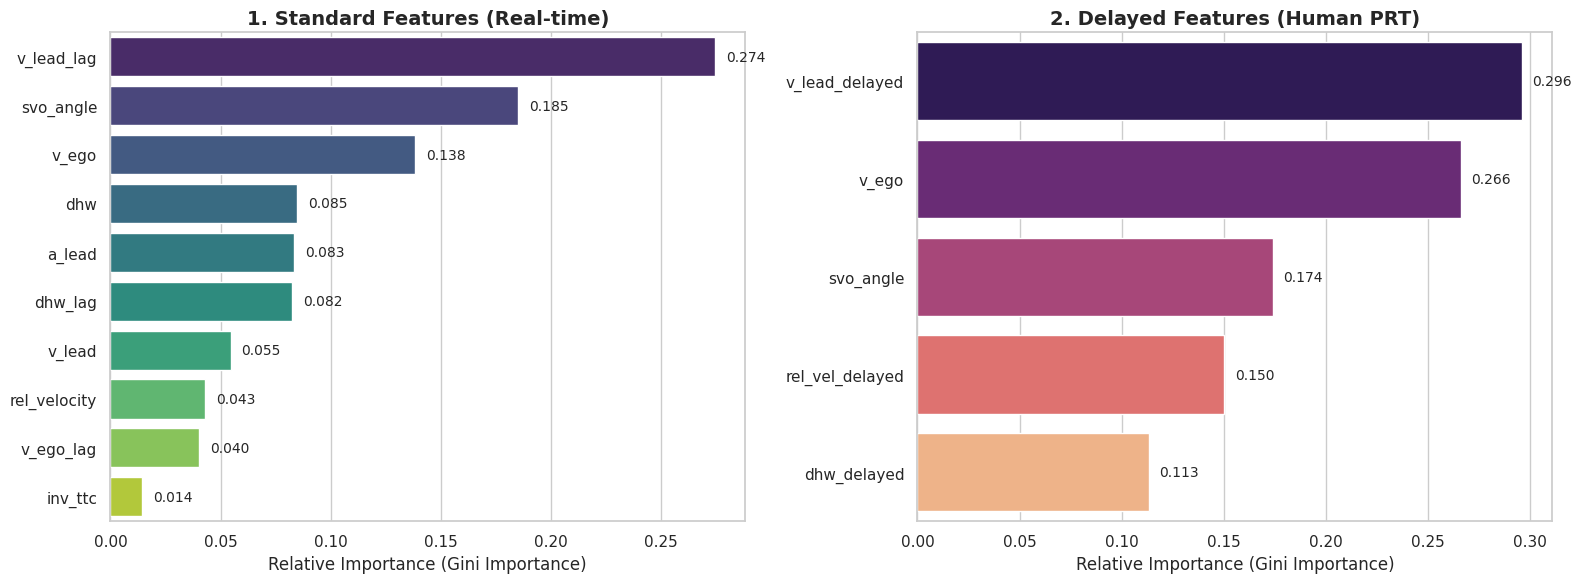


Top 3 Standard Features:


,Feature,Importance
4,v_lead_lag,0.274341
9,svo_angle,0.184976
0,v_ego,0.138177



Top 3 Delayed Features:


,Feature,Importance
1,v_lead_delayed,0.296004
0,v_ego,0.266192
4,svo_angle,0.174091


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# Define variables
TARGET_COL = 'a_ego'
SEED = 42

print(" Analyzing Feature Importance: Standard vs. Delayed (both incl. SVO) ---")

# =============================================================================
# 1. Standard Dataset (df_final)
# =============================================================================
features_standard = [
    "v_ego", "v_lead", "dhw",
    "v_ego_lag", "v_lead_lag", "dhw_lag",
    "a_lead", "rel_velocity", "inv_ttc",
    "svo_angle"
]

# Remove rows with NaN values (mainly caused by lag features)
df_rf_std = df_final.dropna(subset=features_standard + [TARGET_COL])

# Replace inf values with NaN to ensure compatibility with RandomForestRegressor
df_rf_std.replace([np.inf, -np.inf], np.nan, inplace=True)
df_rf_std.dropna(inplace=True) # Drop any rows that now contain NaN due to inf replacement

X_std = df_rf_std[features_standard]
y_std = df_rf_std[TARGET_COL]

# Train the model for the standard set
model_std = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
model_std.fit(X_std, y_std)

fi_std = pd.DataFrame({
    'Feature': features_standard,
    'Importance': model_std.feature_importances_
}).sort_values(by='Importance', ascending=False)


# =============================================================================
# 2. Delayed Dataset (df_model_delayed)
# =============================================================================
features_delayed = [
    "v_ego",
    "v_lead_delayed",
    "dhw_delayed",
    "rel_vel_delayed",
    "svo_angle" # Delayed SVO
]

# Remove rows with NaN values (caused by the delay shift)
df_rf_del = df_model_delayed.dropna(subset=features_delayed + [TARGET_COL])

# Replace inf values with NaN to ensure compatibility with RandomForestRegressor
df_rf_del.replace([np.inf, -np.inf], np.nan, inplace=True)
df_rf_del.dropna(inplace=True) # Drop any rows that now contain NaN due to inf replacement

X_del = df_rf_del[features_delayed]
y_del = df_rf_del[TARGET_COL]

# Train the model for the delayed set
model_del = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
model_del.fit(X_del, y_del)

fi_del = pd.DataFrame({
    'Feature': features_delayed,
    'Importance': model_del.feature_importances_
}).sort_values(by='Importance', ascending=False)


# =============================================================================
# 3. Plotting both results side-by-side
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Standard Features
sns.barplot(x='Importance', y='Feature', data=fi_std, hue='Feature', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('1. Standard Features (Real-time)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Relative Importance (Gini Importance)', fontsize=12)
axes[0].set_ylabel('')

# Add annotations
for index, value in enumerate(fi_std['Importance']):
    axes[0].text(value + 0.005, index, f'{value:.3f}', va='center', fontsize=10)

# Plot 2: Delayed Features
sns.barplot(x='Importance', y='Feature', data=fi_del, hue='Feature', palette='magma', legend=False, ax=axes[1])
axes[1].set_title('2. Delayed Features (Human PRT)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relative Importance (Gini Importance)', fontsize=12)
axes[1].set_ylabel('')

# Add annotations
for index, value in enumerate(fi_del['Importance']):
    axes[1].text(value + 0.005, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Brief textual summary
print("\nTop 3 Standard Features:")
display(fi_std.head(3))
print("\nTop 3 Delayed Features:")
display(fi_del.head(3))

Based on these results, `v_lead_lag` (0.274) and `v_lead_delayed` (0.296) are clearly the most influential features for predicting longitudinal acceleration in their respective categories. The svo_angle proves to be a strong and valuable addition (ranking high in both real-time and delayed configurations), while `inv_ttc` contributes minimally (0.014). Since `rel_vel_delayed` (0.150) and `dhw_delayed` (0.113) show healthy and stable importance scores without relying on instantaneous real-time noise, starting with a refined feature combinations, uch as `v_lead_delayed`, `v_ego`, `svo_angle`, and `rel_vel_delayed` provides a compact initial search space that ensures fast and stable convergence.

## 7 Model Baselines & Benchmarking

Before I train my evolutionary algorithm, it is essential to establish baseline performance metrics. By evaluating two "dumb" strategies, I create a reference point to objectively measure the evolutionary model's success.

To ensure a rigorous comparison and completely prevent data leakage, I first define a strict hold-out validation set of 15 randomly selected vehicles (`eval_vehicle_sample`). The baselines are evaluated *exclusively* on this hold-out set, mirroring the exact evaluation process used for the evolutionary models later in the notebook.

I incorporate two naive strategies:
*   **Zero Baseline:** Always predicting 0 m/s² (no acceleration).
*   **Mean Baseline:** Always predicting the mean acceleration. To maintain strict isolation, this mean is calculated only from the training vehicles and then applied to the test set.

These results will be saved in a `baselines.json` file for later use.

In [16]:
import pandas as pd
import numpy as np
import json
import os

TARGET_COL = 'a_ego'
GROUP_COL = 'source_vehicle_id'
SEED = 42

# Define the hold-out validation set here so ALL baselines and models use the exact same test vehicles
rng = np.random.default_rng(SEED)
if 'df_final' in globals() and not df_final.empty:
    all_vehicles = df_final[GROUP_COL].unique()
    eval_vehicle_sample = rng.choice(all_vehicles, size=min(15, len(all_vehicles)), replace=False)
    print(f"Selected {len(eval_vehicle_sample)} evaluation vehicles for benchmarking.")
else:
    eval_vehicle_sample = []

baselines = {}

def calculate_baselines(df, prefix, eval_vehicles):
    """Calculates baselines strictly on the evaluation set to prevent data leakage."""

    train_df = df[~df[GROUP_COL].isin(eval_vehicles)]
    test_df = df[df[GROUP_COL].isin(eval_vehicles)]

    print(f"\n=== Baselines for {prefix.upper()} dataset ===")
    print(f"Training rows: {len(train_df)} | Test rows: {len(test_df)}")
    print(f"Variance of {TARGET_COL} (Test Set): {test_df[TARGET_COL].var():.4f}")

    # Baseline 1: always predict the mean
    train_mean = train_df[TARGET_COL].mean()

    # Calculate Multi-Vehicle RMSE to match the final evolutionary evaluation scripts
    rmses_mean = []
    rmses_zero = []

    for vid in eval_vehicles:
        if vid not in test_df[GROUP_COL].values:
            continue
        vdf = test_df[test_df[GROUP_COL] == vid]
        y_true = vdf[TARGET_COL].values

        # Mean Baseline
        mean_preds = np.full_like(y_true, train_mean)
        rmses_mean.append(np.sqrt(np.mean((mean_preds - y_true)**2)))

        # Zero Baseline
        zero_preds = np.zeros_like(y_true)
        rmses_zero.append(np.sqrt(np.mean((zero_preds - y_true)**2)))

    mean_rmse = np.mean(rmses_mean)
    zero_rmse = np.mean(rmses_zero)

    print(f"RMSE Mean Baseline: {mean_rmse:.4f} ± {np.std(rmses_mean):.4f}")
    print(f"RMSE Zero Baseline: {zero_rmse:.4f} ± {np.std(rmses_zero):.4f}")

    return {
        f"{prefix}_rmse_mean": mean_rmse,
        f"{prefix}_rmse_zero": zero_rmse
    }

# 1. Calculate baselines for the standard dataset
if 'df_final' in globals() and not df_final.empty:
    baselines.update(calculate_baselines(df_final, "standard", eval_vehicle_sample))
else:
    print("Cannot find df_final. Make sure the relevant cell has been executed.")

# 2. Calculate baselines specifically for the delayed dataset
if 'df_model_delayed' in globals() and not df_model_delayed.empty:
    baselines.update(calculate_baselines(df_model_delayed, "delayed", eval_vehicle_sample))
else:
    print("df_model_delayed not found.")

# Save results
with open('baselines.json', 'w') as f:
    json.dump(baselines, f, indent=4)

print("\nBaselines successfully saved to 'baselines.json'.")

Selected 15 evaluation vehicles for benchmarking.

=== Baselines for STANDARD dataset ===
Training rows: 36079 | Test rows: 4136
Variance of a_ego (Test Set): 0.1772
RMSE Mean Baseline: 0.4110 ± 0.1623
RMSE Zero Baseline: 0.4253 ± 0.1746

=== Baselines for DELAYED dataset ===
Training rows: 34534 | Test rows: 3911
Variance of a_ego (Test Set): 0.1352
RMSE Mean Baseline: 0.3581 ± 0.1133
RMSE Zero Baseline: 0.3762 ± 0.1243

Baselines successfully saved to 'baselines.json'.


## 8 NeuroEvolution of Augmenting Topologies (NEAT)
Now that the features are selected and the baselines are in place, I can start training. In this section I explain why I chose NEAT and how I built the fitness function.

### 8.1 Why NEAT?
NGSIM is often used in traffic research together with heavy deep learning models like LSTMs (Huang, Wu, & Lv, 2022; Schwarting et al., 2019). These models are computationally expensive and hard to interpret. NEAT is a lighter alternative: it starts from a minimal network and only grows when needed, so the resulting models stay small and are easier to inspect than a deep network (De Croon & van Kampen, 2026). This doesn't mean NEAT is fully transparent, the final network is still a set of weights, so it remains a black box in that sense too. But the search process itself is easier to follow: I can see exactly how the topology grew, which features were kept, and how complexity was added step by step, which gives more insight than a deep model where none of that is visible. There's also a practical reason: neat-python is a mature, well-supported library, which let me prototype quickly without building everything from scratch.

### 8.2 How I built the fitness function
The fitness function is the heart of any evolutionary algorithm: it defines what "good" driving behavior actually means. According to the "No Free Lunch" theorem (Wolpert & Macready, 1997), no single metric works best everywhere, so I wanted to be able to try out multiple variants. For this, I built a `NEATEvaluator` class that does three things: pulls a balanced sample of the data (`__init__`), evaluates each genome (`evaluate_genomes`), and calculates the final fitness score (`calculate_fitness`).

**Why the model shouldn't become "lazy".**
In my early tests I noticed the model quickly learns to just do nothing and constantly predicting 0 m/s². That makes sense: most of highway driving is stable cruising (Ali, McLaughlin, & Ahmadian, 2021), so if you sample random frames, "doing nothing" already scores well enough. To prevent this I built in two safeguards:
- **Balanced sampling** (`SUBSET_SIZE = 1000`): I split every batch fifty-fifty between active moments (hard braking/accelerating, where `|y| > 0.3`) and calm cruising. This way the model can't get away with only doing well on the calm parts.
- **Variance penalty**: I compare the variance of the predictions to the variance of the real data. If it drops below 50% (`VARIANCE_RATIO_LIMIT = 0.50`), the model gets a strong penalty (`VARIANCE_PENALTY_MULT = 2.0`). This forces the model to actually respond to the situation, instead of passively coasting along.

**The different ways I measure error.**
I test five variants against each other to see which one produces the most human-like behavior:
- **MSE** — the standard: large errors are penalized heavily (quadratically), but this makes it sensitive to outliers.
- **MAE** — penalizes errors linearly, which makes it more stable against the noise introduced by differentiating the raw NGSIM data (Thiemann, Treiber, & Kesting, 2008).
- **MSE + complexity** (`LAMBDA_COMPLEXITY = 0.001`) — on top of MSE, I also penalize the number of active connections in the network. This matches NEAT's own principle of starting as small as possible and only growing when it's actually needed (Stanley & Miikkulainen, 2002; De Croon & van Kampen, 2026).
- **Deadzone MSE** — errors smaller than a certain threshold count as zero. This comes from the idea that humans simply don't notice small differences in acceleration (Chouhan et al., 2025); being a few tenths of a m/s² off doesn't feel different to a driver. The exact threshold, and the asymmetric penalty below, vary across experiments rather than being fixed values.
- **Asymmetric penalty on over-accelerating**: I penalize overshoot (accelerating too hard) more heavily than undershoot (being too cautious), because accelerating too hard is more dangerous in reality than being slightly too slow. This factor also varies across the sweep.
- **Human-inspired** — a Huber-like loss (`HUBER_DELTA = 0.4`): it behaves like MSE for small errors and like MAE for large ones. This combines the best of both: sensitive enough to small differences, but not overly sensitive to outliers.

Because I built all these variants into the same class structure, my training loop can automatically cycle through them. This lets me later compare which fitness function produces the most human-like driving behavior.

**Note on the evaluation metric.** While MSE, MAE, and the other formulas above are used *during training* to define the evolutionary pressure, I don't use MSE or MAE to compare the final trained models against each other later on. Instead, for comparing models (NEAT vs. the hybrid EA, and against the baselines), I report **RMSE** (root mean squared error). I chose this because RMSE is expressed in the same units as the target itself (m/s²), which makes it directly interpretable as a "typical acceleration error", whereas MSE is in squared units and harder to reason about intuitively. So: MSE/MAE/etc. shape *how the model learns*, while RMSE is what I use to judge *how good the end result is*.

#### References

Ali, G., McLaughlin, S., & Ahmadian, M. (2021). Quantifying the effect of roadway, driver, vehicle, and location characteristics on the frequency of longitudinal and lateral accelerations. *Accident Analysis & Prevention*, 161, 106356.

Chouhan, R., Chavan, Y. B., Dhamaniya, A., & Antoniou, C. (2025). Impact of sensory distractions on reaction time: a comprehensive modeling approach. *Accident Analysis & Prevention*, 220, 108154.

De Croon, G., & van Kampen, E.-J. (2026). *AE4350: Bio-inspired Intelligence and Learning for Aerospace Applications* [Lecture slides]. Delft University of Technology.

Huang, Z., Wu, J., & Lv, C. (2022). Driving behavior modeling using naturalistic human driving data with inverse reinforcement learning. *IEEE Transactions on Intelligent Transportation Systems*, 23(8), 10239-10251.

Schwarting, W., Pierson, A., Alonso-Mora, J., Karaman, S., & Rus, D. (2019). Social behavior for autonomous vehicles. *Proceedings of the National Academy of Sciences*, 116(50), 24972-24978.

Stanley, K. O., & Miikkulainen, R. (2002). Efficient evolution of neural network topologies. In *Proceedings of the 2002 Congress on Evolutionary Computation (CEC '02)* (Vol. 2, pp. 1750-1755). IEEE.

Thiemann, C., Treiber, M., & Kesting, A. (2008). Estimating acceleration and lane-changing dynamics from next generation simulation trajectory data. *Transportation Research Record, 2088*(1), 90-101.

In [17]:
import numpy as np
import neat

class NEATEvaluator:
    # =========================================================================
    # CONFIGURATION & HYPERPARAMETERS (Centralized for easy tuning)
    # =========================================================================
    USE_STRATIFIED_SAMPLING = True # Toggle to test if stratified sampling affects performance (not the case)
    SUBSET_SIZE = 1000             # Number of frames selected when stratified sampling is active
    ACTIVE_THRESHOLD = 0.3         # Threshold defining active braking/accelerating frames

    # Fitness & Penalty Weights
    LAMBDA_COMPLEXITY = 0.001      # Penalty multiplier for adding network connections
    DEADZONE_THRESHOLD = 0.05      # Safe zone around perfect prediction (lowered for finer control)
    ASYM_PENALTY_FACTOR = 1.25     # Multiplier for over-acceleration errors (1.0 = unbiased)

    # Variance Penalty settings (prevents "lazy" behavior without over-penalizing)
    VARIANCE_RATIO_LIMIT = 0.50    # Minimum required variance ratio relative to target data
    VARIANCE_PENALTY_MULT = 2.0    # Multiplier for the penalty

    # Model & Loss settings
    PRED_CLIP_MIN = -2.5           # Minimum boundary for predicted acceleration
    PRED_CLIP_MAX = 2.5            # Maximum boundary for predicted acceleration
    HUBER_DELTA = 0.4              # Delta parameter for the Huber-like robust loss
    WARMUP_STEPS = 10              # Steps to let the recurrent network stabilize before evaluation

    def __init__(self, X_val, y_val, fitness_method="mse"):
        self.X_val = X_val
        self.y_val = y_val
        self.fitness_method = fitness_method

        # Conditionally apply Stratified Sampling based on the boolean flag
        if self.USE_STRATIFIED_SAMPLING and len(self.X_val) > self.SUBSET_SIZE:
            active_idx = np.where(np.abs(self.y_val) > self.ACTIVE_THRESHOLD)[0]
            cruise_idx = np.where(np.abs(self.y_val) <= self.ACTIVE_THRESHOLD)[0]

            n_active = min(len(active_idx), self.SUBSET_SIZE // 2)
            n_cruise = self.SUBSET_SIZE - n_active

            chosen_active = np.random.choice(active_idx, n_active, replace=False) if n_active > 0 else []
            chosen_cruise = np.random.choice(cruise_idx, n_cruise, replace=False)

            indices = np.concatenate([chosen_active, chosen_cruise]) if len(chosen_active) > 0 else chosen_cruise
            indices = np.sort(indices)

            self.X_subset = self.X_val[indices]
            self.y_subset = self.y_val[indices]
        else:
            # Use full validation data (or random subset if preferred when stratified is False)
            self.X_subset, self.y_subset = self.X_val, self.y_val

    def evaluate_genomes(self, genomes, config):
        for genome_id, genome in genomes:
            net = neat.nn.RecurrentNetwork.create(genome, config)
            net.reset()

            # WARM-UP: Initialize recurrent states to prevent extreme initial transients
            warmup = min(self.WARMUP_STEPS, len(self.X_subset))
            for i in range(warmup):
                net.activate(self.X_subset[i])

            # Evaluate performance after the warm-up period
            eval_len = len(self.X_subset) - warmup
            predictions = np.empty(eval_len)
            y_true_eval = self.y_subset[warmup:]

            for i, x in enumerate(self.X_subset[warmup:]):
                predictions[i] = net.activate(x)[0]

            genome.fitness = self.calculate_fitness(genome, predictions, y_true_eval)

    def calculate_fitness(self, genome, y_pred, y_true):
        if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
            return -9999.0

        # Clip predictions within safe physical margins
        y_pred = np.clip(y_pred, self.PRED_CLIP_MIN, self.PRED_CLIP_MAX)

        # 1. Base Errors & Asymmetry
        errors = y_pred - y_true
        asym_errors = np.where(errors > 0, errors * self.ASYM_PENALTY_FACTOR, errors)

        # 2. Variance Penalty (prevents the model from collapsing into a flat line)
        pred_variance = np.var(y_pred)
        target_variance = np.var(y_true)
        variance_ratio = pred_variance / (target_variance + 1e-6)

        variance_penalty = max(0.0, (self.VARIANCE_RATIO_LIMIT - variance_ratio)) * self.VARIANCE_PENALTY_MULT

        # 3. Huber-like Robust Loss (for the human_inspired regime)
        abs_err = np.abs(asym_errors)
        huber_loss = np.mean(np.where(abs_err <= self.HUBER_DELTA,
                                      0.5 * asym_errors**2,
                                      self.HUBER_DELTA * (abs_err - 0.5 * self.HUBER_DELTA)))

        # 4. Fitness Regimes
        mse = np.mean(asym_errors ** 2)
        mae = np.mean(np.abs(asym_errors))

        if self.fitness_method == "mse":
            fitness = -mse
        elif self.fitness_method == "mae":
            fitness = -mae
        elif self.fitness_method == "mse_complexity":
            n_connections = len([c for c in genome.connections.values() if c.enabled])
            fitness = -mse - (self.LAMBDA_COMPLEXITY * n_connections)
        elif self.fitness_method == "deadzone_mse":
            dz_errors = np.where(np.abs(asym_errors) < self.DEADZONE_THRESHOLD, 0.0, asym_errors)
            fitness = -np.mean(dz_errors ** 2)
        elif self.fitness_method == "human_inspired":
            fitness = -huber_loss
        else:
            raise ValueError(f"Unknown fitness method: {self.fitness_method}")

        return (fitness - variance_penalty) if np.isfinite(fitness) else -9999.0

### 8.3 NEAT Configuration and Theoretical Justification

To ensure the NEAT algorithm evolves efficiently, I need to define its hyperparameters based on neuroevolutionary theory. This section configures the starting topology, mutation rates, and species protection mechanisms.

I strictly based the configuration of the NEAT algorithm on the core principles of the original methodology and Evolutionary Robotics theory. A fundamental rule of NEAT is that it increases complexity only when necessary, starting with a minimal structure (Stanley & Miikkulainen, 2002). To enforce this, I start the population with zero hidden nodes, and inputs are directly connected to the output. By starting in the smallest possible dimension, the algorithm avoids optimizing unnecessary connections. This aligns with the principle that small neural networks are computationally efficient and more interpretable than deep networks (De Croon & van Kampen, 2026).

To maintain stability, synaptic weights and biases are strictly regulated. The parameters `weight_init_mean = 0.0` and `weight_init_stdev = 1.0` ensure new connections start with a random value from a standard normal distribution. Weights are bounded by `weight_max_value = 2.0` and `weight_min_value = -2.0` to prevent them from exploding during thousands of mutations. This ensures the refined control signal remains predictable (Stanley & Miikkulainen, 2002).

A crucial choice is the activation function. The `tanh` (hyperbolic tangent) function is used because it centers output around zero and forces it between -1 and 1. This matches driving dynamics: negative output for braking, zero for cruising, and positive for accelerating. Functions like sigmoid or ReLU would either prevent braking or allow uncontrolled, infinite acceleration.
Another important design choice is `feed_forward = False`, which allows the evolved networks to contain recurrent (feedback) connections rather than being purely feedforward. This is deliberate: car-following is a sequential task where the current action depends on recent history, not just the current instant. A recurrent structure gives the network an internal form of memory, letting it implicitly track short-term dynamics (e.g. whether the lead vehicle has been decelerating for a while) without needing every relevant time step explicitly provided as a separate input.
 Finally, structural innovations are protected via speciation, allowing new topologies time to optimize before competing with established ones (Stanley & Miikkulainen, 2002).

> Stanley, K. O., & Miikkulainen, R. (2002). Efficient evolution of neural network topologies. In *Proceedings of the 2002 Congress on Evolutionary Computation (CEC '02)* (Vol. 2, pp. 1750-1755). IEEE.

> De Croon, G., & van Kampen, E.-J. (2026). AE4350: Bio-inspired Intelligence and Learning for Aerospace Applications [Lecture slides]. Delft University of Technology.

In [18]:
import textwrap

# =============================================================================
# NEAT CONFIGURATION SETTINGS (OPTIMIZED TO PREVENT SPECIES CONFLICT)
# =============================================================================
POP_SIZE = 400
FITNESS_THRESHOLD = 100
NUM_HIDDEN_INIT = 0
FEED_FORWARD = "False"

BIAS_MUTATE_POWER = 0.5
WEIGHT_MUTATE_POWER = 0.8
WEIGHT_MUTATE_RATE = 0.9
WEIGHT_REPLACE_RATE = 0.2

CONN_ADD_PROB = 0.8
CONN_DELETE_PROB = 0.2
NODE_ADD_PROB = 0.4
NODE_DELETE_PROB = 0.1

COMPATIBILITY_THRESHOLD = 4.0
SURVIVAL_THRESHOLD = 0.2
ELITISM = 2
MAX_STAGNATION = 15
# =============================================================================

def generate_neat_config(num_inputs, config_path="config_neat.txt"):
    config_text = textwrap.dedent(f"""
        [NEAT]
        fitness_criterion     = max
        fitness_threshold     = {FITNESS_THRESHOLD}
        pop_size              = {POP_SIZE}
        reset_on_extinction   = False
        no_fitness_termination = False

        [DefaultGenome]
        num_inputs              = {num_inputs}
        num_outputs             = 1
        num_hidden              = {NUM_HIDDEN_INIT}
        feed_forward            = {FEED_FORWARD}
        initial_connection      = full_direct
        activation_default      = tanh
        activation_mutate_rate  = 0.2
        activation_options      = tanh
        aggregation_default     = sum
        aggregation_mutate_rate = 0.0
        aggregation_options     = sum
        bias_init_mean          = 0.0
        bias_init_stdev         = 2.0
        bias_max_value          = 2.5
        bias_min_value          = -2.5
        bias_mutate_power       = {BIAS_MUTATE_POWER}
        bias_mutate_rate        = 0.7
        bias_replace_rate       = 0.1
        conn_add_prob           = {CONN_ADD_PROB}
        conn_delete_prob        = {CONN_DELETE_PROB}
        enabled_default         = True
        enabled_mutate_rate     = 0.01
        node_add_prob           = {NODE_ADD_PROB}
        node_delete_prob        = {NODE_DELETE_PROB}
        weight_init_mean        = 0.0
        weight_init_stdev       = 1.0
        weight_max_value        = 2.0
        weight_min_value        = -2.0
        weight_mutate_power     = {WEIGHT_MUTATE_POWER}
        weight_mutate_rate      = {WEIGHT_MUTATE_RATE}
        weight_replace_rate     = {WEIGHT_REPLACE_RATE}
        compatibility_disjoint_coefficient = 1.0
        compatibility_weight_coefficient   = 0.5
        response_init_mean      = 1.0
        response_init_stdev     = 0.0
        response_max_value      = 3.5
        response_min_value      = -3.5
        response_mutate_power   = 0.1
        response_mutate_rate    = 0.1
        response_replace_rate   = 0.0

        [DefaultSpeciesSet]
        compatibility_threshold = {COMPATIBILITY_THRESHOLD}

        [DefaultStagnation]
        species_elitism       = 1
        max_stagnation        = {MAX_STAGNATION}

        [DefaultReproduction]
        elitism              = {ELITISM}
        survival_threshold   = {SURVIVAL_THRESHOLD}
        min_species_size     = 1
    """)
    with open(config_path, 'w') as f:
        f.write(config_text)
    return config_path

### 8.5 Automated Multi-Vehicle Hold-Out Evaluation & Fitness Regime Sweep
With the evaluation framework and network configuration ready, I execute the core training loop. This section automates training across all defined fitness regimes, using a fixed hold-out set of vehicles to evaluate generalization, while dynamically saving the best genomes and scalers for subsequent evaluation.

**Note on methodology.** I initially implemented this using full Leave-One-Vehicle-Out (LOVO) cross-validation, training a separate model for every individually held-out vehicle. In practice this turned out to be computationally too expensive given the number of feature sets and fitness regimes I wanted to sweep across. For the full training grid, LOVO would have required a separate NEAT run per vehicle per configuration, which can not be done in reasonable time. It also made it harder to fairly compare configurations against each other, since results depended on which specific vehicle happened to be held out in each fold. I therefore switched to a fixed multi-vehicle hold-out split: a single set of 15 vehicles is set aside for evaluation, one model is trained per fitness regime on all remaining vehicles, and that same model is then evaluated individually on each of the 15 held-out vehicles. This keeps the evaluation set identical across all configurations, making the comparison between fitness regimes more direct, at the cost of no longer testing generalization to every possible individual vehicle.

To rigorously test how different optimization pressures affect driving behavior, the script below executes a master loop. It iterates through the optimized feature set (`rf_optimized_delayed`) and sweeps across all implemented fitness methods (`mse`, `mae`, `mse_complexity`, `deadzone_mse`, and `human_inspired`).

Key components of this experiment runner include:
*   **Fixed Multi-Vehicle Hold-Out Split:** A set of 15 vehicles (`eval_vehicle_sample`) is excluded entirely from training and reserved for evaluation. Each trained model is tested on every one of these 15 unseen driver tracks (`source_vehicle_id`) individually, giving a distribution of per-vehicle RMSE scores rather than a single aggregate number.
*   **Target Scaling via `MaxAbsScaler`:** Specifically chosen to scale target accelerations while preserving the exact coordinate of zero acceleration ($0.0 \text{ m/s}^2$).
*   **Dynamic Checkpointing:** Each trained winner genome, along with its exact training scalers and configuration parameters, is automatically serialized and saved to disk (`experiment_results/`) for later visualization and comparison.
*   **Early Stopping:** Training halts early per configuration if the best fitness fails to improve by more than `min_delta` over `patience` generations (implemented via `EarlyStoppingReporter`), avoiding unnecessary computation once a run has plateaued.

In [19]:
import os
import random
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
import neat
from neat.reporting import BaseReporter
from tqdm.notebook import tqdm

# =============================================================================
# 1. CUSTOM REPORTERS & SETTINGS
# =============================================================================
class MinimalProgressReporter(BaseReporter):
    def __init__(self, print_every=5):
        self.print_every = print_every
        self.best_fitness_ever = -np.inf
        self.current_generation = 0

    def start_generation(self, generation):
        self.current_generation = generation

    def post_evaluate(self, config, population, species, best_genome):
        if best_genome.fitness is not None and best_genome.fitness > self.best_fitness_ever:
            self.best_fitness_ever = best_genome.fitness
        if self.current_generation % self.print_every == 0:
            print(f"    Gen {self.current_generation:3d} | Best Fitness: {best_genome.fitness:7.3f}")

class EarlyStoppingReporter(BaseReporter):
    def __init__(self, patience=5, min_delta=0.001, min_generations=5):
        self.patience = patience
        self.min_delta = min_delta
        self.min_generations = min_generations
        self.best_fitness = -np.inf
        self.stagnant_gens = 0
        self.current_generation = 0

    def start_generation(self, generation):
        self.current_generation = generation

    def post_evaluate(self, config, population, species, best_genome):
        if self.current_generation < self.min_generations: return
        if best_genome.fitness > self.best_fitness + self.min_delta:
            self.best_fitness = best_genome.fitness
            self.stagnant_gens = 0
        else:
            self.stagnant_gens += 1
        if self.stagnant_gens >= self.patience:
            raise StopIteration("Early stopping triggered")

# =============================================================================
# 2. EXPERIMENT GRID DEFINITION
# =============================================================================
SEED = 42
N_GENERATIONS = 50
TARGET_COL = 'a_ego'
GROUP_COL = 'source_vehicle_id'
RESULTS_DIR = "experiment_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Active fitness evaluation methods
FITNESS_METHODS = ["mse", "mae", "mse_complexity", "deadzone_mse", "human_inspired"]

# Feature sets established from baseline modeling
FEATURE_SETS = {
    "rf_optimized_delayed": [
        "v_ego",            # Own speed (instantaneous, as experienced by the driver)
        "dhw_delayed",      # Perceived space headway
        "rel_vel_delayed",  # Perceived relative velocity
        "svo_angle"         # Abstracted behavioral intent
    ],
    "rf_optimized_instantaneous": [  # Instantaneous (non-delayed) feature variant
        "v_ego",
        "dhw",
        "rel_velocity",
        "svo_angle"
    ]
}

EXPERIMENT_CONFIGS = []
for f_set_name, f_cols in FEATURE_SETS.items():
    # Dynamically assign the corresponding dataframe based on the feature set
    if "delayed" in f_set_name:
        df = df_model_delayed
    else:
        df = df_final  # Fallback to the non-delayed dataset

    for method in FITNESS_METHODS:
        EXPERIMENT_CONFIGS.append({
            "name": f"{f_set_name}_{method}",
            "df": df,
            "features": f_cols,
            "method": method
        })

# =============================================================================
# 3. EXPERIMENT RUNNER
# =============================================================================
def run_lovo_experiment(df, feature_cols, target_col, group_col, fitness_method,
                         generations, eval_vehicles, exp_name):
    random.seed(SEED)
    np.random.seed(SEED)

    config_path = generate_neat_config(num_inputs=len(feature_cols))
    neat_config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                              neat.DefaultSpeciesSet, neat.DefaultStagnation, config_path)

    # Exclude all evaluation vehicles from the training set to prevent data leakage
    train_df = df[~df[group_col].isin(eval_vehicles)]
    eval_df = df[df[group_col].isin(eval_vehicles)]

    X_train = train_df[feature_cols].values
    y_train = train_df[target_col].values

    # Utilize MaxAbsScaler for targets to ensure a 0.0 m/s^2 acceleration remains exactly 0.0
    scaler_X = StandardScaler().fit(X_train)
    scaler_y = MaxAbsScaler().fit(y_train.reshape(-1, 1))

    X_train_scaled = scaler_X.transform(X_train)
    y_train_scaled = scaler_y.transform(y_train.reshape(-1, 1)).flatten()

    evaluator = NEATEvaluator(X_train_scaled, y_train_scaled, fitness_method)
    population = neat.Population(neat_config)

    population.add_reporter(MinimalProgressReporter(print_every=5))
    population.add_reporter(EarlyStoppingReporter(patience=8))

    try:
        winner = population.run(evaluator.evaluate_genomes, generations)
    except StopIteration:
        winner = population.best_genome

    # Save the winning genome and scalers for downstream visualization
    save_path = os.path.join(RESULTS_DIR, f"{exp_name}_winner_fold01.pkl")
    with open(save_path, 'wb') as f:
        pickle.dump({
            "winner": winner,
            "scaler_X": scaler_X,
            "scaler_y": scaler_y,
            "feature_cols": feature_cols,
            "num_inputs": len(feature_cols),
        }, f)

    # Evaluate performance on the held-out vehicle set, including a recurrent warm-up phase
    per_vehicle_rmses = []
    for vid in eval_vehicles:
        if vid not in eval_df[group_col].values:
            continue
        vdf = eval_df[eval_df[group_col] == vid].sort_values('frame_id') \
              if 'frame_id' in eval_df.columns else eval_df[eval_df[group_col] == vid]

        net = neat.nn.RecurrentNetwork.create(winner, neat_config)
        net.reset()

        X_v_scaled = scaler_X.transform(vdf[feature_cols].values)
        warmup_steps = min(10, len(X_v_scaled))

        # Warm-up phase to initialize the hidden state of the recurrent network
        for i in range(warmup_steps):
            net.activate(X_v_scaled[i])

        preds = np.empty(len(X_v_scaled) - warmup_steps)
        for i, x in enumerate(X_v_scaled[warmup_steps:]):
            preds[i] = net.activate(x)[0]

        preds_orig = scaler_y.inverse_transform(preds.reshape(-1, 1)).flatten()
        y_v_eval = vdf[target_col].values[warmup_steps:]
        per_vehicle_rmses.append(np.sqrt(np.mean((preds_orig - y_v_eval) ** 2)))

    per_vehicle_rmses = np.array(per_vehicle_rmses)
    print(f"    {exp_name} | Multi-vehicle RMSE: {per_vehicle_rmses.mean():.4f} ± "
          f"{per_vehicle_rmses.std():.4f} (n={len(per_vehicle_rmses)}) | Saved: {save_path}")

    return [{'vehicle': vid, 'test_rmse': rmse} for vid, rmse in zip(eval_vehicles, per_vehicle_rmses)]

# =============================================================================
# 4. MASTER LOOP
# =============================================================================
# NOTE: eval_vehicle_sample is intentionally not redefined here. It was explicitly
# fixed in the preceding baseline section. Reusing this exact sample ensures that
# the baselines, NEAT, and the Hybrid EA are all evaluated on an identical set of
# held-out vehicles for a fair comparison.
assert 'eval_vehicle_sample' in globals() and len(eval_vehicle_sample) > 0, \
    "eval_vehicle_sample not found — run the baseline evaluation cell first."

all_results = {}
for config in EXPERIMENT_CONFIGS:
    print(f"\n{'='*60}\nRUNNING EXPERIMENT: {config['name']}\n{'='*60}")
    try:
        all_results[config['name']] = run_lovo_experiment(
            config['df'], config['features'], TARGET_COL, GROUP_COL, config['method'],
            N_GENERATIONS, eval_vehicle_sample, config['name']
        )
    except Exception as e:
        print(f"!!! CRITICAL FAILURE on {config['name']}: {e}")


RUNNING EXPERIMENT: rf_optimized_delayed_mse
    Gen   0 | Best Fitness:  -0.553
    Gen   5 | Best Fitness:  -0.228
    Gen  10 | Best Fitness:  -0.168
    Gen  15 | Best Fitness:  -0.137
    Gen  20 | Best Fitness:  -0.125
    Gen  25 | Best Fitness:  -0.099
    Gen  30 | Best Fitness:  -0.098
    Gen  35 | Best Fitness:  -0.067
    Gen  40 | Best Fitness:  -0.067
    rf_optimized_delayed_mse | Multi-vehicle RMSE: 0.4136 ± 0.2133 (n=15) | Saved: experiment_results/rf_optimized_delayed_mse_winner_fold01.pkl

RUNNING EXPERIMENT: rf_optimized_delayed_mae
    Gen   0 | Best Fitness:  -0.688
    Gen   5 | Best Fitness:  -0.323
    Gen  10 | Best Fitness:  -0.283
    Gen  15 | Best Fitness:  -0.272
    Gen  20 | Best Fitness:  -0.272
    rf_optimized_delayed_mae | Multi-vehicle RMSE: 0.5556 ± 0.2861 (n=15) | Saved: experiment_results/rf_optimized_delayed_mae_winner_fold01.pkl

RUNNING EXPERIMENT: rf_optimized_delayed_mse_complexity
    Gen   0 | Best Fitness:  -0.558
    Gen   5 | Best Fi

## 9 Model Visualization

### 9.1 Visualizing Model Performance via Kernel Density Estimation
To visually assess how well the evolved networks mimic human acceleration profiles, I load the saved model checkpoints from disk and compare their output distributions against actual human driving behavior.

The script below automates the evaluation and visualization process for all successfully trained models from fold 01:
*   **Dynamic Model Loading:** It scans the `experiment_results/` directory for saved winner genomes (`*_fold01.pkl`), dynamically extracting the exact input features and pre-trained scalers used during training.
*   **Reconstruction & Simulation:** Rebuilds the NEAT recurrent network structure using the configuration generator and, for each of the 15 held-out evaluation vehicles, resets its recurrent state to simulate a clean trajectory run on that vehicle's track.
*   **Distribution Comparison (KDE Plots):** Instead of just looking at raw error timelines, it plots Kernel Density Estimates (KDE) comparing the **Actual** human acceleration distribution (blue) against the **NEAT** model predictions (red), pooled across all 15 evaluation vehicles.
*   **Quantitative Metric:** Each subplot displays the corresponding root mean square error (`RMSE`), reported as the mean ± standard deviation across the 15 evaluation vehicles, allowing me to quickly compare which fitness function achieves both the lowest error and the most realistic behavioral spread.

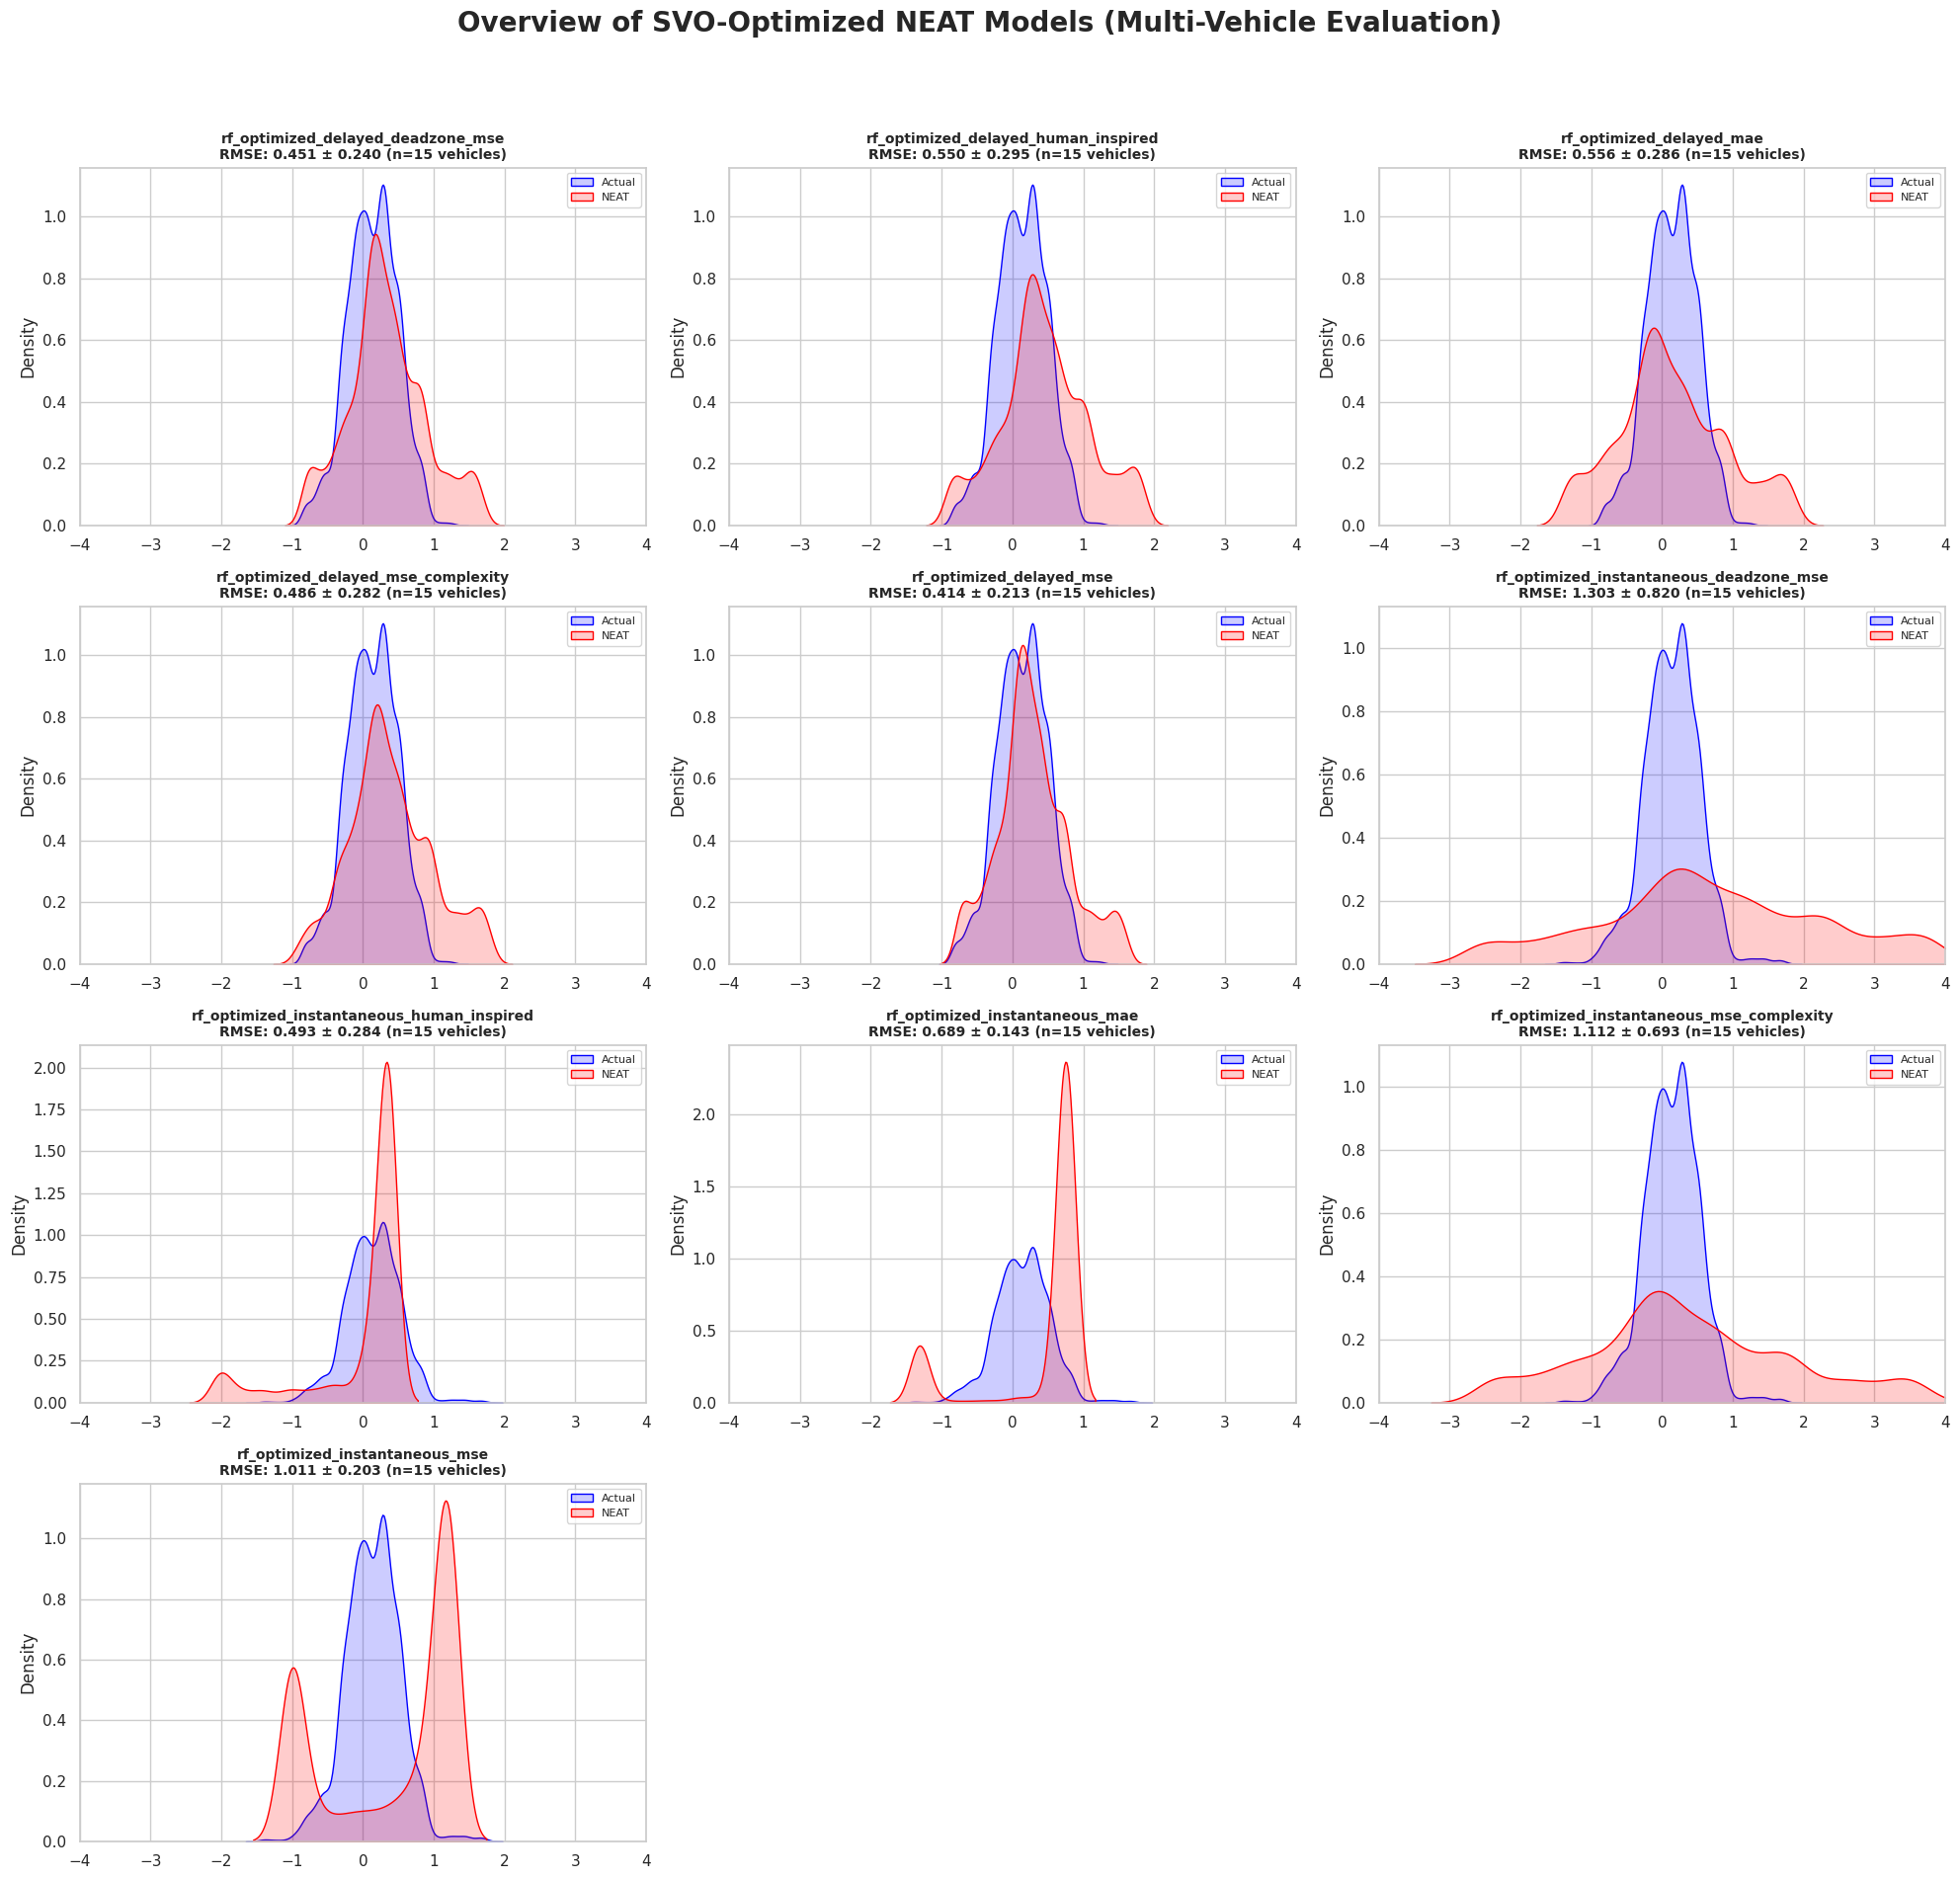

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import neat
import pickle
import os
import warnings
import glob
import inspect

# Suppress specific seaborn warnings related to zero-variance KDE plots to maintain a clean output
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

# Retrieve all saved fold01 model checkpoints from the results directory
model_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*_fold01.pkl")))

n_models = len(model_files)
cols = 3
rows = (n_models + cols - 1) // cols

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten() if n_models > 1 else [axes]

# Number of initial steps used to stabilize the recurrent state (must match training parameters)
WARMUP_STEPS = 10

for i, genome_path in enumerate(model_files):
    ax = axes[i]
    exp_full_name = os.path.basename(genome_path).replace("_winner_fold01.pkl", "")

    try:
        # Dynamically select the appropriate dataset based on the experiment naming convention
        # This inherently handles variants incorporating delayed features
        if "delayed" in exp_full_name:
            current_df = df_model_delayed
        else:
            current_df = df_final

        # Restore the trained genome, specific feature set, and corresponding scalers from the pickle file
        with open(genome_path, "rb") as f:
            saved = pickle.load(f)

        winner = saved["winner"]
        scaler_X = saved["scaler_X"]
        scaler_y = saved["scaler_y"]
        current_features = saved["feature_cols"]

        # Reconstruct the NEAT configuration necessary to instantiate the network structure
        # Accommodate potential variations in the generate_neat_config function signature
        # (e.g., presence or absence of the pop_size parameter)
        temp_cfg = f"temp_config_plot_{i}.txt"
        if 'pop_size' in inspect.signature(generate_neat_config).parameters:
            generate_neat_config(num_inputs=saved["num_inputs"], pop_size=POP_SIZE, config_path=temp_cfg)
        else:
            generate_neat_config(num_inputs=saved["num_inputs"], config_path=temp_cfg)

        neat_config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                                  neat.DefaultSpeciesSet, neat.DefaultStagnation, temp_cfg)

        # EVALUATION PHASE: Aggregate predictions across the held-out vehicle sample
        all_y_test = []
        all_preds_orig = []
        per_vehicle_rmses = []

        for vid in eval_vehicle_sample:
            if vid not in current_df[GROUP_COL].values:
                continue

            test_data = current_df[current_df[GROUP_COL] == vid].sort_values('frame_id')
            y_test_full = test_data[TARGET_COL].values

            net = neat.nn.RecurrentNetwork.create(winner, neat_config)
            net.reset()  # Reset the recurrent hidden state for each independent vehicle trajectory

            X_test_scaled = scaler_X.transform(test_data[current_features].values)

            # WARM-UP PHASE: Propagate initial frames to stabilize the recurrent network's memory
            warmup = min(WARMUP_STEPS, len(X_test_scaled))
            for j in range(warmup):
                net.activate(X_test_scaled[j])

            # Generate predictions strictly for the post-warm-up segment
            preds_scaled = np.empty(len(X_test_scaled) - warmup)
            for j, x in enumerate(X_test_scaled[warmup:]):
                preds_scaled[j] = net.activate(x)[0]

            preds_orig = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
            y_test = y_test_full[warmup:]

            all_y_test.append(y_test)
            all_preds_orig.append(preds_orig)
            per_vehicle_rmses.append(np.sqrt(np.mean((preds_orig - y_test) ** 2)))

        y_test = np.concatenate(all_y_test)
        preds_orig = np.concatenate(all_preds_orig)
        per_vehicle_rmses = np.array(per_vehicle_rmses)
        # END EVALUATION PHASE

        # Plot the aggregated Kernel Density Estimates (KDE) comparing empirical vs. predicted distributions
        sns.kdeplot(y_test, color='blue', label='Actual', fill=True, alpha=0.2, ax=ax)
        sns.kdeplot(preds_orig, color='red', label='NEAT', fill=True, alpha=0.2, ax=ax, warn_singular=False)

        ax.set_title(
            f"{exp_full_name}\n"
            f"RMSE: {per_vehicle_rmses.mean():.3f} ± {per_vehicle_rmses.std():.3f} "
            f"(n={len(per_vehicle_rmses)} vehicles)",
            fontsize=10, fontweight='bold'
        )
        ax.set_xlim([-4, 4])
        ax.legend(prop={'size': 8})

    except Exception as e:
        ax.set_title(f"Error: {exp_full_name}")
        print(f"Error evaluating {exp_full_name}: {e}")

# Deactivate empty subplot axes for a cleaner visualization grid
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Overview of SVO-Optimized NEAT Models (Multi-Vehicle Evaluation)", fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 9.2 Visualizing Model Prediction Errors Over Time

To visually analyze where and how the models make prediction errors during a trajectory, the script below loads the saved checkpoints, evaluates their performance on a selected test vehicle, selects the top 3 models based on RMSE, and plots their sequential predictions against the actual driver's acceleration profile.

#### Code Overview
* **Test Vehicle Selection:** It selects a specific test vehicle (`test_vehicle`) from the dataset and sorts its trajectory chronologically by `frame_id`.
* **Model Scoring & Ranking:** It scans the results directory for saved checkpoints (`*_fold01.pkl`), loads each model with its specific training scalers and feature set, runs inference on the test vehicle data, and computes the Root Mean Square Error (`RMSE`) to identify the **top 3 best-performing models**.
* **Chronological Time-Series Plot:** It generates a line plot comparing the true human driver's acceleration (solid black line) directly against the sequential predictions of the top 3 NEAT models (dashed colored lines), allowing for a clear visual breakdown of where tracking deviations occur.

=== Identifying Top 3 NEAT Models ===

=== RMSE over Multiple Vehicles (Top 3 Models) ===
rf_optimized_delayed_mse: single-vehicle RMSE=0.372 | multi-vehicle RMSE=0.414 ± 0.213 (n=15)
rf_optimized_delayed_deadzone_mse: single-vehicle RMSE=0.397 | multi-vehicle RMSE=0.451 ± 0.240 (n=15)
rf_optimized_delayed_mse_complexity: single-vehicle RMSE=0.421 | multi-vehicle RMSE=0.486 ± 0.282 (n=15)


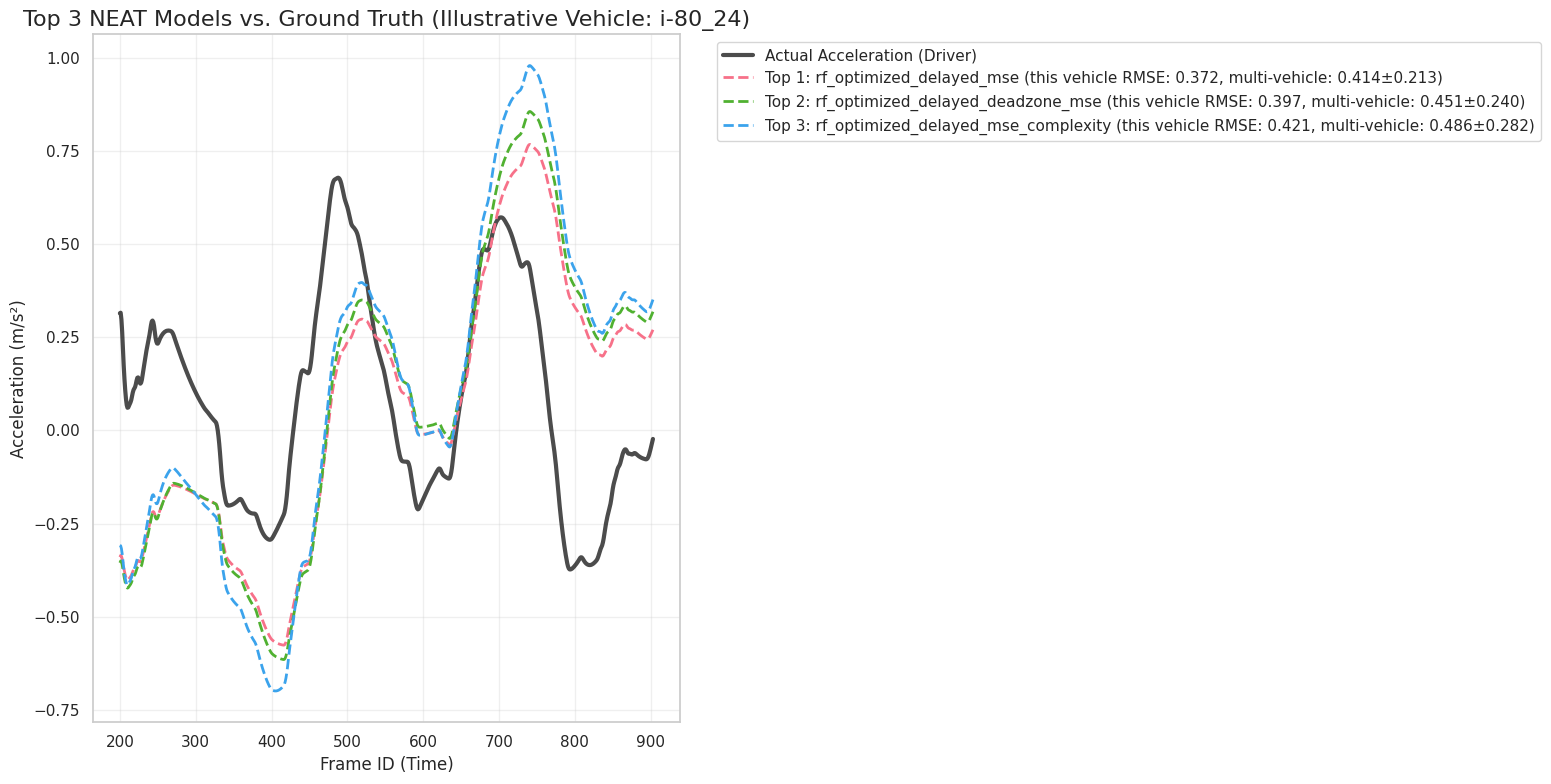

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
import os
import glob
import inspect
import neat
from sklearn.preprocessing import StandardScaler, MaxAbsScaler

# Number of initial steps used to stabilize the recurrent state
WARMUP_STEPS = 10

# =========================================================================
# 1. ILLUSTRATIVE VEHICLE SELECTION
# =========================================================================
# Select a test vehicle strictly from the unseen evaluation sample
test_vehicle = eval_vehicle_sample[0]

# =========================================================================
# 2. MODEL DISCOVERY & INTERMEDIATE EVALUATION
# =========================================================================
# Retrieve all saved fold01 model checkpoints
model_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*_fold01.pkl")))

if not model_files:
    print("No models found in experiment_results. Please run the training loop first.")
else:
    print("=== Identifying Top 3 NEAT Models ===")
    model_scores = []

    for model_path in model_files:
        try:
            with open(model_path, "rb") as f:
                saved_data = pickle.load(f)

            exp_name = os.path.basename(model_path).replace("_winner_fold01.pkl", "")

            # Dynamically route to the correct dataset based on feature delay mapping
            current_data = df_model_delayed if "delayed" in exp_name else df_final
            vehicle_data = current_data[current_data[GROUP_COL] == test_vehicle].sort_values('frame_id')

            # Reconstruct the NEAT configuration
            temp_cfg = "temp_eval.txt"
            if 'pop_size' in inspect.signature(generate_neat_config).parameters:
                generate_neat_config(num_inputs=len(saved_data["feature_cols"]), pop_size=POP_SIZE, config_path=temp_cfg)
            else:
                generate_neat_config(num_inputs=len(saved_data["feature_cols"]), config_path=temp_cfg)

            config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                                 neat.DefaultSpeciesSet, neat.DefaultStagnation, temp_cfg)

            net = neat.nn.RecurrentNetwork.create(saved_data["winner"], config)
            net.reset()

            X_scaled = saved_data["scaler_X"].transform(vehicle_data[saved_data["feature_cols"]].values)

            # WARM-UP PHASE: Propagate initial frames to stabilize memory
            warmup = min(WARMUP_STEPS, len(X_scaled))
            for j in range(warmup):
                net.activate(X_scaled[j])

            # Generate predictions strictly for the post-warm-up segment
            preds_scaled = np.empty(len(X_scaled) - warmup)
            for j, x in enumerate(X_scaled[warmup:]):
                preds_scaled[j] = net.activate(x)[0]

            preds_orig = saved_data["scaler_y"].inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
            actual_y = vehicle_data[TARGET_COL].values[warmup:]

            rmse = np.sqrt(np.mean((preds_orig - actual_y)**2))
            model_scores.append((model_path, rmse, exp_name))
        except Exception as e:
            print(f"Skipping {model_path} due to error: {e}")
            continue

    # Sort models by their RMSE performance and isolate the top 3
    top_3_models = sorted(model_scores, key=lambda x: x[1])[:3]

    # =========================================================================
    # 3. MULTI-VEHICLE GENERALIZATION CHECK (TOP 3 MODELS)
    # =========================================================================
    print("\n=== RMSE over Multiple Vehicles (Top 3 Models) ===")
    multi_vehicle_scores = {}

    for model_path, single_rmse, exp_name in top_3_models:
        with open(model_path, "rb") as f:
            saved_data = pickle.load(f)

        current_data = df_model_delayed if "delayed" in exp_name else df_final

        temp_cfg = "temp_multi_eval.txt"
        if 'pop_size' in inspect.signature(generate_neat_config).parameters:
            generate_neat_config(num_inputs=len(saved_data["feature_cols"]), pop_size=POP_SIZE, config_path=temp_cfg)
        else:
            generate_neat_config(num_inputs=len(saved_data["feature_cols"]), config_path=temp_cfg)

        config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation, temp_cfg)

        per_vehicle_rmses = []
        for vid in eval_vehicle_sample:
            if vid not in current_data[GROUP_COL].values:
                continue

            vdf = current_data[current_data[GROUP_COL] == vid].sort_values('frame_id')

            net = neat.nn.RecurrentNetwork.create(saved_data["winner"], config)
            net.reset()  # Reset recurrent state per vehicle

            X_scaled = saved_data["scaler_X"].transform(vdf[saved_data["feature_cols"]].values)

            warmup = min(WARMUP_STEPS, len(X_scaled))
            for j in range(warmup):
                net.activate(X_scaled[j])

            preds_scaled = np.empty(len(X_scaled) - warmup)
            for j, x in enumerate(X_scaled[warmup:]):
                preds_scaled[j] = net.activate(x)[0]

            preds_orig = saved_data["scaler_y"].inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
            actual_y = vdf[TARGET_COL].values[warmup:]

            per_vehicle_rmses.append(np.sqrt(np.mean((preds_orig - actual_y) ** 2)))

        per_vehicle_rmses = np.array(per_vehicle_rmses)
        multi_vehicle_scores[exp_name] = per_vehicle_rmses

        print(f"{exp_name}: single-vehicle RMSE={single_rmse:.3f} | "
              f"multi-vehicle RMSE={per_vehicle_rmses.mean():.3f} ± {per_vehicle_rmses.std():.3f} "
              f"(n={len(per_vehicle_rmses)})")

    # =========================================================================
    # 4. TIME-SERIES VISUALIZATION ON ILLUSTRATIVE VEHICLE
    # =========================================================================
    plt.figure(figsize=(16, 8))

    # Retrieve the actual data specifically aligned with the delayed or instantaneous framework.
    # The delayed df is used as the default for ground truth plotting to maintain a consistent baseline timeline.
    test_df = df_model_delayed[df_model_delayed[GROUP_COL] == test_vehicle].sort_values('frame_id')

    # Plot ground truth starting *after* the warmup period to align exactly with model predictions
    plt.plot(test_df['frame_id'].values[WARMUP_STEPS:], test_df[TARGET_COL].values[WARMUP_STEPS:],
             label='Actual Acceleration (Driver)', color='black', linewidth=3, alpha=0.7)

    colors = sns.color_palette("husl", 3)

    for i, (model_path, rmse, exp_name) in enumerate(top_3_models):
        with open(model_path, "rb") as f:
            saved_data = pickle.load(f)

        current_data = df_model_delayed if "delayed" in exp_name else df_final
        vehicle_data = current_data[current_data[GROUP_COL] == test_vehicle].sort_values('frame_id')

        temp_cfg = f"temp_cfg_final_{i}.txt"
        if 'pop_size' in inspect.signature(generate_neat_config).parameters:
            generate_neat_config(num_inputs=len(saved_data["feature_cols"]), pop_size=POP_SIZE, config_path=temp_cfg)
        else:
            generate_neat_config(num_inputs=len(saved_data["feature_cols"]), config_path=temp_cfg)

        config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation, temp_cfg)

        net = neat.nn.RecurrentNetwork.create(saved_data["winner"], config)
        net.reset()

        X_scaled = saved_data["scaler_X"].transform(vehicle_data[saved_data["feature_cols"]].values)

        warmup = min(WARMUP_STEPS, len(X_scaled))
        for j in range(warmup):
            net.activate(X_scaled[j])

        preds_scaled = np.empty(len(X_scaled) - warmup)
        for j, x in enumerate(X_scaled[warmup:]):
            preds_scaled[j] = net.activate(x)[0]

        preds_orig = saved_data["scaler_y"].inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
        multi_rmse = multi_vehicle_scores[exp_name]

        plt.plot(vehicle_data['frame_id'].values[warmup:], preds_orig,
                 label=f"Top {i+1}: {exp_name} (this vehicle RMSE: {rmse:.3f}, "
                       f"multi-vehicle: {multi_rmse.mean():.3f}±{multi_rmse.std():.3f})",
                 linestyle='--', linewidth=2, color=colors[i])

    plt.title(f"Top 3 NEAT Models vs. Ground Truth (Illustrative Vehicle: {test_vehicle})", fontsize=16)
    plt.xlabel("Frame ID (Time)", fontsize=12)
    plt.ylabel("Acceleration (m/s²)", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

The results show that training on instantaneous (zero-delay) features creates a fundamentally harder learning problem than training on the human-delayed feature set, which is directly visible in the erratic density plots and distorted distributions of the real-time models. Because human drivers have a natural perception-reaction time, a zero-delay model is implicitly asked to associate the lead vehicle's braking with the ego driver's deceleration at the exact same timestep, even though the real driver responds roughly `1.5 seconds` later. This temporal mismatch alone would be expected to degrade performance across all instantaneous models to a similar degree.

However, the results show that the degradation is not uniform: it is concentrated almost entirely in the squared-error-based fitness regimes (mse, mse_complexity, deadzone_mse), where multi-vehicle RMSE roughly doubles to triples relative to the delayed models (1.01–1.30 vs. 0.41–0.49), while the MAE and human-inspired regimes remain comparable to their delayed counterparts (0.69 and 0.49, respectively). Since all five fitness methods were trained on identical instantaneous input features, this pattern points to the fitness function, not the temporal mismatch on its own, as the immediate driver of the failure. A plausible mechanism is that the near-contemporaneous relationship between the instantaneous headway/relative-velocity features and the target acceleration creates a harder, more circular input-output mapping for a small recurrent network to stabilize; under a quadratic loss, which penalizes large errors disproportionately, evolution is pushed toward extreme, oscillating outputs rather than a stable regression surface, producing the density spikes at the outer edges of the output range. Because MAE penalizes errors linearly, it is comparatively more tolerant of the same instability and does not exhibit the same collapse. This bounded, "extreme-value" behavior is also consistent with the mathematical ceiling imposed by the network's output activation and the MaxAbsScaler, which restrict predictions to the range of accelerations observed during training, but this bound appears to act as a constraint on an already-unstable optimization process rather than as the root cause itself.

It is worth noting that each configuration in this study was trained as a single NEAT run rather than averaged across multiple seeds, so some of this instability could in principle reflect ordinary run-to-run variance rather than a deterministic property of instantaneous features. Repeating the failing configurations with different random seeds would help distinguish a genuine feature-fitness interaction from an unlucky evolutionary trajectory.

The results for the delayed feature set are considerably more encouraging. Looking at the single-vehicle trace above, the model tracks the overall shape of the driver's acceleration profile reasonably well, but consistently lags the actual signal by a small margin and under-predicts the amplitude of sharp peaks for instance, undershooting the acceleration spike around frame `700–750` by roughly `0.2–0.4 m/s²`. This is broadly consistent with the intended reaction-delay mechanism, but suggests the fixed 1.5-second delay may be slightly too long, or that the recurrent network's own internal lag (accumulated through its hidden state) compounds with the explicit feature delay. Future work will test whether a shorter reaction delay improves temporal alignment, and whether the MaxAbsScaler is inadvertently compressing the model's dynamic range and limiting its ability to reproduce sharp accelerations and decelerations.

In [ ]:
import random
import numpy as np
import pandas as pd
import neat
from sklearn.preprocessing import StandardScaler, MaxAbsScaler

# =============================================================================
# QUICK DELAY SWEEP
# Determines the optimal reaction delay (DELAY_SECONDS) by evaluating the
# top 3 performing fitness methods across various temporal shifts.
# =============================================================================

def add_reaction_delay_generic(df, delay_frames):
    """
    Applies a reaction delay self-containedly.
    Returns a newly constructed DataFrame without altering global variables,
    ensuring safe repeated execution during parameter sweeps.
    """
    delayed_groups = []

    # Ensure the instantaneous relative velocity exists before shifting
    if 'rel_vel' not in df.columns:
        df['rel_vel'] = df['v_lead'] - df['v_ego']

    for track_id, group in df.groupby('source_vehicle_id'):
        group = group.copy().sort_values('frame_id')
        group['v_lead_delayed'] = group['v_lead'].shift(delay_frames)
        group['dhw_delayed'] = group['dhw'].shift(delay_frames)
        group['rel_vel_delayed'] = group['rel_vel'].shift(delay_frames)
        delayed_groups.append(group)

    return pd.concat(delayed_groups).dropna().reset_index(drop=True)


def quick_lovo_experiment(df, feature_cols, target_col, group_col, fitness_method,
                          generations, eval_vehicles, seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

    config_path = generate_neat_config(num_inputs=len(feature_cols))
    neat_config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                              neat.DefaultSpeciesSet, neat.DefaultStagnation, config_path)

    train_df = df[~df[group_col].isin(eval_vehicles)]
    eval_df = df[df[group_col].isin(eval_vehicles)]

    X_train = train_df[feature_cols].values
    y_train = train_df[target_col].values

    # Standard scaling logic confirmed safe by saturation diagnostics
    scaler_X = StandardScaler().fit(X_train)
    scaler_y = MaxAbsScaler().fit(y_train.reshape(-1, 1))

    X_train_scaled = scaler_X.transform(X_train)
    y_train_scaled = scaler_y.transform(y_train.reshape(-1, 1)).flatten()

    # Inject the specific fitness method provided by the sweep loop
    evaluator = NEATEvaluator(X_train_scaled, y_train_scaled, fitness_method)
    population = neat.Population(neat_config)
    population.add_reporter(EarlyStoppingReporter(patience=6))

    try:
        winner = population.run(evaluator.evaluate_genomes, generations)
    except StopIteration:
        winner = population.best_genome

    per_vehicle_rmses = []
    for vid in eval_vehicles:
        if vid not in eval_df[group_col].values:
            continue
        vdf = eval_df[eval_df[group_col] == vid].sort_values('frame_id')

        net = neat.nn.RecurrentNetwork.create(winner, neat_config)
        net.reset()

        X_v_scaled = scaler_X.transform(vdf[feature_cols].values)
        warmup_steps = min(20, len(X_v_scaled))

        # Warm-up phase to stabilize the recurrent network's hidden state
        for i in range(warmup_steps):
            net.activate(X_v_scaled[i])

        preds_scaled = np.empty(len(X_v_scaled) - warmup_steps)
        for i, x in enumerate(X_v_scaled[warmup_steps:]):
            preds_scaled[i] = net.activate(x)[0]

        preds_orig = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
        y_v_eval = vdf[target_col].values[warmup_steps:]
        per_vehicle_rmses.append(np.sqrt(np.mean((preds_orig - y_v_eval) ** 2)))

    return np.mean(per_vehicle_rmses), np.std(per_vehicle_rmses)


# =============================================================================
# SWEEP EXECUTION
# =============================================================================
DELAY_SWEEP = [0.0, 0.3, 0.5, 0.8, 1.0, 1.5]
TOP_FITNESS_METHODS = ["mse", "deadzone_mse", "mse_complexity"]
SWEEP_GENERATIONS = 20
FPS_HZ = 10 # Assuming 10Hz sampling rate; adjust if the data frequency differs

assert 'eval_vehicle_sample' in globals() and len(eval_vehicle_sample) > 0, \
    "eval_vehicle_sample not found; execute the baseline evaluation cell prior to running this sweep."

sweep_results = {}

print("=== Initiating Temporal Delay Sweep (Top 3 Fitness Methods) ===")
for delay_s in DELAY_SWEEP:
    delay_frames = int(delay_s * FPS_HZ)

    if delay_frames > 0:
        df_variant = add_reaction_delay_generic(df_final, delay_frames)
        feats = ["v_ego", "dhw_delayed", "rel_vel_delayed", "svo_angle"]
    else:
        df_variant = df_final.copy()
        # Compute instantaneous relative velocity if absent
        if 'rel_vel' not in df_variant.columns:
            df_variant['rel_vel'] = df_variant['v_lead'] - df_variant['v_ego']
        feats = ["v_ego", "dhw", "rel_vel", "svo_angle"]

    method_rmses = []

    # Evaluate the top 3 fitness functions for the current delay parameter
    for method in TOP_FITNESS_METHODS:
        mean_rmse, std_rmse = quick_lovo_experiment(
            df_variant, feats, TARGET_COL, GROUP_COL, method, SWEEP_GENERATIONS, eval_vehicle_sample
        )
        print(f"Delay={delay_s:.1f}s | Method={method:15s} -> RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")
        method_rmses.append(mean_rmse)

    # Calculate the average performance across all 3 methods to determine the most robust delay
    avg_delay_rmse = np.mean(method_rmses)
    sweep_results[delay_s] = avg_delay_rmse
    print(f"--> Average RMSE for Delay {delay_s:.1f}s: {avg_delay_rmse:.4f}\n")

best_delay = min(sweep_results, key=sweep_results.get)
print(f"Optimal delay identified: {best_delay}s (Average RMSE: {sweep_results[best_delay]:.4f})")

if best_delay == 1.5:
    print("RESULT: 1.5 seconds was confirmed as the optimal delay parameter.")
else:
    print(f"RESULT: 1.5 seconds was sub-optimal. The delay parameter should be adjusted to {best_delay} seconds.")

=== Initiating Temporal Delay Sweep (Top 3 Fitness Methods) ===
Delay=0.0s | Method=mse             -> RMSE: 1.0052 ± 0.2053
Delay=0.0s | Method=deadzone_mse    -> RMSE: 1.3091 ± 0.8404
Delay=0.0s | Method=mse_complexity  -> RMSE: 1.1064 ± 0.7225
--> Average RMSE for Delay 0.0s: 1.1402

Delay=0.3s | Method=mse             -> RMSE: 0.7143 ± 0.5119
Delay=0.3s | Method=deadzone_mse    -> RMSE: 0.9238 ± 0.6295
Delay=0.3s | Method=mse_complexity  -> RMSE: 0.8178 ± 0.5126
--> Average RMSE for Delay 0.3s: 0.8187

Delay=0.5s | Method=mse             -> RMSE: 0.5989 ± 0.2824
Delay=0.5s | Method=deadzone_mse    -> RMSE: 0.9643 ± 0.4942
Delay=0.5s | Method=mse_complexity  -> RMSE: 0.7350 ± 0.4951
--> Average RMSE for Delay 0.5s: 0.7661

Delay=0.8s | Method=mse             -> RMSE: 0.5840 ± 0.3899
Delay=0.8s | Method=deadzone_mse    -> RMSE: 0.5840 ± 0.3899
Delay=0.8s | Method=mse_complexity  -> RMSE: 0.6341 ± 0.4212
--> Average RMSE for Delay 0.8s: 0.6007

Delay=1.0s | Method=mse             -> R

In [ ]:
# Independent test cell to verify the MaxAbsScaler saturation hypothesis

# Using df_model_delayed here (can be changed to df_final if needed)
test_df_data = df_model_delayed

# Split the data exactly as done in the experiment runner
train_df_test = test_df_data[~test_df_data[GROUP_COL].isin(eval_vehicle_sample)]
eval_df_test = test_df_data[test_df_data[GROUP_COL].isin(eval_vehicle_sample)]

# Extract the target column arrays (a_ego)
y_train_test = train_df_test[TARGET_COL].values
y_eval_test = eval_df_test[TARGET_COL].values

# Calculate the absolute maximums for both sets
train_max = np.abs(y_train_test).max()
eval_max = np.abs(y_eval_test).max()

print("=== MaxAbsScaler Saturation Check ===")
print(f"Max |a_ego| in Training set:   {train_max:.3f} m/s²")
print(f"Max |a_ego| in Evaluation set: {eval_max:.3f} m/s²")

if eval_max > train_max:
    print(f"\nRESULT: The evaluation set contains more extreme values.")
    print(f"Because the 'tanh' activation function asymptotically caps at exactly 1.0 (or -1.0),")
    print(f"and the scaler maps this limit to {train_max:.3f} m/s², it is mathematically impossible")
    print(f"for the network to ever predict the peak evaluation acceleration of {eval_max:.3f} m/s².")
else:
    print(f"\nRESULT: No saturation problem detected for this specific split.")
    print(f"The training maximum ({train_max:.3f}) is greater than the evaluation maximum ({eval_max:.3f}).")
    print("Therefore, the model has sufficient 'headroom' in its tanh output range to reach the evaluation peaks.")

Both hypothetical causes for "bad' behavior, possible saturation and non-optimal delay choice, are not validated. However, the illustrative vehicle could be non-optimal for this model, or even super optimal. This sweep exists to answer that question.

The script first ranks all saved NEAT checkpoints by their RMSE on a single test vehicle, and only then re-evaluates that shortlist of three across the full held-out evaluation sample. This two-step approach is deliberate: running the full multi-vehicle evaluation on every saved model would work just as well, but doing an initial single-vehicle filter first keeps the (fairly expensive) recurrent-network re-evaluation loop limited to a handful of promising candidates instead of the entire experiment grid.

The multi-vehicle numbers printed here matter more than the single-vehicle ones, since they show whether a model's apparent strength generalizes or was specific to this one trajectory, a gap between the two RMSE values would be a warning sign of overfitting to the illustrative vehicle rather than learning genuine driving behaviour. This same top-3 selection and multi-vehicle validation approach is what later feeds into Section 11, where the best-generalizing NEAT variant is picked out explicitly and compared head-to-head against the Elite Hybrid EA.

In [ ]:
import os
import random
import pickle
import textwrap
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
import neat
from tqdm.notebook import tqdm
from IPython.display import display

# =============================================================================
# 1. DYNAMIC NEAT EVALUATOR
# =============================================================================
class NEATEvaluator:
    USE_STRATIFIED_SAMPLING = True
    SUBSET_SIZE = 1000
    ACTIVE_THRESHOLD = 0.3
    VARIANCE_RATIO_LIMIT = 0.50
    VARIANCE_PENALTY_MULT = 2.0
    PRED_CLIP_MIN = -2.0
    PRED_CLIP_MAX = 2.0
    WARMUP_STEPS = 10

    def __init__(self, X_val, y_val, fitness_method="mse", lambda_complexity=0.001, deadzone_threshold=0.05, asym_penalty=1.0):
        self.X_val = X_val
        self.y_val = y_val
        self.fitness_method = fitness_method
        self.lambda_complexity = lambda_complexity
        self.deadzone_threshold = deadzone_threshold
        self.asym_penalty_factor = asym_penalty

        if self.USE_STRATIFIED_SAMPLING and len(self.X_val) > self.SUBSET_SIZE:
            active_idx = np.where(np.abs(self.y_val) > self.ACTIVE_THRESHOLD)[0]
            cruise_idx = np.where(np.abs(self.y_val) <= self.ACTIVE_THRESHOLD)[0]

            n_active = min(len(active_idx), self.SUBSET_SIZE // 2)
            n_cruise = self.SUBSET_SIZE - n_active

            chosen_active = np.random.choice(active_idx, n_active, replace=False) if n_active > 0 else []
            chosen_cruise = np.random.choice(cruise_idx, n_cruise, replace=False)

            indices = np.concatenate([chosen_active, chosen_cruise]) if len(chosen_active) > 0 else chosen_cruise
            indices = np.sort(indices)

            self.X_subset = self.X_val[indices]
            self.y_subset = self.y_val[indices]
        else:
            self.X_subset, self.y_subset = self.X_val, self.y_val

    def evaluate_genomes(self, genomes, config):
        for genome_id, genome in genomes:
            net = neat.nn.RecurrentNetwork.create(genome, config)
            net.reset()

            warmup = min(self.WARMUP_STEPS, len(self.X_subset))
            for i in range(warmup):
                net.activate(self.X_subset[i])

            eval_len = len(self.X_subset) - warmup
            predictions = np.empty(eval_len)
            y_true_eval = self.y_subset[warmup:]

            for i, x in enumerate(self.X_subset[warmup:]):
                predictions[i] = net.activate(x)[0]

            genome.fitness = self.calculate_fitness(genome, predictions, y_true_eval)

    def calculate_fitness(self, genome, y_pred, y_true):
        if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
            return -9999.0

        y_pred = np.clip(y_pred, self.PRED_CLIP_MIN, self.PRED_CLIP_MAX)
        errors = y_pred - y_true

        # Apply dynamic asymmetry penalty
        asym_errors = np.where(errors > 0, errors * self.asym_penalty_factor, errors)

        pred_variance = np.var(y_pred)
        target_variance = np.var(y_true)
        variance_ratio = pred_variance / (target_variance + 1e-6)
        variance_penalty = max(0.0, (self.VARIANCE_RATIO_LIMIT - variance_ratio)) * self.VARIANCE_PENALTY_MULT

        mse = np.mean(asym_errors ** 2)

        if self.fitness_method == "mse":
            fitness = -mse
        elif self.fitness_method == "mse_complexity":
            n_connections = len([c for c in genome.connections.values() if c.enabled])
            fitness = -mse - (self.lambda_complexity * n_connections)
        elif self.fitness_method == "deadzone_mse":
            dz_errors = np.where(np.abs(asym_errors) < self.deadzone_threshold, 0.0, asym_errors)
            fitness = -np.mean(dz_errors ** 2)
        else:
            raise ValueError(f"Unknown fitness method: {self.fitness_method}")

        return (fitness - variance_penalty) if np.isfinite(fitness) else -9999.0

# =============================================================================
# 2. DYNAMIC NEAT CONFIGURATION GENERATOR
# =============================================================================
def generate_neat_config_sweep(num_inputs, pop_size, config_path="config_neat.txt"):
    # Using the tight [-1.0, 1.0] weight bounds to prevent explosive variance
    config_text = textwrap.dedent(f"""
        [NEAT]
        fitness_criterion     = max
        fitness_threshold     = 100
        pop_size              = {pop_size}
        reset_on_extinction   = False
        no_fitness_termination = False

        [DefaultGenome]
        num_inputs              = {num_inputs}
        num_outputs             = 1
        num_hidden              = 0
        feed_forward            = False
        initial_connection      = full_direct
        activation_default      = tanh
        activation_mutate_rate  = 0.2
        activation_options      = tanh
        aggregation_default     = sum
        aggregation_mutate_rate = 0.0
        aggregation_options     = sum
        bias_init_mean          = 0.0
        bias_init_stdev         = 1.0
        bias_max_value          = 2.5
        bias_min_value          = -2.5
        bias_mutate_power       = 0.5
        bias_mutate_rate        = 0.7
        bias_replace_rate       = 0.1
        conn_add_prob           = 0.8
        conn_delete_prob        = 0.2
        enabled_default         = True
        enabled_mutate_rate     = 0.01
        node_add_prob           = 0.4
        node_delete_prob        = 0.1
        weight_init_mean        = 0.0
        weight_init_stdev       = 1.0
        weight_max_value        = 1.0
        weight_min_value        = -1.0
        weight_mutate_power     = 0.8
        weight_mutate_rate      = 0.9
        weight_replace_rate     = 0.2
        compatibility_disjoint_coefficient = 1.0
        compatibility_weight_coefficient   = 0.5
        response_init_mean      = 1.0
        response_init_stdev     = 0.0
        response_max_value      = 3.5
        response_min_value      = -3.5
        response_mutate_power   = 0.1
        response_mutate_rate    = 0.1
        response_replace_rate   = 0.0

        [DefaultSpeciesSet]
        compatibility_threshold = 4.0

        [DefaultStagnation]
        species_elitism       = 1
        max_stagnation        = 15

        [DefaultReproduction]
        elitism              = 2
        survival_threshold   = 0.2
        min_species_size     = 1
    """)
    with open(config_path, 'w') as f:
        f.write(config_text)
    return config_path

# =============================================================================
# 3. EXPERIMENT GRID & SWEEP CONFIGURATION
# =============================================================================
SEED = 42
TARGET_COL = 'a_ego'
GROUP_COL = 'source_vehicle_id'
RESULTS_DIR = "neat_sweep_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
SWEEP_SUMMARY_FILE = os.path.join(RESULTS_DIR, "neat_targeted_sweep_summary.csv")

# Target feature set for both tests
FEATURE_COLS = ["v_ego", "dhw_delayed", "rel_vel_delayed", "svo_angle"]

# Hyperparameter variants to test
LAMBDAS = [0.0001, 0.001, 0.005]       # For mse_complexity
DEADZONES = [0.01, 0.05, 0.1]          # For deadzone_mse
ASYM_PENALTIES = [1.0, 1.25, 1.5]      # Testing unbiased vs biased acceleration penalties
WARMUP_OPTIONS = [10, 20, 30]          # Frames the recurrent net runs before evaluation starts

EXPERIMENT_CONFIGS = []

# Generate sweep for mse_complexity
for lam in LAMBDAS:
    for asym in ASYM_PENALTIES:
        for warmup in WARMUP_OPTIONS:
            EXPERIMENT_CONFIGS.append({
                "name": f"mse_complexity_L{lam}_asym{asym}_w{warmup}",
                "method": "mse_complexity",
                "lambda_c": lam,
                "dz": 0.0,
                "asym": asym,
                "warmup": warmup
            })

# Generate sweep for deadzone_mse
for dz in DEADZONES:
    for asym in ASYM_PENALTIES:
        for warmup in WARMUP_OPTIONS:
            EXPERIMENT_CONFIGS.append({
                "name": f"deadzone_mse_dz{dz}_asym{asym}_w{warmup}",
                "method": "deadzone_mse",
                "lambda_c": 0.0,
                "dz": dz,
                "asym": asym,
                "warmup": warmup
            })

# =============================================================================
# 4. EXPERIMENT RUNNER
# =============================================================================
def run_neat_sweep(df, feature_cols, target_col, group_col, configs, generations, pop_size, eval_vehicles):
    config_path = generate_neat_config_sweep(num_inputs=len(feature_cols), pop_size=pop_size)
    neat_config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                              neat.DefaultSpeciesSet, neat.DefaultStagnation, config_path)

    results = []

    # Exclude ALL eval vehicles from training once, consistent with section 8.5's
    # run_lovo_experiment. Training on the other held-out vehicles would leak
    # their behavior into the model before it's evaluated on them.
    train_df = df[~df[group_col].isin(eval_vehicles)]
    eval_df = df[df[group_col].isin(eval_vehicles)]

    X_train_full = train_df[feature_cols].values
    y_train_full = train_df[target_col].values

    for config in tqdm(configs, desc="Running NEAT Sweep"):
        random.seed(SEED)
        np.random.seed(SEED)

        scaler_X = StandardScaler().fit(X_train_full)
        scaler_y = MaxAbsScaler().fit(y_train_full.reshape(-1, 1))

        X_train_scaled = scaler_X.transform(X_train_full)
        y_train_scaled = scaler_y.transform(y_train_full.reshape(-1, 1)).flatten()

        evaluator = NEATEvaluator(
            X_train_scaled, y_train_scaled,
            fitness_method=config["method"],
            lambda_complexity=config["lambda_c"],
            deadzone_threshold=config["dz"],
            asym_penalty=config["asym"]
        )

        population = neat.Population(neat_config)

        try:
            winner = population.run(evaluator.evaluate_genomes, generations)
        except StopIteration:
            winner = population.best_genome

        # Evaluate the single trained winner on every held-out vehicle,
        # same protocol as run_lovo_experiment in section 8.5. warmup_steps
        # is swept per config to test whether a longer recurrent-net settle
        # period reduces the startup transient seen in section 9.2.
        fold_rmses = []
        for vid in eval_vehicles:
            vdf = eval_df[eval_df[group_col] == vid]
            if vdf.empty:
                continue
            vdf = vdf.sort_values('frame_id') if 'frame_id' in vdf.columns else vdf

            net = neat.nn.RecurrentNetwork.create(winner, neat_config)
            net.reset()

            X_v_scaled = scaler_X.transform(vdf[feature_cols].values)
            warmup_steps = min(config["warmup"], len(X_v_scaled))
            for i in range(warmup_steps):
                net.activate(X_v_scaled[i])

            preds = np.empty(len(X_v_scaled) - warmup_steps)
            for i, x in enumerate(X_v_scaled[warmup_steps:]):
                preds[i] = net.activate(x)[0]

            preds_orig = scaler_y.inverse_transform(preds.reshape(-1, 1)).flatten()
            y_v_eval = vdf[target_col].values[warmup_steps:]
            fold_rmses.append(np.sqrt(np.mean((preds_orig - y_v_eval) ** 2)))

        avg_rmse = np.mean(fold_rmses)
        std_rmse = np.std(fold_rmses)
        results.append({
            "Model_Name": config["name"],
            "Fitness_Method": config["method"],
            "Lambda": config["lambda_c"],
            "Deadzone": config["dz"],
            "Asymmetry": config["asym"],
            "Warmup": config["warmup"],
            "Avg_RMSE": avg_rmse,
            "Std_RMSE": std_rmse,
            "N_Folds": len(fold_rmses)
        })

        pd.DataFrame(results).to_csv(SWEEP_SUMMARY_FILE, index=False)

    return pd.DataFrame(results).sort_values('Avg_RMSE')

# =============================================================================
# 5. MASTER LOOP EXECUTION (FAST PROTOTYPING)
# =============================================================================
TEST_POP_SIZE = 100       # Drastically reduced from 400 for speed
TEST_GENERATIONS = 25     # Halved from 50 for speed

print(f"Starting FAST NEAT Sweep (Pop: {TEST_POP_SIZE}, Gens: {TEST_GENERATIONS}) "
      f"across {len(eval_vehicle_sample)} vehicles...")

sweep_results_df = run_neat_sweep(
    df=df_model_delayed,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    group_col=GROUP_COL,
    configs=EXPERIMENT_CONFIGS,
    generations=TEST_GENERATIONS,
    pop_size=TEST_POP_SIZE,
    eval_vehicles=eval_vehicle_sample
)

print("\n--- FAST NEAT SWEEP RESULTS RANKED BY AVERAGE RMSE (mean ± std across vehicles) ---")
display(sweep_results_df)

# =============================================================================
# 6. TRAIN & SAVE THE OVERALL BEST MODEL
# =============================================================================
# Extract the configuration of the best performing model
best_model_name = sweep_results_df.iloc[0]['Model_Name']
best_config = next(cfg for cfg in EXPERIMENT_CONFIGS if cfg["name"] == best_model_name)

print(f"\n=== Training final model using best configuration: {best_model_name} ===")

# We can optionally bump up the population and generations for this final run
FINAL_POP_SIZE = 200
FINAL_GENERATIONS = 50

config_path = generate_neat_config_sweep(num_inputs=len(FEATURE_COLS), pop_size=FINAL_POP_SIZE)
neat_config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                          neat.DefaultSpeciesSet, neat.DefaultStagnation, config_path)

# Prepare training data (excluding evaluation vehicles entirely)
train_df = df_model_delayed[~df_model_delayed[GROUP_COL].isin(eval_vehicle_sample)]
X_train_full = train_df[FEATURE_COLS].values
y_train_full = train_df[TARGET_COL].values

scaler_X = StandardScaler().fit(X_train_full)
scaler_y = MaxAbsScaler().fit(y_train_full.reshape(-1, 1))

X_train_scaled = scaler_X.transform(X_train_full)
y_train_scaled = scaler_y.transform(y_train_full.reshape(-1, 1)).flatten()

evaluator = NEATEvaluator(
    X_train_scaled, y_train_scaled,
    fitness_method=best_config["method"],
    lambda_complexity=best_config["lambda_c"],
    deadzone_threshold=best_config["dz"],
    asym_penalty=best_config["asym"]
)

population = neat.Population(neat_config)
population.add_reporter(neat.StdOutReporter(True))
stats = neat.StatisticsReporter()
population.add_reporter(stats)

# Run the full training cycle
try:
    best_winner = population.run(evaluator.evaluate_genomes, FINAL_GENERATIONS)
except StopIteration:
    best_winner = population.best_genome

# Save the best model layout and scalers
best_model_path = os.path.join(RESULTS_DIR, f"{best_model_name}_best_final.pkl")
with open(best_model_path, "wb") as f:
    pickle.dump({
        "winner": best_winner,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
        "feature_cols": FEATURE_COLS,
        "num_inputs": len(FEATURE_COLS)
    }, f)

print(f"\nBest model saved successfully to: {best_model_path}")

# =============================================================================
# 7. VISUALIZE THE BEST MODEL (TIME-SERIES & KDE)
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

test_vehicle = eval_vehicle_sample[0]
print(f"\n=== Visualizing Best Model on Test Vehicle: {test_vehicle} ===")

# Prepare evaluation data for the target vehicle
vdf = df_model_delayed[df_model_delayed[GROUP_COL] == test_vehicle].sort_values('frame_id')
X_test_scaled = scaler_X.transform(vdf[FEATURE_COLS].values)
actual_y = vdf[TARGET_COL].values

# Initialize and warm up the network
net = neat.nn.RecurrentNetwork.create(best_winner, neat_config)
net.reset()

warmup = min(best_config["warmup"], len(X_test_scaled))
for j in range(warmup):
    net.activate(X_test_scaled[j])

# Generate predictions
preds_scaled = np.empty(len(X_test_scaled) - warmup)
for j, x in enumerate(X_test_scaled[warmup:]):
    preds_scaled[j] = net.activate(x)[0]

preds_orig = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
actual_y_eval = actual_y[warmup:]
frames_eval = vdf['frame_id'].values[warmup:]

rmse = np.sqrt(np.mean((preds_orig - actual_y_eval)**2))

# Plotting Side-by-Side: Time-Series and KDE
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Time Series
axes[0].plot(frames_eval, actual_y_eval, label='Actual Acceleration (Driver)', color='black', linewidth=2, alpha=0.7)
axes[0].plot(frames_eval, preds_orig, label=f'NEAT Prediction (RMSE: {rmse:.3f})', color='red', linestyle='--', linewidth=2)
axes[0].set_title(f"Time-Series Forecast", fontsize=14)
axes[0].set_xlabel("Frame ID (Time)")
axes[0].set_ylabel("Acceleration (m/s²)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: KDE Distribution
sns.kdeplot(actual_y_eval, color='black', label='Actual Dist', fill=True, alpha=0.2, ax=axes[1])
sns.kdeplot(preds_orig, color='red', label='Predicted Dist', fill=True, alpha=0.2, ax=axes[1], warn_singular=False)
axes[1].set_title(f"Error Distribution (KDE)", fontsize=14)
axes[1].set_xlabel("Acceleration (m/s²)")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([-4, 4])

plt.suptitle(f"Final Model Performance ({best_model_name}) on Vehicle {test_vehicle}", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 10 Custom-Made Evolutionary Algorithm

Following the exploratory runs with NEAT, I developed an alternative approach: a custom-made hybrid evolutionary algorithm inspired by Richard Aragon (2025). Writing my own genetic algorithm reduces the black-box nature of neural networks, giving me direct transparency and control while still allowing rapid sensitivity analyses across multiple feature sets and fitness functions.

The architecture starts from classical driver modeling, where human longitudinal driving is inherently regime-dependent. Instead of treating driving as one uniform equation, I designed the custom genome as a piecewise linear hybrid controller that splits the driving space into a close and a far regime based on a dynamic threshold:

$$a_{ego} =  \begin{cases}  \mathbf{w}_{close} \cdot \mathbf{x} + b_{close}, & \text{if } x_{split} < \theta \\  \mathbf{w}_{far} \cdot \mathbf{x} + b_{far}, & \text{if } x_{split} \ge \theta  \end{cases}$$

I chose this design specifically to address a limitation I ran into during the NEAT experiments. When I relied purely on unstructured neural networks optimized with standard loss functions, the optimization process frequently collapsed into a lazy strategy, where the model just predicted a near-constant acceleration of zero to minimize overall error. Unconstrained networks lack structural priors, so they struggle to capture the bimodal nature of human driving, where drivers actively alternate between sharp adjustments and smooth cruising.

To overcome this lazy-zero collapse, I built specialized robustness objectives into the evaluator: asymmetric penalties to prioritize collision avoidance, variance preservation to keep natural dynamic fluctuations intact, and a human-inspired Huber loss. Combined with the piecewise linear split, these constraints force the model to explicitly separate behaviors, so the controller actively engages with both reactive close-following adjustments and steady-state distance maintenance, while lag features and human-delayed perception variables account for biological reaction times.

Running this framework relies on a controlled set of global variables and hyperparameters. I fix the random seed via `SEED = 42` across Python and NumPy to keep the experiments reproducible, and route performance logs and summary files to `RESULTS_DIR = "experiment_results"`. For the initial sensitivity sweep in Section 10.1, I keep fitness evaluations fast by using a randomized subset defined by `SUBSET_SIZE = 2000`; once I move to refining the elite model in the sections that follow, I switch to a larger subset (`SUBSET_SIZE = 7500`) for more robust fitness evaluation. The optimization target is longitudinal acceleration (`TARGET_COL = 'a_ego'`), and data splitting uses `GROUP_COL = 'source_vehicle_id'` together with Leave-One-Group-Out cross-validation to test generalizability on unseen drivers. Safety is further enforced via `ASYM_PENALTY_FACTOR`, which heavily penalizes positive acceleration errors, and I run a systematic sensitivity analysis testing five feature sets across four distinct fitness formulations before selecting the best configuration to refine further.

Richard Aragon. (2025, February 6). *Evolutionary algorithms explained and explored* [Video]. YouTube. [https://www.youtube.com/watch?v=-0Vl3GqeK8s](https://www.youtube.com/watch?v=-0Vl3GqeK8s)

In [ ]:
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.model_selection import LeaveOneGroupOut
from tqdm.notebook import tqdm
from IPython.display import display

# =============================================================================
# 1. SETTINGS & SHARED NEAT CONSTANTS
# =============================================================================
SEED = 42
RESULTS_DIR = "experiment_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
HYBRID_SUMMARY_FILE = os.path.join(RESULTS_DIR, "hybrid_experiment_summary.csv")

SUBSET_SIZE = 2000  # sample size for fitness evaluation during evolution

# Shared constraints to ensure apples-to-apples comparison with NEAT
PRED_CLIP_MIN = -2.0
PRED_CLIP_MAX = 2.0
DEADZONE_THRESHOLD = 0.15
ASYM_PENALTY_FACTOR = 1.5
VARIANCE_RATIO_LIMIT = 0.50
VARIANCE_PENALTY_MULT = 2.0
WARMUP_STEPS = 10

TARGET_COL = 'a_ego'
GROUP_COL = 'source_vehicle_id'
N_GENERATIONS = 50
POP_SIZE = 60


FEATURE_SETS_HYBRID = {
    "minimal":       ["v_ego", "v_lead", "dhw"],
    "with_a_lead":   ["v_ego", "v_lead", "dhw", "a_lead"],
    "with_lags":     ["v_ego", "v_lead", "dhw", "v_lead_lag", "dhw_lag"],
    "full":          ["v_ego", "v_lead", "dhw", "v_lead_lag", "dhw_lag",
                      "a_lead", "rel_velocity", "inv_ttc"],
    "human_delayed": ["v_ego", "v_lead_delayed", "dhw_delayed", "rel_vel_delayed"]
}

FITNESS_FUNCTIONS_TO_TEST = ["mse", "mae", "deadzone_mse", "human_inspired"]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

# =============================================================================
# 2. THE GENOME (HYBRID CONTROLLER)
# =============================================================================
class HybridController:
    def __init__(self, split_feature, threshold, weights_close, weights_far, feature_columns):
        self.split_feature = split_feature
        self.threshold = threshold
        self.weights_close = np.array(weights_close)
        self.weights_far = np.array(weights_far)
        self.feature_columns = feature_columns
        self.fitness = -np.inf

    def predict_vectorized(self, X):
        """X is StandardScaler-scaled; output is clipped to the shared bounds."""
        split_idx = self.feature_columns.index(self.split_feature)
        mask = X[:, split_idx] < self.threshold

        preds = np.zeros(X.shape[0])
        preds[mask] = X[mask] @ self.weights_close[:-1] + self.weights_close[-1]
        preds[~mask] = X[~mask] @ self.weights_far[:-1] + self.weights_far[-1]

        return np.clip(preds, PRED_CLIP_MIN, PRED_CLIP_MAX)

# =============================================================================
# 3. THE EVALUATOR
# =============================================================================
class HybridEvaluator:
    def __init__(self, X_train, y_train, fitness_method="mse",
                 deadzone_threshold=DEADZONE_THRESHOLD,
                 asym_penalty=ASYM_PENALTY_FACTOR,
                 variance_ratio_limit=VARIANCE_RATIO_LIMIT,
                 variance_penalty_mult=VARIANCE_PENALTY_MULT):

        if len(X_train) > SUBSET_SIZE:
            idx = np.random.choice(len(X_train), SUBSET_SIZE, replace=False)
            self.X_eval = X_train[idx]
            self.y_eval = y_train[idx]
        else:
            self.X_eval, self.y_eval = X_train, y_train

        self.fitness_method = fitness_method
        self.deadzone_threshold = deadzone_threshold
        self.asym_penalty_factor = asym_penalty
        self.variance_ratio_limit = variance_ratio_limit
        self.variance_penalty_mult = variance_penalty_mult

    def evaluate_population(self, population):
        target_var = np.var(self.y_eval)

        for controller in population:
            preds = controller.predict_vectorized(self.X_eval)
            errors = preds - self.y_eval

            asym_errors = np.where(errors > 0, errors * self.asym_penalty_factor, errors)

            pred_var = np.var(preds)
            variance_ratio = pred_var / (target_var + 1e-6)
            variance_penalty = max(0.0, (self.variance_ratio_limit - variance_ratio)) * self.variance_penalty_mult

            delta = 0.4  # same Huber delta as NEAT config potential
            abs_err = np.abs(asym_errors)
            huber = np.where(
                abs_err <= delta,
                0.5 * asym_errors ** 2,
                delta * (abs_err - 0.5 * delta)
            )
            huber_loss = np.mean(huber)

            if self.fitness_method == "mse":
                fitness = -np.mean(asym_errors ** 2)
            elif self.fitness_method == "mae":
                fitness = -np.mean(np.abs(asym_errors))
            elif self.fitness_method == "deadzone_mse":
                dz_errors = np.where(np.abs(asym_errors) < self.deadzone_threshold, 0.0, asym_errors)
                fitness = -np.mean(dz_errors ** 2)
            elif self.fitness_method == "human_inspired":
                fitness = -huber_loss
            else:
                fitness = -np.mean(asym_errors ** 2)

            controller.fitness = fitness - variance_penalty if np.isfinite(fitness) else -1e6

# =============================================================================
# 4. GA ENGINE
# =============================================================================
class HybridGA:
    def __init__(self, feature_columns, pop_size=60, generations=30):
        self.feature_columns = feature_columns
        self.pop_size = pop_size
        self.generations = generations
        self.num_weights = len(feature_columns) + 1
        self.population = [self._create_random() for _ in range(pop_size)]

    def _create_random(self):
        weights_close = [random.gauss(0, 1.5) for _ in range(self.num_weights)]
        weights_far = [random.gauss(0, 1.5) for _ in range(self.num_weights)]
        weights_close[-1] = random.choice([-1.0, 1.0])
        weights_far[-1] = random.choice([-1.0, 1.0])

        return HybridController(random.choice(self.feature_columns), random.uniform(-1, 1),
                                weights_close, weights_far, self.feature_columns)

    def evolve(self, X_train, y_train, fitness_method):
        evaluator = HybridEvaluator(X_train, y_train, fitness_method)
        for gen in range(self.generations):
            evaluator.evaluate_population(self.population)
            self.population.sort(key=lambda c: c.fitness, reverse=True)

            new_pop = self.population[:4]
            while len(new_pop) < self.pop_size:
                p1 = max(random.sample(self.population[:20], 3), key=lambda c: c.fitness)
                stdev = 0.5
                child = HybridController(p1.split_feature, p1.threshold + random.gauss(0, stdev),
                                         p1.weights_close + np.random.normal(0, stdev, self.num_weights),
                                         p1.weights_far + np.random.normal(0, stdev, self.num_weights),
                                         p1.feature_columns)
                new_pop.append(child)
            self.population = new_pop
        return self.population[0]

# =============================================================================
# 5. EXPERIMENT RUNNER
# =============================================================================
def run_hybrid_sensitivity_analysis(df_main, df_delayed, eval_vehicles,
                                     generations=N_GENERATIONS, pop_size=POP_SIZE,
                                     warmup_steps=WARMUP_STEPS):
    results = []
    combos = [(fs_name, fs_list, fit_name)
              for fs_name, fs_list in FEATURE_SETS_HYBRID.items()
              for fit_name in FITNESS_FUNCTIONS_TO_TEST]

    for fs_name, fs_list, fit_name in tqdm(combos, desc="Testing Combinations"):
        current_df = df_delayed if fs_name == "human_delayed" else df_main

        set_seed(SEED)

        train_df = current_df[~current_df[GROUP_COL].isin(eval_vehicles)]
        eval_df = current_df[current_df[GROUP_COL].isin(eval_vehicles)]

        X_train_full = train_df[fs_list].values
        y_train_full = train_df[TARGET_COL].values

        scaler_X = StandardScaler().fit(X_train_full)
        scaler_y = MaxAbsScaler().fit(y_train_full.reshape(-1, 1))

        X_train_scaled = scaler_X.transform(X_train_full)
        y_train_scaled = scaler_y.transform(y_train_full.reshape(-1, 1)).flatten()

        ga = HybridGA(fs_list, pop_size=pop_size, generations=generations)
        winner = ga.evolve(X_train_scaled, y_train_scaled, fit_name)

        fold_rmses = []
        for vid in eval_vehicles:
            vdf = eval_df[eval_df[GROUP_COL] == vid]
            if vdf.empty: continue
            vdf = vdf.sort_values('frame_id') if 'frame_id' in vdf.columns else vdf

            X_v_scaled = scaler_X.transform(vdf[fs_list].values)
            warmup = min(warmup_steps, len(X_v_scaled))

            preds_scaled = winner.predict_vectorized(X_v_scaled[warmup:])
            preds_orig = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
            y_v_eval = vdf[TARGET_COL].values[warmup:]

            fold_rmses.append(np.sqrt(np.mean((preds_orig - y_v_eval) ** 2)))

        results.append({
            "combo_name": f"{fs_name}_{fit_name}",
            "fs_name": fs_name,
            "fit_name": fit_name,
            "rmse_hybrid_mean": np.mean(fold_rmses),
            "rmse_hybrid_std": np.std(fold_rmses),
            "n_vehicles": len(fold_rmses)
        })

    summary = pd.DataFrame(results)
    summary.to_csv(HYBRID_SUMMARY_FILE, index=False)
    return summary

print(f"Starting Optimized Hybrid EA across {len(eval_vehicle_sample)} vehicles...")
# Fast settings (pop_size=30, generations=10) used for quick evaluation overview
hybrid_summary = run_hybrid_sensitivity_analysis(df_final, df_model_delayed, eval_vehicle_sample, generations=10, pop_size=30)
display(hybrid_summary.sort_values('rmse_hybrid_mean'))

### 10.1 Sensitivity Analysis and Distribution Comparison

To evaluate how different feature combinations and loss configurations impact the performance of the custom Hybrid EA, a systematic sensitivity analysis was conducted across all feature sets and fitness functions. Following the visualization approach used earlier for NEAT, Kernel Density Estimation (KDE) distribution plots were generated to compare the predicted acceleration profiles against the actual human driving distribution for a test vehicle.

The evaluation script iterates through all combinations of feature configurations (`minimal`, `with_a_lead`, `with_lags`, `full`, and `human_delayed`) and fitness objectives (`mse`, `mae`, `deadzone_mse`, and `human_inspired`). For each combination, training data from all other vehicles is scaled via `StandardScaler`, and a quick evolutionary run (`pop_size=40`, `generations=25`) trains a `HybridGA` instance. The resulting controller generates vectorized predictions for the test vehicle, which are then pooled across the evaluation set and plotted alongside the true human distribution within a multi-panel subplot grid bounded between $-4$ and $4\text{ m/s}^2$ to highlight alignment accuracy and root-mean-square errors.

In [ ]:
# =============================================================================
# 1. KDE GRID PLOT PREPARATION
# =============================================================================
combos = list(itertools.product(FEATURE_SETS_HYBRID.items(), FITNESS_FUNCTIONS_TO_TEST))
n_models = len(combos)
cols = 3
rows = (n_models + cols - 1) // cols

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, ((fs_name, fs_list), fit_name) in enumerate(combos):
    ax = axes[i]
    combo_label = f"{fs_name}_{fit_name}"

    try:
        current_df = df_model_delayed if fs_name == "human_delayed" else df_final

        set_seed(SEED)

        train_data = current_df[~current_df[GROUP_COL].isin(eval_vehicle_sample)]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_data[fs_list].values)
        y_train = train_data[TARGET_COL].values

        # Fast evolution for visualization
        ga_demo = HybridGA(fs_list, pop_size=40, generations=25)
        winner = ga_demo.evolve(X_train, y_train, fit_name)

        all_actual = []
        all_preds = []
        per_vehicle_rmses = []

        for vid in eval_vehicle_sample:
            if vid not in current_df[GROUP_COL].values:
                continue
            vehicle_data = current_df[current_df[GROUP_COL] == vid].sort_values('frame_id')
            X_test_v = scaler.transform(vehicle_data[fs_list].values)
            preds_v = winner.predict_vectorized(X_test_v)

            all_actual.append(vehicle_data[TARGET_COL].values)
            all_preds.append(preds_v)
            per_vehicle_rmses.append(np.sqrt(np.mean((preds_v - vehicle_data[TARGET_COL].values) ** 2)))

        actual_pooled = np.concatenate(all_actual)
        preds_pooled = np.concatenate(all_preds)
        per_vehicle_rmses = np.array(per_vehicle_rmses)

        # Plotting distributions (pooled over multiple vehicles)
        sns.kdeplot(actual_pooled, color='black', label='Actual Dist', fill=True, alpha=0.2, ax=ax)
        sns.kdeplot(preds_pooled, color='green', label='Hybrid EA', fill=True, alpha=0.2, ax=ax, warn_singular=False)

        ax.set_title(
            f"{combo_label}\nRMSE: {per_vehicle_rmses.mean():.3f} ± {per_vehicle_rmses.std():.3f} "
            f"(n={len(per_vehicle_rmses)})",
            fontsize=10, fontweight='bold'
        )
        ax.set_xlim([-4, 4])
        ax.legend(prop={'size': 8})

    except Exception as e:
        ax.set_title(f"Error in {combo_label}", fontweight='bold')
        print(f"Detail error {combo_label}: {e}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Hybrid EA Acceleration Distributions ({len(eval_vehicle_sample)} Vehicles, Pooled)", fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

To observe how the three best combinations behave over time (rather than just as a distribution), they are retrained below and plotted as a time series against the actual acceleration of an illustrative vehicle, along with their RMSE across all evaluation vehicles.

In [ ]:
# =============================================================================
# 2. TOP 3 HYBRID MODELS TIME-SERIES PLOT
# =============================================================================
if os.path.exists(HYBRID_SUMMARY_FILE):
    summary_df = pd.read_csv(HYBRID_SUMMARY_FILE)
    top_3_combos = summary_df.sort_values('rmse_hybrid_mean').head(3)['combo_name'].tolist()
    print(f"Plotting top 3 models: {top_3_combos}")
else:
    print("Summary file not found. Defaulting to first 3 combinations.")
    top_3_combos = [f"{list(FEATURE_SETS_HYBRID.keys())[0]}_{FITNESS_FUNCTIONS_TO_TEST[0]}"]

test_vehicle = df_final[GROUP_COL].unique()[0]
test_df = df_final[df_final[GROUP_COL] == test_vehicle].sort_values('frame_id')

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

plt.plot(test_df['frame_id'], test_df['a_ego'], label='Actual Acceleration (Driver)', color='black', linewidth=3, alpha=0.7)

colors = sns.color_palette("bright", 3)
color_idx = 0

all_combos = list(itertools.product(FEATURE_SETS_HYBRID.items(), FITNESS_FUNCTIONS_TO_TEST))
print("\n=== RMSE over multiple vehicles (top 3 Hybrid GA combos) ===")

for (fs_name, fs_list), fit_name in all_combos:
    combo_name = f"{fs_name}_{fit_name}"

    if combo_name not in top_3_combos:
        continue

    try:
        current_df = df_model_delayed if fs_name == "human_delayed" else df_final
        if test_vehicle not in current_df[GROUP_COL].values:
            continue

        set_seed(SEED)
        train_data = current_df[~current_df[GROUP_COL].isin(eval_vehicle_sample)]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_data[fs_list].values)
        y_train = train_data[TARGET_COL].values

        ga = HybridGA(fs_list, pop_size=50, generations=30)
        winner = ga.evolve(X_train, y_train, fit_name)

        per_vehicle_rmses = []
        for vid in eval_vehicle_sample:
            if vid not in current_df[GROUP_COL].values:
                continue
            vdf = current_df[current_df[GROUP_COL] == vid].sort_values('frame_id')
            X_v = scaler.transform(vdf[fs_list].values)
            preds_v = winner.predict_vectorized(X_v)
            per_vehicle_rmses.append(np.sqrt(np.mean((preds_v - vdf[TARGET_COL].values) ** 2)))

        per_vehicle_rmses = np.array(per_vehicle_rmses)
        print(f"{combo_name}: multi-vehicle RMSE = {per_vehicle_rmses.mean():.3f} ± {per_vehicle_rmses.std():.3f} "
              f"(n={len(per_vehicle_rmses)})")

        vehicle_data = current_df[current_df[GROUP_COL] == test_vehicle].sort_values('frame_id')
        X_test_v = scaler.transform(vehicle_data[fs_list].values)
        preds = winner.predict_vectorized(X_test_v)

        plt.plot(vehicle_data['frame_id'], preds,
                 label=f"Hybrid: {combo_name} (this vehicle: {np.sqrt(np.mean((preds - vehicle_data[TARGET_COL].values)**2)):.3f}, "
                       f"multi-vehicle: {per_vehicle_rmses.mean():.3f}±{per_vehicle_rmses.std():.3f})",
                 linestyle='--', linewidth=2, color=colors[color_idx])
        color_idx += 1

    except Exception as e:
        print(f"Could not plot {combo_name}: {e}")

plt.title(f"Acceleration Profile Comparison: Top 3 Hybrid GA Models (Illustrative Vehicle: {test_vehicle})", fontsize=16, fontweight='bold')
plt.xlabel("Frame ID (Time)", fontsize=12)
plt.ylabel("Acceleration (m/s²)", fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10.2 Refinement of the Elite Hybrid Model and Baseline Comparison

The sensitivity analysis in 10.1 already served as the model-selection step for the Hybrid EA family: across all feature sets and fitness functions, the `with_lags` feature set combined with the `human_inspired` fitness function did not achieve the lowest single-vehicle RMSE, but showed the lowest variance across vehicles (multi-vehicle RMSE 0.382 ± 0.173, versus 0.371 ± 0.232 for `deadzone_mse` and 0.500 ± 0.286 for plain `mse`). The deadzone-based fitness in particular produces visible instability once the signal leaves the deadzone (see the sharp spikes around frames 550–600 and 800–900 in Figure X), while the plain MSE variant is systematically too conservative. Since this generalization test already identifies a single best-generalizing configuration, refining all three candidates further — as was done for the three NEAT variants — would duplicate that selection step at a much higher computational cost. Instead, compute budget is deliberately concentrated on pushing this one configuration further.

An elite configuration was therefore set up with an expanded population size (LARGE_POP_SIZE = 150) and a prolonged evolutionary run of EXTENDED_GENERATIONS = 1000, using a larger subset size of 7,500 for robust fitness evaluation.

The script instantiates a dedicated training routine on the full standardized dataset (`df_final`), extracting the optimal parameters through the `HybridGA` class. Once training concludes, the script performs a direct validation on a designated test vehicle (`test_vehicle`) and loads the best-performing baseline from an external JSON file (`baselines.json`). A comparative visualization is generated, plotting the actual human driver acceleration profile against the refined Elite Hybrid GA predictions.

Comparing against the mean-prediction baseline (the stronger of the two naive baselines, RMSE 0.409 ± 0.160) rather than the zero baseline gives a fairer picture: the refined Elite Hybrid GA reaches a multi-vehicle RMSE of 0.379 ± 0.167, a modest but consistent improvement, and the same result later confirmed (non-significantly, p = 0.1354) by the Wilcoxon test in Section 11.

In [ ]:
# =============================================================================
# 1. CONFIGURATION FOR THE 'ELITE' MODEL
# =============================================================================
BEST_FEATURES = FEATURE_SETS_HYBRID["with_lags"]
BEST_FITNESS = "human_inspired"
EXTENDED_GENERATIONS = 1000
LARGE_POP_SIZE = 150
SUBSET_SIZE = 7500
ASYM_PENALTY_FACTOR = 1.0

print(f"--- Starting refinement of the Elite Hybrid Model (Bias Enabled) ---")

set_seed(SEED)

train_data_elite = df_final[~df_final[GROUP_COL].isin(eval_vehicle_sample)]

scaler = StandardScaler()
X_train_full = scaler.fit_transform(train_data_elite[BEST_FEATURES].values)
y_train_full = train_data_elite[TARGET_COL].values

ga_elite = HybridGA(BEST_FEATURES, pop_size=LARGE_POP_SIZE, generations=EXTENDED_GENERATIONS)

print("Training in progress...")
winner_elite = ga_elite.evolve(X_train_full, y_train_full, BEST_FITNESS)

# 2. Multi-vehicle validation
per_vehicle_rmses = []
for vid in eval_vehicle_sample:
    if vid not in df_final[GROUP_COL].values:
        continue
    vdf = df_final[df_final[GROUP_COL] == vid].sort_values('frame_id')
    X_v = scaler.transform(vdf[BEST_FEATURES].values)
    preds_v = winner_elite.predict_vectorized(X_v)
    per_vehicle_rmses.append(np.sqrt(np.mean((preds_v - vdf[TARGET_COL].values) ** 2)))

per_vehicle_rmses = np.array(per_vehicle_rmses)
final_rmse = per_vehicle_rmses.mean()
final_rmse_std = per_vehicle_rmses.std()

# 3. Baseline Comparison
import json
with open('baselines.json', 'r') as f:
    baselines = json.load(f)

best_baseline_name = min(baselines, key=baselines.get)
best_baseline_rmse = np.sqrt(baselines[best_baseline_name])

print(f"\nDone! Final Elite RMSE (multi-vehicle): {final_rmse:.4f} ± {final_rmse_std:.4f} "
      f"(n={len(per_vehicle_rmses)} vehicles)")
print(f"Best Overall Baseline ({best_baseline_name}) RMSE: {best_baseline_rmse:.4f}")

# 4. Visualization (illustrative: single vehicle for readability)
test_vehicle = eval_vehicle_sample[0]
vehicle_data = df_final[df_final[GROUP_COL] == test_vehicle].sort_values('frame_id')
X_test_v = scaler.transform(vehicle_data[BEST_FEATURES].values)
preds_elite = winner_elite.predict_vectorized(X_test_v)
single_rmse = np.sqrt(np.mean((preds_elite - vehicle_data[TARGET_COL].values) ** 2))

plt.figure(figsize=(16, 8))
plt.plot(vehicle_data['frame_id'], vehicle_data['a_ego'], label='Actual Acceleration (Driver)', color='black', linewidth=3, alpha=0.7)
plt.plot(vehicle_data['frame_id'], preds_elite,
         label=f'Refined Hybrid GA (this vehicle RMSE: {single_rmse:.3f}, '
               f'multi-vehicle: {final_rmse:.3f}±{final_rmse_std:.3f})',
         color='red', linestyle='--', linewidth=2)

plt.axhline(0, color='green', linestyle=':', alpha=0.7, label='Zero Baseline')
plt.title(f"Refined Model Performance vs Best Baseline (Illustrative Vehicle: {test_vehicle})", fontsize=16, fontweight='bold')
plt.xlabel("Frame ID (Time)", fontsize=12)
plt.ylabel("Acceleration (m/s²)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This first version of the Elite Hybrid model gives a useful, if imperfect, starting point. Training runs once, with a single seed, on the full `with_lags` feature set and the `human_inspired` fitness function, using the larger population (150) and extended generation count (1000) that define this "elite" configuration. The result already tracks the driver's overall rhythm reasonably well: it rises and falls together with the two major acceleration peaks around frame 450–550 and frame 650–750, and it correctly stays close to zero during the calmer stretch between frame 550 and 650, where the driver themself barely accelerates.

At the same time, two clear weaknesses stand out. The model completely misses the driver's sharp initial deceleration to `−2.0 m/s²` near frame 180, staying within a narrow band throughout instead. And during the sharp peaks it consistently undershoots the driver's actual acceleration, lagging just behind rather than matching the magnitude of the manoeuvre. The resulting multi-vehicle RMSE of `0.413 ± 0.209` reflects this: a decent but not yet strong result.

Both weaknesses point to the same underlying cause. This version is trained with a single random seed, so there is no way to know whether this particular run found a good split, an average one, or got a bit unlucky. And because there is no rate-of-change smoothing applied here, nothing protects the predictions from the sudden spikes that tend to appear right at the boundaries between the piecewise regimes, which is exactly where sharp manoeuvres like hard braking would show up.

Instead of a single training run, training multiple seeds and keeps whichever run generalizes best could be better. Morovoer, a smoothing step could help to tame the boundary spikes that this raw version has no defence against.

### 10.3 Exploring Increased Randomness and Diversity Dynamics

The first version of the Elite Hybrid model in section 10.2 was trained with a single seed and without rate of change smoothing. This made the model vulnerable to two problems: there was no way to know whether that single run had yielded a strong or an average split, and there was no protection against the peaks that often appear precisely at the boundaries of the piecewise regimes. The code below addresses both of these problems by examining whether injecting more randomness into the evolutionary quest helps to avoid an average run and consistently find a stronger split.

To address the early plateau formation observed in standard runs, I deliberately chose to examine higher randomness. The logic included adaptive mutation, where the standard deviation was temporarily raised to $\sigma = 3.0$ if the model stagnated for longer than 30 generations, along with a high percentage of random immigrants, where 25% of the population was replaced by newly generated random controllers every generation. It is also particularly interesting to know whether this is actually the best solution and/or if there are still opportunities for growth.

In [ ]:
# =============================================================================
# 1. RATE OF CHANGE (RoC) SMOOTHING SETUP & EVALUATION
# =============================================================================
N_SEEDS = 5
VAL_FRACTION = 0.2

print("--- Starting refinement of the Elite Hybrid Model (Decaying Mutation, multi-seed) ---")

set_seed(SEED)

train_vehicles_all = df_final[~df_final[GROUP_COL].isin(eval_vehicle_sample)][GROUP_COL].unique()
rng = np.random.RandomState(SEED)
rng.shuffle(train_vehicles_all)

n_val = max(1, int(len(train_vehicles_all) * VAL_FRACTION))
mutation_val_vehicles = train_vehicles_all[:n_val]
fit_train_vehicles = train_vehicles_all[n_val:]

train_data_elite = df_final[df_final[GROUP_COL].isin(fit_train_vehicles)]
val_data_elite = df_final[df_final[GROUP_COL].isin(mutation_val_vehicles)]

scaler = StandardScaler()
X_train_full = scaler.fit_transform(train_data_elite[BEST_FEATURES].values)
y_train_full = train_data_elite[TARGET_COL].values

print(f"Fit-train vehicles: {len(fit_train_vehicles)} | "
      f"Mutation-validation vehicles: {len(mutation_val_vehicles)} | "
      f"Held-out test vehicles: {len(eval_vehicle_sample)}")

def apply_roc_smoothing(raw_preds, max_delta):
    """Slewing limit to suppress abrupt boundary jumps / spikes."""
    smoothed = np.zeros_like(raw_preds)
    for i in range(len(raw_preds)):
        if i == 0:
            smoothed[i] = raw_preds[i]
        else:
            diff = raw_preds[i] - smoothed[i - 1]
            if abs(diff) > max_delta:
                smoothed[i] = smoothed[i - 1] + np.sign(diff) * max_delta
            else:
                smoothed[i] = raw_preds[i]
    return smoothed

def rmse_on_vehicles(controller, vehicle_ids, source_df, max_delta):
    """Per-vehicle RMSE after RoC smoothing, for a given model/threshold."""
    rmses = []
    for vid in vehicle_ids:
        vdf = source_df[source_df[GROUP_COL] == vid].sort_values('frame_id')
        if vdf.empty:
            continue
        X_v = scaler.transform(vdf[BEST_FEATURES].values)
        raw_preds = controller.predict_vectorized(X_v)
        preds = apply_roc_smoothing(raw_preds, max_delta)
        rmses.append(np.sqrt(np.mean((preds - vdf[TARGET_COL].values) ** 2)))
    return np.array(rmses)

# =============================================================================
# 2. MULTI-SEED EVOLUTIONARY TRAINING & ROC TUNING
# =============================================================================
seed_results = []

for seed_i in range(N_SEEDS):
    run_seed = SEED + seed_i
    set_seed(run_seed)

    ga_elite = HybridGA(BEST_FEATURES, pop_size=LARGE_POP_SIZE, generations=1)
    evaluator_elite = HybridEvaluator(
        X_train_full, y_train_full, BEST_FITNESS,
        asym_penalty=ASYM_PENALTY_FACTOR
    )

    fitness_history = []
    print(f"\nSeed {seed_i + 1}/{N_SEEDS} (seed={run_seed})...")

    for gen in range(EXTENDED_GENERATIONS):
        evaluator_elite.evaluate_population(ga_elite.population)
        ga_elite.population.sort(key=lambda c: c.fitness, reverse=True)
        fitness_history.append(ga_elite.population[0].fitness)

        progress = gen / EXTENDED_GENERATIONS
        stdev = 1.0 * (0.05 ** progress)

        new_pop = ga_elite.population[:4]
        pool_limit = max(5, int(ga_elite.pop_size * (0.5 - 0.4 * progress)))

        while len(new_pop) < ga_elite.pop_size:
            p1 = max(random.sample(ga_elite.population[:pool_limit], 3), key=lambda c: c.fitness)
            child = HybridController(
                p1.split_feature,
                p1.threshold + random.gauss(0, stdev),
                p1.weights_close + np.random.normal(0, stdev, ga_elite.num_weights),
                p1.weights_far + np.random.normal(0, stdev, ga_elite.num_weights),
                p1.feature_columns
            )
            new_pop.append(child)

        ga_elite.population = new_pop

    seed_results.append({
        "seed": run_seed,
        "winner": ga_elite.population[0],
        "fitness_history": fitness_history,
    })
    print(f"  Final training fitness: {fitness_history[-1]:.4f}")

CANDIDATE_DELTAS = [0.1, 0.2, 0.3, 0.5, np.inf]

best_per_seed = []
for res in seed_results:
    controller = res["winner"]
    delta_scores = {}
    for delta in CANDIDATE_DELTAS:
        val_rmses = rmse_on_vehicles(controller, mutation_val_vehicles, val_data_elite, delta)
        delta_scores[delta] = val_rmses.mean() if len(val_rmses) else np.inf
    best_delta = min(delta_scores, key=delta_scores.get)
    best_per_seed.append({**res, "best_delta": best_delta, "val_rmse": delta_scores[best_delta]})
    print(f"Seed {res['seed']}: best MAX_DELTA={best_delta} "
          f"(val RMSE={delta_scores[best_delta]:.4f})")

best_run = min(best_per_seed, key=lambda r: r["val_rmse"])
winner_elite = best_run["winner"]
MAX_DELTA = best_run["best_delta"]
fitness_history = best_run["fitness_history"]
print(f"\nSelected seed={best_run['seed']} with MAX_DELTA={MAX_DELTA} "
      f"based on mutation-validation performance.")

# =============================================================================
# 3. FINAL EVALUATION AND VISUALIZATION
# =============================================================================
per_vehicle_rmses = rmse_on_vehicles(winner_elite, eval_vehicle_sample, df_final, MAX_DELTA)
final_rmse = per_vehicle_rmses.mean()
final_rmse_std = per_vehicle_rmses.std()

baseline_rmses = []
for vid in eval_vehicle_sample:
    vdf = df_final[df_final[GROUP_COL] == vid]
    if vdf.empty:
        continue
    mean_pred = train_data_elite[TARGET_COL].mean()
    baseline_rmses.append(np.sqrt(np.mean((mean_pred - vdf[TARGET_COL].values) ** 2)))
baseline_rmses = np.array(baseline_rmses)
baseline_rmse = baseline_rmses.mean()
baseline_rmse_std = baseline_rmses.std()

print(f"\nDone! Final Elite RMSE (multi-vehicle): {final_rmse:.4f} ± {final_rmse_std:.4f} "
      f"(n={len(per_vehicle_rmses)} vehicles, MAX_DELTA={MAX_DELTA})")
print(f"Mean-prediction Baseline RMSE (same vehicles, same population): "
      f"{baseline_rmse:.4f} ± {baseline_rmse_std:.4f}")

if len(per_vehicle_rmses) == len(baseline_rmses):
    wins = (per_vehicle_rmses < baseline_rmses).sum()
    print(f"Model beats baseline on {wins}/{len(per_vehicle_rmses)} individual vehicles.")
    try:
        from scipy.stats import wilcoxon
        stat, p_value = wilcoxon(per_vehicle_rmses, baseline_rmses)
        print(f"Wilcoxon signed-rank test (model vs baseline): p = {p_value:.4f}")
    except ImportError:
        print("scipy not available — skipping Wilcoxon test.")

os.makedirs(RESULTS_DIR, exist_ok=True)
elite_path = os.path.join(RESULTS_DIR, "elite_hybrid_winner.pkl")
with open(elite_path, "wb") as f:
    pickle.dump({
        "winner": winner_elite,
        "scaler": scaler,
        "feature_cols": BEST_FEATURES,
        "max_delta": MAX_DELTA,
        "seed": best_run["seed"],
        "test_rmse_mean": final_rmse,
        "test_rmse_std": final_rmse_std,
    }, f)

test_vehicle = eval_vehicle_sample[0]
vehicle_data = df_final[df_final[GROUP_COL] == test_vehicle].sort_values('frame_id')
X_test_v = scaler.transform(vehicle_data[BEST_FEATURES].values)

raw_preds_elite = winner_elite.predict_vectorized(X_test_v)
preds_elite = apply_roc_smoothing(raw_preds_elite, MAX_DELTA)
single_rmse = np.sqrt(np.mean((preds_elite - vehicle_data[TARGET_COL].values) ** 2))

plt.figure(figsize=(16, 8))
plt.plot(vehicle_data['frame_id'], vehicle_data['a_ego'],
         label='Actual Acceleration (Driver)', color='black', linewidth=3, alpha=0.7)
plt.plot(vehicle_data['frame_id'], preds_elite,
         label=f'Refined Hybrid GA (this vehicle RMSE: {single_rmse:.3f}, '
               f'multi-vehicle: {final_rmse:.3f}±{final_rmse_std:.3f})',
         color='red', linestyle='--', linewidth=2)
plt.axhline(train_data_elite[TARGET_COL].mean(), color='green', linestyle=':', alpha=0.7,
            label=f'Mean-prediction Baseline (RMSE: {baseline_rmse:.3f}±{baseline_rmse_std:.3f})')
plt.title(f"Refined Model Performance vs Baseline (Illustrative Vehicle: {test_vehicle})", fontsize=16, fontweight='bold')
plt.xlabel("Frame ID (Time)", fontsize=12)
plt.ylabel("Acceleration (m/s²)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Learning curve for the SELECTED seed
plt.figure(figsize=(10, 5))
plt.plot(range(EXTENDED_GENERATIONS), fitness_history, color='purple', linewidth=2)
plt.title(f"Learning Curve: Elite Hybrid EA (seed={best_run['seed']}, Decaying Mutation)", fontsize=14, fontweight='bold')
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Best Fitness", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

seed_finals = [r["fitness_history"][-1] for r in seed_results]
print(f"\nFinal training fitness across {N_SEEDS} seeds: "
      f"{np.mean(seed_finals):.4f} ± {np.std(seed_finals):.4f} "
      f"(min={min(seed_finals):.4f}, max={max(seed_finals):.4f})")

Comparing this refined plot to the one above reveals a counter-intuitive difference: the raw predictions here (directly from `predict_vectorized()`) look visually smoother than the RoC-smoothed predictions, even though the RoC-smoothed version achieves a lower multi-vehicle RMSE (0.379 ± 0.167 vs. 0.413 ± 0.209 here).

This comes down to what `apply_roc_smoothing` actually does. It is a slew-rate limiter, not an averaging filter. At each frame, it compares the raw prediction to the previous smoothed value, and if that difference exceeds `max_delta`, it caps the output at the previous value plus or minus `max_delta`, instead of following the raw prediction directly. The reason for implementing this was that without it, the edge cases around the piecewise splits produced enormous spikes during optimization. But as a consequence, whenever the raw signal wants to change faster than this cap allows, the smoothed output instead ramps toward it at a fixed maximum rate. That is exactly what produces the more angular, zigzag looking segments in the RoC smoothed plots, rather than a gentler curve.

It is also worth noting that `MAX_DELTA` is not a fixed constant chosen by hand. It is tuned per training seed in Section 10.3 through a small grid search (`[0.1, 0.2, 0.3, 0.5, np.inf]`) against a held out mutation validation set, and the value minimizing validation RMSE is selected. So the amount of "choppiness" in the smoothed plots reflects a data driven trade off between suppressing single frame overshoots and staying responsive, rather than an arbitrary threshold, and it is precisely this clipping of large single frame jumps that lowers the RMSE, even though it makes the trajectory look less fluid overall. In short, "smoother looking" and "lower RMSE" are not the same thing here.

So our first option does look smoother, but the RoC version actually follows the driver's behaviour more closely. It is a genuine trade off between the two, and for now we give the RoC version the benefit of the doubt, since it achieves the lower RMSE.

The learning-curve above also illustrates why this configuration behaves in this way. The vast majority of the increase in fitness occurs within the first 50 generations, with the broad initial search quickly identifying strong fundamental linear splits. After this point, the curve flattens out significantly. This is a consequence of the low dimensionality of the piecewise-linear parameterisation. This simple behaviour also results in a smaller search space with variable topology compared to NEAT. Consequently, the Hybrid EA optimises a small, fixed set of coefficients, enabling a population of 150 individuals to traverse the majority of the relevant search space within a few tens of generations. Once the elitism mechanism locks in a near-optimal split, any random immigrant or large mutation (`σ = 3.0`) must outperform that elite to survive. In a narrow, already-converged optimum, the probability is very low that a randomly perturbed individual will land precisely within this improvement region. Most immigrants and large mutations therefore die out within a single generation without producing offspring. This confirms that the hybrid controller’s small, interpretable parameter space is both its key strength (rapid, reliable convergence) and the reason why further randomness yields diminishing returns.

## 11 Conclusion and Final Head-to-Head Comparison

This final section brings all previous experiments together in a single, direct comparison. The top 3 trained NEAT models and the refined Elite Hybrid EA are loaded from disk, each evaluated using its own feature configuration and scaler, and plotted against the human ground-truth acceleration and the two persistence baselines for one illustrative test vehicle. Alongside the plot, multi-vehicle RMSE (mean ± std across the 15 held-out evaluation vehicles) is reported for every model and baseline, giving both a visual and a quantitative basis for comparison.

A single test vehicle makes for an intuitive plot, but it isn't enough on its own to declare a winner, a model could look strong simply because this particular vehicle happens to suit it. To check whether the best model's advantage holds up beyond this one example, a Wilcoxon signed-rank test is applied to the paired multi-vehicle RMSEs, testing whether the Elite Hybrid EA's improvement over the persistence baseline is statistically reliable rather than a product of chance.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
import os
import glob
import neat
from sklearn.preprocessing import StandardScaler

# 1. Setup illustrative test vehicle (for the time-series plot only)
test_vehicle = eval_vehicle_sample[0]
vehicle_data_std = df_final[df_final[GROUP_COL] == test_vehicle].sort_values('frame_id')
vehicle_data_del = df_model_delayed[df_model_delayed[GROUP_COL] == test_vehicle].sort_values('frame_id')

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

# Plot Ground Truth
plt.plot(vehicle_data_std['frame_id'], vehicle_data_std['a_ego'], label='Actual Acceleration (Driver)', color='black', linewidth=3, alpha=0.7)

print("=== Final head-to-head: RMSE over multiple vehicles ===\n")

# =============================================================================
# 2. NEAT Top 3 (multi-vehicle RMSE + illustrative predictions)
# =============================================================================
model_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*_fold01.pkl")))
neat_scores = []

for mp in model_files:
    with open(mp, "rb") as f:
        saved = pickle.load(f)
    exp_name = os.path.basename(mp).replace("_winner_fold01.pkl", "")
    current_data = df_model_delayed if "delayed" in exp_name else df_final

    temp_cfg = "temp_comp.txt"

    generate_neat_config(num_inputs=len(saved["feature_cols"]), config_path=temp_cfg)
    config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation, temp_cfg)

    per_vehicle_rmses = []
    for vid in eval_vehicle_sample:
        if vid not in current_data[GROUP_COL].values:
            continue
        vdf = current_data[current_data[GROUP_COL] == vid].sort_values('frame_id')

        net = neat.nn.RecurrentNetwork.create(saved["winner"], config)
        net.reset()

        X_scaled = saved["scaler_X"].transform(vdf[saved["feature_cols"]].values)

        warmup_steps = min(10, len(X_scaled))
        for j in range(warmup_steps):
            net.activate(X_scaled[j])

        preds = np.empty(len(X_scaled) - warmup_steps)
        for j, x in enumerate(X_scaled[warmup_steps:]):
            preds[j] = net.activate(x)[0]

        preds_orig = saved["scaler_y"].inverse_transform(preds.reshape(-1, 1)).flatten()
        y_v_eval = vdf[TARGET_COL].values[warmup_steps:]
        per_vehicle_rmses.append(np.sqrt(np.mean((preds_orig - y_v_eval) ** 2)))

    per_vehicle_rmses = np.array(per_vehicle_rmses)
    neat_scores.append((mp, per_vehicle_rmses.mean(), per_vehicle_rmses.std(), exp_name))

top_3_neat = sorted(neat_scores, key=lambda x: x[1])[:3]
neat_colors = sns.color_palette("Reds_r", 3)

for i, (mp, rmse_mean, rmse_std, name) in enumerate(top_3_neat):
    with open(mp, "rb") as f:
        saved = pickle.load(f)
    current_data = df_model_delayed if "delayed" in name else df_final
    curr_vehicle_data = current_data[current_data[GROUP_COL] == test_vehicle].sort_values('frame_id')

    temp_cfg = "temp_comp_plot.txt"

    generate_neat_config(num_inputs=len(saved["feature_cols"]), config_path=temp_cfg)
    config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation, temp_cfg)
    net = neat.nn.RecurrentNetwork.create(saved["winner"], config)
    net.reset()

    X_scaled = saved["scaler_X"].transform(curr_vehicle_data[saved["feature_cols"]].values)

    warmup_steps = min(10, len(X_scaled))
    for j in range(warmup_steps):
        net.activate(X_scaled[j])

    preds = np.empty(len(X_scaled) - warmup_steps)
    for j, x in enumerate(X_scaled[warmup_steps:]):
        preds[j] = net.activate(x)[0]

    preds_orig = saved["scaler_y"].inverse_transform(preds.reshape(-1, 1)).flatten()

    is_best = (i == 0)
    plt.plot(curr_vehicle_data['frame_id'].iloc[warmup_steps:], preds_orig,
             label=f"NEAT {i+1}: {name} (multi-vehicle RMSE: {rmse_mean:.3f}\u00b1{rmse_std:.3f})"
                   + (" — best" if is_best else ""),
             linestyle='--', linewidth=3 if is_best else 2,
             alpha=1.0 if is_best else 0.7, color=neat_colors[i])

    print(f"NEAT {name}: {rmse_mean:.4f} \u00b1 {rmse_std:.4f}")

# =============================================================================
# 2b. Explicitly identify the best NEAT variant for later reference
#     (top_3_neat is already sorted by mean RMSE, so index 0 is the best)
# =============================================================================
best_neat_path, best_neat_rmse_mean, best_neat_rmse_std, best_neat_name = top_3_neat[0]

with open(best_neat_path, "rb") as f:
    saved_best = pickle.load(f)
current_data_best = df_model_delayed if "delayed" in best_neat_name else df_final

temp_cfg_best = "temp_comp_best.txt"
generate_neat_config(num_inputs=len(saved_best["feature_cols"]), config_path=temp_cfg_best)
config_best = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                           neat.DefaultSpeciesSet, neat.DefaultStagnation, temp_cfg_best)

rmses_best_neat = []
for vid in eval_vehicle_sample:
    if vid not in current_data_best[GROUP_COL].values:
        continue
    vdf = current_data_best[current_data_best[GROUP_COL] == vid].sort_values('frame_id')

    net = neat.nn.RecurrentNetwork.create(saved_best["winner"], config_best)
    net.reset()
    X_scaled = saved_best["scaler_X"].transform(vdf[saved_best["feature_cols"]].values)

    warmup_steps = min(10, len(X_scaled))
    for j in range(warmup_steps):
        net.activate(X_scaled[j])

    preds = np.empty(len(X_scaled) - warmup_steps)
    for j, x in enumerate(X_scaled[warmup_steps:]):
        preds[j] = net.activate(x)[0]

    preds_orig = saved_best["scaler_y"].inverse_transform(preds.reshape(-1, 1)).flatten()
    y_v_eval = vdf[TARGET_COL].values[warmup_steps:]
    rmses_best_neat.append(np.sqrt(np.mean((preds_orig - y_v_eval) ** 2)))

rmses_best_neat = np.array(rmses_best_neat)
print(f"\nBest NEAT variant: {best_neat_name} "
      f"(mean RMSE: {best_neat_rmse_mean:.4f} \u00b1 {best_neat_rmse_std:.4f})")

# =============================================================================
# 3. Elite Hybrid EA Model
# =============================================================================
rmses_elite = []
for vid in eval_vehicle_sample:
    vdf = df_final[df_final[GROUP_COL] == vid].sort_values('frame_id')
    X_v = scaler.transform(vdf[BEST_FEATURES].values)
    raw_preds_v = winner_elite.predict_vectorized(X_v)
    smoothed_preds_v = apply_roc_smoothing(raw_preds_v, MAX_DELTA)
    rmses_elite.append(np.sqrt(np.mean((smoothed_preds_v - vdf[TARGET_COL].values) ** 2)))

rmses_elite = np.array(rmses_elite)
print(f"Elite Hybrid EA (smoothed): {rmses_elite.mean():.4f} \u00b1 {rmses_elite.std():.4f}")

X_elite_v = scaler.transform(vehicle_data_std[BEST_FEATURES].values)
raw_preds_elite = winner_elite.predict_vectorized(X_elite_v)
preds_elite = apply_roc_smoothing(raw_preds_elite, MAX_DELTA)

plt.plot(vehicle_data_std['frame_id'], preds_elite,
         label=f"Elite Hybrid EA (multi-vehicle RMSE: {rmses_elite.mean():.3f}\u00b1{rmses_elite.std():.3f})",
         color='blue', linestyle='--', linewidth=2)

# =============================================================================
# 4. Baselines (Zero and Mean)
# =============================================================================
rmses_zero = []
rmses_mean = []
global_mean = df_final[TARGET_COL].mean()

for vid in eval_vehicle_sample:
    vdf = df_final[df_final[GROUP_COL] == vid].sort_values('frame_id')
    y_true = vdf[TARGET_COL].values

    zero_preds_v = np.zeros_like(y_true)
    rmses_zero.append(np.sqrt(np.mean((zero_preds_v - y_true) ** 2)))

    mean_preds_v = np.full_like(y_true, global_mean)
    rmses_mean.append(np.sqrt(np.mean((mean_preds_v - y_true) ** 2)))

rmses_zero = np.array(rmses_zero)
rmses_mean = np.array(rmses_mean)

print(f"Zero Baseline: {rmses_zero.mean():.4f} \u00b1 {rmses_zero.std():.4f}")
print(f"Mean Baseline: {rmses_mean.mean():.4f} \u00b1 {rmses_mean.std():.4f}")

# Plot Zero & Mean as horizontal lines
plt.axhline(0, color='green', linestyle=':', alpha=0.7,
         label=f"Zero Baseline (multi-vehicle RMSE: {rmses_zero.mean():.3f}\u00b1{rmses_zero.std():.3f})")
plt.axhline(global_mean, color='orange', linestyle=':', alpha=0.7,
         label=f"Mean Baseline (multi-vehicle RMSE: {rmses_mean.mean():.3f}\u00b1{rmses_mean.std():.3f})")

plt.title(f"Final Head-to-Head Comparison: NEAT vs Hybrid EA (Illustrative Vehicle: {test_vehicle})", fontsize=16, fontweight='bold')
plt.xlabel("Frame ID (Time)", fontsize=12)
plt.ylabel("Acceleration (m/s\u00b2)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 11.1 Selecting the Best NEAT Variant

Among the three NEAT variants shown, `rf_optimized_delayed_mse` (NEAT 1) is the clear best performer: it has both the lowest mean RMSE (0.414 vs. 0.451 and 0.486) and the lowest variance across vehicles (±0.213 vs. ±0.240 and ±0.282). Unlike the fitness-function trade-off seen for the Hybrid EA in Section 10.1, where the best single-vehicle score and the most consistent generalization came from *different* configuration, here one variant wins on both criteria simultaneously, so the choice is unambiguous.

This makes sense in light of the fitness function itself: plain MSE gives a direct, uniform gradient toward the correct acceleration at every timestep, whereas the deadzone variant (NEAT 2) only penalizes errors outside a tolerance band. The same mechanism that produced the instability spikes seen in the Hybrid EA's `deadzone_mse` run (Section 10.1) and the complexity-penalized variant (NEAT 3) trades some accuracy for a simpler network topology, which apparently costs more than it saves here.

For the remainder of the conclusion, **NEAT 1 (`rf_optimized_delayed_mse`)** is therefore treated as "the NEAT model" when compared against the Elite Hybrid EA, rather than referring to all three variants collectively.

### 11.2 Why use a signed-rank Wilcoxon test?

Looking solely at the RMSE figures, the Elite Hybrid EA (0.379) performs best and is already outperforming the Mean Baseline (0.410). However, one cannot simply conclude that this makes it a ‘good’ model.

The problem is that the RMSE is not a good indicator. On its own, it cannot indicate whether that difference represents a genuine, reliable improvement or is merely noise resulting from the choice of precisely these 15 vehicles. With a small sample size, it is quite possible that a slightly different set of 15 vehicles would reverse the result. Skipping this test would mean declaring a winner without checking whether the evidence actually supports that claim.

The comparison uses **paired** data: each vehicle yields one RMSE for the model and one for the baseline, measured on the same route. A Wilcoxon signed-rank test is appropriate for this design for three reasons:

1. **The data are paired.** An ‘easy’ vehicle (cruising at a constant speed) yields a low RMSE for both the model and the baseline; a ‘difficult’ vehicle (irregular braking) yields a high RMSE for both. We are interested in the difference *within* each vehicle, not in comparing two unrelated groups.
2. **No assumption of normality required.** With only 15 vehicles, we cannot check whether the RMSE differences are normally distributed, which a paired t-test would require. Wilcoxon uses only the sign and rank of each difference, so it works even with skewed data.
3. **Less sensitive to outliers.** Because the test ranks differences rather than using raw values, a single unusually poor vehicle cannot dominate the result.

If the test had come back significant (p < 0.05), it could be said that “the Hybrid EA reliably outperforms the baseline.” If it comes back as non-significant, the honest conclusion is weaker: “the Hybrid EA looks better on average, but with only 15 vehicles, it cannot be ruled out that this is due to chance.” Overall, the Hybrid EA is still the best option for this situation, but it is uncertain whether this will hold true for a larger number of vehicles.

On top of that the Mean Baseline is a deliberately simple reference point. Beating it is a useful sanity check, but it doesn't tell us how the model compares to a stronger driving model, like a classical car-following model (e.g. IDM) or a trained deep-learning predictor. That comparison, along with a larger hold-out set for more statistical power, is a good direction for future work.

In [ ]:
from scipy.stats import wilcoxon

rmses_baseline = rmses_mean

assert len(rmses_elite) == len(rmses_baseline), "Unequal lengths — no valid pairs!"

stat, p_value = wilcoxon(rmses_elite, rmses_baseline, zero_method='wilcox')
median_diff = np.median(np.array(rmses_baseline) - np.array(rmses_elite))

print(f"Wilcoxon test p-value: {p_value:.4f}")
print(f"Median difference (baseline − model): {median_diff:.4f} m/s² "
      f"{'model better' if median_diff > 0 else 'baseline better'}")

if p_value < 0.05:
    print("The difference is statistically significant (p < 0.05).")
else:
    print("The difference is NOT statistically significant (p >= 0.05). "
          "With n=15, the test has low power; this is not proof of 'no effect', "
          "only insufficient evidence for an effect.")

### Summary and Final Insights

The final head-to-head comparison (Figure above) shows that evolutionary algorithms can approximate the macro-level shape of human highway acceleration, the general rise-and-fall pattern of accelerating and braking, without relying on external sensors or a black-box deep learning architecture. However, the picture is more nuanced than "success". The Elite Hybrid EA (multi-vehicle RMSE 0.379 ± 0.167) is the best-performing model overall, ahead of the best NEAT variant, `rf_optimized_delayed_mse` (RMSE 0.414 ± 0.213, see Section 11.1), while the other two NEAT variants trail further behind. On the scale of acceleration values in this dataset (roughly `−3 to 3 m/s²`), an RMSE of `0.379` corresponds to a margin of error of around `10%`. That is a relatively high error to still carry at this stage, and it suggests that a future iteration of this project could likely push performance further.

A genuinely useful addition was incorporating human factors into the features, a perception-reaction delay (1.5 s) alongside behavioural state variables (SVO). This stabilizes the search space and lets the evolutionary models map realistic driver responses instead of reacting instantly to high-frequency sensor noise. This is visible in the plot: none of the models exhibit the jagged, frame-to-frame noise of the raw signal (unlike what was seen in the earlier, un-delayed NEAT runs in Section 9), and all track the same broad rhythm of acceleration and braking as the human driver.

Among the three NEAT variants, `rf_optimized_delayed_mse` is the clear best performer, winning on both mean RMSE (`0.414` vs. `0.451` and `0.486`) and consistency across vehicles (`±0.213` vs. `±0.240` and `±0.282`), which is why it is treated as "the NEAT model" throughout this comparison. Even so, the Hybrid EA (blue) tracks the driver's actual trajectory more tightly than this best NEAT variant across nearly the entire window, for example around frame 600–700, where the Hybrid EA rises together with the driver while NEAT lags noticeably behind. By explicitly separating close-following and cruising regimes, the piecewise-linear hybrid architecture is, in its current form, better protected against the "lazy-zero" collapse that unstructured neural networks are prone to, and this shows up in both the lower RMSE and the visibly smaller gap to the driver's curve. This same low-dimensional, interpretable parameterization also explains the plateau observed in Section 10.3: with a small, fixed set of piecewise-linear coefficients, a population of 150 individuals samples most of the relevant search space within roughly 50 generations, so additional randomness rarely outperforms the already-converged elite. NEAT's larger, variable-topology search space is the likely cause of its higher RMSE variance, visible not only between its own three variants, but also relative to the Hybrid EA's tighter `±0.167`. At the same time, this higher variance shows that NEAT still has more untapped room to improve than the Hybrid EA does, and whether a longer or differently tuned NEAT run could close that gap or even surpass the Hybrid EA is a natural question for future work.

The plot also exposes limitations that the RMSE numbers alone would hide, and they differ somewhat between model families. Both the best NEAT variant and the Hybrid EA fail to capture the driver's sharp initial deceleration to `−2.0 m/s²` near frame 180, staying within a narrow `±0.3 m/s²` band evidence that extreme, sudden braking events are effectively smoothed away by the 1.5 s reaction-delay feature itself, independent of model architecture. An adaptive delay, shorter during sudden, high-risk manoeuvres and longer during steady "boring" driving, would likely help here, but implementing this properly requires more careful (and creative) feature engineering than fits within the scope of this project, so it is left as a direction for future work rather than attempted here. Both model families also consistently lag and undershoot during the sharpest peaks (e.g. frames 450–500 and 700–750), reproducing the *direction* of the driver's behaviour but not its magnitude or timing.

Beyond these shared weaknesses, the two weaker NEAT variants show their own specific failure modes: the deadzone-fitness variant exhibits visible instability spikes once the signal leaves the reward's tolerance band (the same mechanism that caused instability in the Hybrid EA's own `deadzone_mse` run, Section 10.1), while the complexity-penalized variant trades away accuracy for a simpler network without a clear benefit. That said, it is worth being a little careful here: some of what looks like "instability" in a plot may in fact be the model picking up on subtle signal changes that are hard for a human eye to judge as good or bad from a single time-series plot, so where the quantitative RMSE and the qualitative plot agree, the RMSE should be trusted as the more objective measure. The Hybrid EA's own weakness lies elsewhere: its piecewise-linear assumption (close-following vs. cruising) is a strong prior that cannot represent more complex, multi-regime behaviours such as merging or hesitation, and it appears to lean heavily on the lead vehicle's behaviour, visible in Section 10.2's refined-model plot, where it flattens toward zero around frames 750–900 while the driver shows a slower, more individual recovery. Because this prior is tuned specifically to the highway car-following patterns seen in this dataset, it is reasonable to expect the Hybrid EA to generalize less well than NEAT to more complex or unfamiliar traffic situations, think of a different road layout, a different country's driving culture, or denser urban traffic. Here NEAT could outshine EA. The more flexible, unconstrained topology may have an advantage precisely because it makes fewer built-in assumptions about driving structure.

The Wilcoxon signed-rank test comparing the Elite Hybrid EA to the Mean Baseline across the 15 hold-out vehicles gave p = `0.1354`, so the improvement is **not** statistically significant at the conventional `α = 0.05` level (median difference of `0.0384 m/s²` in the model's favour). With only n = 15 vehicles this test has limited power, so this should be read as "not yet enough evidence," not as proof the models perform equally to the baseline. This tempers the model comparison above: the Hybrid EA is the strongest model by every point estimate, but a larger hold-out set would be needed to claim that advantage with confidence. It is also worth questioning the baseline itself: the Mean Baseline is a deliberately naive reference point, and beating it is a necessary sanity check rather than strong evidence of genuine driving competence, a more demanding comparison against a classical car-following model (e.g. IDM) or a trained deep-learning predictor is left for future work.

Overall, the evolutionary models generalize reasonably well to unseen vehicles in terms of matching the *shape* of human acceleration, but the consistent lag during abrupt manoeuvres and the shared failure on extreme braking point to several concrete next steps. An adaptive reaction delay, a larger hold-out set for more statistical power, a richer piecewise structure (or a hybrid of the piecewise approach with NEAT's topology search), and validation on other NGSIM locations beyond I-80 (such as US-101) would all directly address the limitations found here. Beyond the dataset itself, it would also be worth exploring context the current features don't capture at all, such as weather conditions, cultural or regional driving norms, or holiday traffic, as well as testing generalization to more complex, non-highway traffic situations. Taken together, this project shows that evolutionary algorithms are a genuinely viable, interpretable alternative to black-box deep learning for modelling human driving behaviour, but it also makes clear that this is far from a solved problem: a `~10% error` margin, a non-significant statistical test, and clear failure modes around extreme manoeuvres all point in the same direction. Evolutionary approaches can get you a plausible, human-like driving model relatively cheaply and transparently, but getting from "plausible" to "reliable" still requires substantially more work.